# Selective prediction for IDH-mutation: TCGA abstention strategy comparison

This turns the calibration/eval pipeline into a bench for comparing abstention
strategies on the same locked ABMIL predictions. The predictor itself never changes:
every metric uses the original ABMIL ensemble `prob_mutant`. Strategies only differ in
which cases they choose to abstain on.

Data sources:

* ABMIL predictions: `outputs/embeddings/tcga/<encoder>/fold<k>.npz`
* OOD density models: `outputs/class_conditional_density/<encoder>/fold<k>/*/best.ckpt`
* ABMIL checkpoints, for attention: `outputs/abmil/<model_name>/fold<k>/`
* Features: `data/processed/features/tcga/...`, plus the slide table and clinical CSVs

The master patient-level table gets built once and cached to
`outputs/selective_prediction_bench/master_patient_table.csv`; rerunning after that
just loads the cache instead of redoing the expensive part.

Thresholds and standardisation are fit on calibration sites only and locked before evaluation touches anything; abstention never sees labels; the classifier operating point for thresholded metrics is fit on calibration via Youden's J and locked too. Stratified and fairness p-values are BH-FDR-adjusted within each metric (baseline predictor comparisons, sex/race/age subgroups, and the selective-prediction/fairness deployment tests all correct for the number of comparisons run together).

## 0. Config & imports

Everything downstream (paths, RNG seed, calibration-site list, encoder names) gets
read from this one cell, so a setting can't quietly drift between two copies of the
same constant scattered across the notebook. Heavy, cluster-only imports (`torch`,
`h5py`) are deliberately kept out of here: they live inside the Part-A functions that
actually need them, so Parts B-E can run on a plain CPU box with no GPU stack at all.

Sets the RNG seed, resolves the project root, and defines every config constant used
later: which encoders make up the ABMIL ensemble, which sites form the calibration
split, the column names the raw clinical CSVs use, and where cached tables/figures
get written.

In [ ]:
from __future__ import annotations

from pathlib import Path
from itertools import combinations
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal, fisher_exact, norm, rankdata
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, brier_score_loss, confusion_matrix, roc_curve,
)

from IPython.display import display

warnings.filterwarnings("ignore")   # bootstrap loops on tiny subgroups trip harmless
                                     # RuntimeWarnings (empty means, etc.); silenced once, here.

RNG_SEED = 42

import hashlib

def stable_seed(*parts):
    """Deterministic substitute for Python's built-in hash() when deriving a
    per-subgroup bootstrap seed. hash() on str/tuple is salted per-process
    (PYTHONHASHSEED) by default, so two runs of this notebook would silently
    draw different bootstrap resamples for every subgroup-level analysis
    unless PYTHONHASHSEED is fixed externally; this keeps those resamples
    (and therefore every reported CI/q-value/MDE that depends on them)
    identical across machines and re-runs.
    """
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

OUT_DIR = BASE / "outputs/selective_prediction_bench"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MASTER_CSV = OUT_DIR / "master_patient_table.csv"

# Encoders
ABMIL_ENCODERS = ["uni2", "conch", "hoptimus"]   # encoders in the ABMIL predictor ensemble
OOD_ENCODERS   = ["uni2", "hoptimus"]            # encoders used for OOD signals
FOLDS = [0, 1, 2, 3, 4]
CLASS_NAMES = ("gbm", "astrocytoma", "oligodendroglioma")   # OOD density model classes
NUM_CLASSES = len(CLASS_NAMES)
ABMIL_N_CLASSES = 2                              # IDH wildtype / mutant

# OOD slide-level aggregations to precompute per encoder
OOD_AGGREGATIONS = ["topk", "attention", "mean"]

# Calibration centres (define the calibration split; no labels used for abstention)
CALIBRATION_SITES = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",  # same institution, second spelling present in tcga_clinical.csv --
                         # without this, 21 patients at this site were silently excluded
                         # from the calibration pool 
    "Mayo Clinic - Rochester",
}
TARGET_ABSTENTION_RATE = 0.20

# ABMIL checkpoints live at outputs/abmil/<model_name>/fold<k>/  -> attention source.
# Map each encoder to its ABMIL run-directory name (edit if your dirs differ,
# e.g. {"uni2": "uni2_abmil"}).
ABMIL_DIRS = {e: e for e in ABMIL_ENCODERS}
EXTRACT_ATTENTION = True   # False -> skip attention-weighted OOD strategies cleanly

# Canonical metadata source columns (from your clinical merge)
SITE_COL   = "tissue_source_site.name"
RACE_COL   = "demographic.race"
SEX_COL    = "demographic.gender"
TUMOUR_COL = "tumour_type_who2021"
IDH_COL    = "idh_status"
print("Config loaded.")


Project root: /cs/student/project_msc/2025/aibh/mpapageo
Config loaded.


## Part A: build (or load) the master patient-level table

One row per patient: `label`, `prob_mutant`, `prob_wt` (locked ABMIL ensemble),
`prob_mutant_<encoder>` (per-encoder, for the "by model" view), `ensemble_entropy`,
and `ood_<agg>_<encoder>` for agg in {topk, attention, mean}, plus metadata.

This is the only part of the notebook that's cluster-dependent. Caches to
`MASTER_CSV`.

### A.1 - locating checkpoints and loading the OOD density model

Slide-level OOD scores come from a normalizing-flow density model trained per
encoder/fold on EBRAINS reference features, so that model first has to be found on
disk and rebuilt from its checkpoint before any patch can be scored. `find_checkpoint`
locates the most recent density checkpoint for an encoder/fold; `load_ood_model`
rebuilds the matching `ClassConditionalPatchDensityModel` (projection + per-class
flow) from its saved state dict. `torch` is imported lazily inside `_torch()` so just
importing this cell doesn't require a GPU stack.

In [ ]:
#  A.1: device + OOD density model loader
ENCODER_DIRS = {
    "uni2":     ("uni",      "uni2-49b04e14"),
    "conch":    ("conch",    "conch-49b04e14"),
    "hoptimus": ("hoptimus", "h-optimus-1-49b04e14"),
}

def _torch():
    import torch
    return torch

def get_device():
    torch = _torch()
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def find_checkpoint(encoder, fold):
    root = BASE / "outputs/class_conditional_density" / encoder / f"fold{fold}"
    cands = sorted(root.glob("*/best.ckpt"))
    if not cands:
        raise FileNotFoundError(f"No density checkpoint under {root}")
    return cands[-1]

def load_ood_model(encoder, fold):
    torch = _torch()
    from src.models.natpn import ClassConditionalPatchDensityModel, OrthogonalProjection
    from src.models.maf import MaskedAutoregressiveFlow
    from src.models.radial_flow import RadialFlow
    dev = get_device()
    ckpt = torch.load(find_checkpoint(encoder, fold), map_location=dev, weights_only=False)
    in_dim, latent = int(ckpt["in_dim"]), int(ckpt["latent_dim"])
    ftype, flayers = str(ckpt["args"]["flow_type"]), int(ckpt["args"]["flow_layers"])
    proj = OrthogonalProjection(in_dim=in_dim, latent_dim=latent, trainable=False)
    if ftype == "maf":
        flows = [MaskedAutoregressiveFlow(dim=latent, num_layers=flayers,
                 use_batch_norm=False) for _ in range(NUM_CLASSES)]
    elif ftype == "radial":
        flows = [RadialFlow(dim=latent, num_layers=flayers) for _ in range(NUM_CLASSES)]
    else:
        raise ValueError(ftype)
    model = ClassConditionalPatchDensityModel(
        encoder=proj, flows=flows, latent_dim=latent,
        num_classes=NUM_CLASSES, class_names=CLASS_NAMES).to(dev)
    model.load_state_dict(ckpt["model_state"]); model.eval()
    return model, dev

### A.1b ABMIL attention from checkpoints

This imports `ABMIL` from `src.models.abmil` and calls it with
`return_attention=True` to read the gated-attention weights per patch (`forward`
returns `(logits, z)` by default, `(logits, z, attn)` when asked). `latent_dim` and
`dropout` are read from the checkpoint's saved `args`, and the state dict loads with
`strict=True`.

A self-contained fallback module is included only for the case where
`src.models.abmil` isn't importable; it reproduces the checkpoint keys (`proj.0`,
`attention.{V,U,w}`, `classifier.1`), `forward` signature, and the attention
computation exactly, so results are identical either way. `extract_attention`
validates length and finiteness. Set `EXTRACT_ATTENTION = False` to skip the
attention-weighted strategies.

In [ ]:
def build_abmil_model(in_dim, latent_dim=256, n_classes=ABMIL_N_CLASSES, dropout=0.25):
    torch = _torch(); import torch.nn as nn
    try:
        from src.models.abmil import ABMIL         
        return ABMIL(in_dim=in_dim, latent_dim=latent_dim,
                     num_classes=n_classes, dropout=dropout)
    except Exception as e:
        print(f"    [abmil] could not import src.models.abmil ({e}); using verified fallback")
    class GatedAttention(nn.Module):
        def __init__(self, L, D):
            super().__init__()
            self.V = nn.Linear(L, D); self.U = nn.Linear(L, D); self.w = nn.Linear(D, 1)
        def forward(self, h):
            attn = torch.softmax(self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h))), dim=0)
            return (attn * h).sum(0), attn.squeeze(-1)
    class ABMIL(nn.Module):
        def __init__(self):
            super().__init__()
            self.proj = nn.Sequential(nn.Linear(in_dim, latent_dim), nn.ReLU(),
                                      nn.Dropout(dropout))
            self.attention = GatedAttention(latent_dim, latent_dim)
            self.classifier = nn.Sequential(nn.Dropout(dropout),
                                            nn.Linear(latent_dim, n_classes))
        def forward(self, h, return_attention=False):
            h = self.proj(h); z, attn = self.attention(h); logits = self.classifier(z)
            return (logits, z, attn) if return_attention else (logits, z)
    return ABMIL()

def _abmil_checkpoint(encoder, fold):
    root = BASE / "outputs/abmil" / ABMIL_DIRS[encoder] / f"fold{fold}"
    for pat in ("best.ckpt", "*best*.ckpt", "*.ckpt", "*best*.pt", "*.pt"):
        cands = sorted(root.glob(pat))
        if cands:
            return cands[-1]
    raise FileNotFoundError(f"No ABMIL checkpoint under {root}")

def load_abmil_model(encoder, fold, in_dim):
    torch = _torch(); dev = get_device()
    ckpt = torch.load(_abmil_checkpoint(encoder, fold), map_location=dev, weights_only=False)
    state = ckpt["model_state"] if isinstance(ckpt, dict) and "model_state" in ckpt else ckpt
    args = ckpt.get("args", {}) if isinstance(ckpt, dict) else {}
    latent = int(args.get("latent_dim", 256)) if isinstance(args, dict) else 256
    drop = float(args.get("dropout", 0.25)) if isinstance(args, dict) else 0.25
    model = build_abmil_model(in_dim, latent_dim=latent, dropout=drop).to(dev)
    model.load_state_dict(state, strict=True)       # raises loudly if architecture differs
    model.eval()
    return model, dev

def extract_attention(model, feats):
    torch = _torch(); dev = get_device()
    x = torch.from_numpy(feats).float().to(dev)
    with torch.no_grad():
        try:
            out = model(x, return_attention=True)   
        except TypeError:
            out = model(x)
    a = out[-1] if isinstance(out, (tuple, list)) else out
    a = np.asarray(a.detach().cpu().numpy()).ravel()
    if len(a) != len(feats) or not np.isfinite(a).all():
        raise RuntimeError(f"Attention length {len(a)} != patches {len(feats)} or non-finite.")
    return a

### A.2 finding each slide's features and scoring OOD

Patch-level features live in per-slide `.h5` files spread across encoder-specific
directories, so a patient row in the slide table first has to be matched to its `.h5`
file before anything can be scored, and a slide's thousands of patches reduced to one
OOD number. `build_h5_index` indexes every `.h5` file under a feature root by
filename/stem; `resolve_h5_path` matches a slide-table row to that index; `read_feats`
loads the patch matrix. `score_slide_ood` runs the density model over the (optionally
subsampled) patches and aggregates the per-patch OOD score three ways: mean, top-5%,
and attention-weighted.

In [ ]:
def build_h5_index(root: Path):
    if not root.exists():
        raise FileNotFoundError(root)
    idx = {}
    for p in root.rglob("*.h5"):
        idx.setdefault(p.name, p); idx.setdefault(p.stem, p)
    return idx

def resolve_h5_path(row, index):
    keys = []
    for col in ("FILENAME", "filename", "file_name"):
        if col in row.index and pd.notna(row[col]):
            name = Path(str(row[col])).name
            keys += [name, Path(name).stem]
    patient = str(row["PATIENT"]); keys += [f"{patient}.h5", patient]
    for k in keys:
        if k in index:
            return index[k]
    return None

def read_feats(h5_path):
    import h5py
    if h5_path is None or not h5_path.exists():
        return None
    with h5py.File(h5_path, "r") as f:
        if "feats" not in f:
            return None
        feats = f["feats"][:]
    return feats if len(feats) else None

def score_slide_ood(model, dev, feats, batch_size, top_fraction,
                    attention=None, bag_size=5000, seed=42):
    torch = _torch()
    if feats is None:
        return None
    if bag_size > 0 and len(feats) > bag_size:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(feats), bag_size, replace=False)
        feats = feats[idx]
        attention = (attention[idx] if (attention is not None and
                     len(attention) >= idx.max() + 1) else None)
    chunks = []
    with torch.no_grad():
        for s in range(0, len(feats), batch_size):
            b = torch.from_numpy(feats[s:s + batch_size]).float().to(dev)
            chunks.append(model(b).detach().cpu().numpy())
    patch_ood = -np.concatenate(chunks, 0).max(axis=1)     # higher = more OOD
    res, n_top = {}, max(1, int(np.ceil(top_fraction * len(patch_ood))))
    res["topk"] = float(np.partition(patch_ood, len(patch_ood) - n_top)[-n_top:].mean())
    res["mean"] = float(patch_ood.mean())
    if attention is not None and len(attention) == len(patch_ood):
        w = np.clip(attention, 0, None)
        w = w / w.sum() if w.sum() > 0 else np.full_like(w, 1 / len(w))
        res["attention"] = float(np.sum(w * patch_ood))
    else:
        res["attention"] = np.nan
    return res

### A.3 decomposing uncertainty into aleatoric and epistemic parts

"Ensemble uncertainty" isn't one thing. Some of it is irreducible (the model is
genuinely unsure), and some is disagreement between ensemble members (different
folds/encoders would predict differently). Separating the two lets later strategies
target disagreement specifically rather than just overall entropy.

Loads every encoder/fold's per-patient prediction, then computes, in nats:
`ensemble_entropy` (entropy of the ensemble mean prediction) = `aleatoric` (mean
entropy of the individual members) + `total_mi` (their mutual information, i.e.
disagreement), which itself decomposes into `between_encoder_mi` and
`mean_within_encoder_mi`. A consistency check at the end verifies the decomposition
holds numerically.

In [ ]:
import numpy as np
import pandas as pd


def binary_entropy(p, eps=1e-10):
    """
    Binary entropy for mutant probabilities.

    Accepts scalars or arrays and returns values with the same shape.
    Natural logarithms are used, so entropy is measured in nats.
    """
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0 - eps)

    return -(
        p * np.log(p)
        + (1.0 - p) * np.log(1.0 - p)
    )


def predictive_entropy_from_two_class_probs(probs, eps=1e-10):
    """
    Entropy of two-class probability vectors with shape (n, 2).
    """
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, eps, 1.0 - eps)

    return -np.sum(
        probs * np.log(probs),
        axis=1,
    )


def load_abmil_ensemble():

    frames = []

    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            path = (
                BASE
                / "outputs/embeddings/tcga"
                / enc
                / f"fold{fold}.npz"
            )

            if not path.exists():
                print("WARNING missing", path)
                continue

            d = np.load(path, allow_pickle=True)

            frames.append(
                pd.DataFrame({
                    "patient": d["patients"].astype(str),
                    "encoder": enc,
                    "fold": fold,
                    "prob_wt": d["probs"][:, 0],
                    "prob_mutant": d["probs"][:, 1],
                    "label": d["labels"].astype(int),
                })
            )

    if not frames:
        raise FileNotFoundError(
            "No ABMIL prediction (.npz) files found."
        )

    allp = pd.concat(
        frames,
        ignore_index=True,
    )

    inconsistent_labels = (
        allp.groupby("patient")["label"].nunique()
        > 1
    )

    if inconsistent_labels.any():
        bad_patients = inconsistent_labels[
            inconsistent_labels
        ].index.tolist()

        raise RuntimeError(
            "Inconsistent labels across ABMIL files for "
            f"{len(bad_patients)} patients."
        )

    # ------------------------------------------------------------
    # 1. Overall prediction and entropy across all encoder-fold models
    # ------------------------------------------------------------

    overall = (
        allp.groupby("patient")
        .agg(
            prob_wt=("prob_wt", "mean"),
            prob_mutant=("prob_mutant", "mean"),
            label=("label", "first"),
            n_abmil_rows=("prob_mutant", "size"),
            n_encoders=("encoder", "nunique"),
        )
        .reset_index()
    )

    overall["ensemble_entropy"] = (
        predictive_entropy_from_two_class_probs(
            overall[
                ["prob_wt", "prob_mutant"]
            ].to_numpy()
        )
    )

    # ------------------------------------------------------------
    # 2. Aleatoric component and total disagreement
    # ------------------------------------------------------------

    mean_member_entropy = (
        allp.assign(
            member_entropy=binary_entropy(
                allp["prob_mutant"].to_numpy()
            )
        )
        .groupby("patient")["member_entropy"]
        .mean()
        .rename("mean_member_entropy")
        .reset_index()
    )

    overall = overall.merge(
        mean_member_entropy,
        on="patient",
        how="left",
    )

    # Aleatoric uncertainty: expected entropy of the individual members.
    overall["aleatoric"] = overall["mean_member_entropy"]

    raw_total_mi = (
        overall["ensemble_entropy"]
        - overall["mean_member_entropy"]
    )

    # Flag rows where the raw value was negative before clipping, since
    # for those rows aleatoric != ensemble_entropy - total_mi.
    overall["total_mi_clipped"] = raw_total_mi < 0

    overall["total_mi"] = raw_total_mi.clip(lower=0.0)

    # ------------------------------------------------------------
    # 3. Encoder-level mean probabilities
    # ------------------------------------------------------------

    encoder_means_long = (
        allp.groupby(
            ["patient", "encoder"],
            as_index=False,
        )
        .agg(
            encoder_prob_mutant=("prob_mutant", "mean"),
            n_folds=("fold", "nunique"),
        )
    )

    encoder_means_wide = (
        encoder_means_long
        .pivot(
            index="patient",
            columns="encoder",
            values="encoder_prob_mutant",
        )
        .add_prefix("prob_mutant_")
        .reset_index()
    )

    # ------------------------------------------------------------
    # 4. Within-encoder fold disagreement
    # ------------------------------------------------------------

    within_encoder_rows = []

    for (
        patient,
        encoder,
    ), group in allp.groupby(
        ["patient", "encoder"],
        sort=False,
    ):
        fold_probs = (
            group["prob_mutant"]
            .to_numpy(dtype=float)
        )

        mean_prob = np.mean(fold_probs)

        predictive_entropy = binary_entropy(
            mean_prob
        )

        expected_entropy = np.mean(
            binary_entropy(fold_probs)
        )

        within_mi = max(
            float(
                predictive_entropy
                - expected_entropy
            ),
            0.0,
        )

        within_encoder_rows.append({
            "patient": patient,
            "encoder": encoder,
            "within_encoder_entropy":
                float(predictive_entropy),
            "within_encoder_aleatoric":
                float(expected_entropy),
            "within_encoder_mi": within_mi,
            "fold_probability_sd":
                float(np.std(fold_probs, ddof=0)),
            "fold_probability_range":
                float(
                    np.max(fold_probs)
                    - np.min(fold_probs)
                ),
            "n_folds": len(fold_probs),
        })

    within_encoder = pd.DataFrame(
        within_encoder_rows
    )

    def _pivot(column, prefix):
        return (
            within_encoder
            .pivot(
                index="patient",
                columns="encoder",
                values=column,
            )
            .add_prefix(prefix)
            .reset_index()
        )

    within_mi_wide = _pivot(
        "within_encoder_mi",
        "within_encoder_mi_",
    )

    within_sd_wide = _pivot(
        "fold_probability_sd",
        "fold_probability_sd_",
    )

    within_entropy_wide = _pivot(
        "within_encoder_entropy",
        "entropy_",
    )

    within_aleatoric_wide = _pivot(
        "within_encoder_aleatoric",
        "aleatoric_",
    )

    mean_within_encoder = (
        within_encoder
        .groupby("patient")
        .agg(
            mean_within_encoder_mi=(
                "within_encoder_mi",
                "mean",
            ),
            max_within_encoder_mi=(
                "within_encoder_mi",
                "max",
            ),
            mean_fold_probability_sd=(
                "fold_probability_sd",
                "mean",
            ),
            max_fold_probability_sd=(
                "fold_probability_sd",
                "max",
            ),
        )
        .reset_index()
    )

    # ------------------------------------------------------------
    # 5. Between-encoder disagreement
    # ------------------------------------------------------------

    between_encoder_rows = []

    for patient, group in encoder_means_long.groupby(
        "patient",
        sort=False,
    ):
        encoder_probs = (
            group["encoder_prob_mutant"]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(encoder_probs) == 0:
            between_encoder_rows.append({
                "patient": patient,
                "between_encoder_entropy": np.nan,
                "between_encoder_mi": np.nan,
                "encoder_probability_sd": np.nan,
                "encoder_probability_range": np.nan,
                "n_available_encoders": 0,
            })
            continue

        mean_prob = np.mean(encoder_probs)

        between_entropy = binary_entropy(
            mean_prob
        )

        mean_encoder_entropy = np.mean(
            binary_entropy(encoder_probs)
        )

        between_mi = max(
            float(
                between_entropy
                - mean_encoder_entropy
            ),
            0.0,
        )

        between_encoder_rows.append({
            "patient": patient,
            "between_encoder_entropy":
                float(between_entropy),
            "between_encoder_mi":
                between_mi,
            "encoder_probability_sd":
                float(
                    np.std(
                        encoder_probs,
                        ddof=0,
                    )
                ),
            "encoder_probability_range":
                float(
                    np.max(encoder_probs)
                    - np.min(encoder_probs)
                ),
            "n_available_encoders":
                len(encoder_probs),
        })

    between_encoder = pd.DataFrame(
        between_encoder_rows
    )

    # ------------------------------------------------------------
    # 6. Merge patient-level outputs
    # ------------------------------------------------------------

    output = (
        overall
        .merge(
            encoder_means_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_mi_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_sd_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_entropy_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_aleatoric_wide,
            on="patient",
            how="left",
        )
        .merge(
            mean_within_encoder,
            on="patient",
            how="left",
        )
        .merge(
            between_encoder,
            on="patient",
            how="left",
        )
    )

    # ------------------------------------------------------------
    # 7. Consistency checks on the decomposition
    # ------------------------------------------------------------

    alea_dev = (
        (output["ensemble_entropy"] - output["total_mi"])
        - output["aleatoric"]
    ).abs()

    decomp_dev = (
        output["total_mi"]
        - (
            output["between_encoder_mi"]
            + output["mean_within_encoder_mi"]
        )
    ).abs()

    print(
        "decomposition checks | "
        f"aleatoric max dev {alea_dev.max():.2e} "
        f"(clipped rows {int(output['total_mi_clipped'].sum())}) | "
        f"total vs between+within max dev {decomp_dev.max():.2e}"
    )
    print(
        "members per patient  "
        f"{output['n_abmil_rows'].value_counts().to_dict()} | "
        "encoders per patient "
        f"{output['n_encoders'].value_counts().to_dict()}"
    )

    return output, allp, within_encoder

### A.4 assembling the master patient table

Everything computed so far (OOD scores, attention maps, ensemble predictions) is
scattered across per-encoder loops and needs to land in one row-per-patient table
before any downstream analysis can touch it. `build_attention_index` runs every
fold's ABMIL model over a slide's features once and averages the attention weights.
`build_master_table` loops over encoders and folds, scores every slide's OOD signal,
joins that to the ABMIL ensemble predictions and the slide table's clinical metadata,
and caches the result to `MASTER_CSV`.

In [ ]:
def build_attention_index(encoder, slide, h5idx):
    # Mean ABMIL attention across folds, full-length per slide. Loads each slide's feats
    # once; runs every fold's ABMIL on them.
    if not EXTRACT_ATTENTION:
        return {}
    in_dim = None
    for _, row in slide.iterrows():
        feats = read_feats(resolve_h5_path(row, h5idx))
        if feats is not None:
            in_dim = feats.shape[1]; break
    if in_dim is None:
        print(f"  [attention {encoder}] no features found; skipping"); return {}
    models = [load_abmil_model(encoder, f, in_dim)[0] for f in FOLDS]
    attn = {}
    for _, row in slide.iterrows():
        pid = str(row["PATIENT"]); feats = read_feats(resolve_h5_path(row, h5idx))
        if feats is None:
            continue
        try:
            attn[pid] = np.mean([extract_attention(m, feats) for m in models], axis=0)
        except Exception as e:
            print(f"  [attention {encoder} {pid}] {e}")
    if _torch().cuda.is_available():
        _torch().cuda.empty_cache()
    return attn

def build_master_table(bag_size=5000, batch_size=1024, top_fraction=0.05):
    slide = pd.read_csv(BASE / "data/processed/slide_table_tcga_uni2.csv")
    clin  = pd.read_csv(BASE / "data/raw/tcga/clinical/tcga_clinical.csv")
    slide["PATIENT"] = slide["PATIENT"].astype(str)
    clin["submitter_id"] = clin["submitter_id"].astype(str)
    slide = slide.merge(clin, left_on="PATIENT", right_on="submitter_id",
                        how="left", validate="many_to_one")

    enc_frames = []
    for enc in OOD_ENCODERS:
        rootname, subdir = ENCODER_DIRS[enc]
        feat_root = BASE / "data/processed/features/tcga" / rootname / subdir
        print("Indexing", enc); h5idx = build_h5_index(feat_root)
        attn_by_patient = build_attention_index(enc, slide, h5idx)
        agg = {a: {} for a in OOD_AGGREGATIONS}
        for fold in FOLDS:
            print(f"  {enc} density fold {fold}")
            model, dev = load_ood_model(enc, fold)
            for _, row in slide.iterrows():
                pid = str(row["PATIENT"]); feats = read_feats(resolve_h5_path(row, h5idx))
                sc = score_slide_ood(model, dev, feats, batch_size, top_fraction,
                                     attention=attn_by_patient.get(pid), bag_size=bag_size)
                if sc is None:
                    continue
                for a in OOD_AGGREGATIONS:
                    agg[a].setdefault(pid, []).append(sc[a])
            del model
            if _torch().cuda.is_available():
                _torch().cuda.empty_cache()
        pids = set().union(*[set(agg[a]) for a in OOD_AGGREGATIONS])
        rows = []
        for pid in pids:
            rec = {"patient": pid}
            for a in OOD_AGGREGATIONS:
                vals = [v for v in agg[a].get(pid, []) if np.isfinite(v)]
                rec[f"ood_{a}_{enc}"] = float(np.mean(vals)) if vals else np.nan
            rows.append(rec)
        enc_frames.append(pd.DataFrame(rows))

    ood = enc_frames[0]
    for f in enc_frames[1:]:
        ood = ood.merge(f, on="patient", how="outer")
    abmil, abmil_member_predictions, within_encoder_results = load_abmil_ensemble()
    meta = slide.sort_values("PATIENT").drop_duplicates("PATIENT")
    master = (abmil.merge(ood, on="patient", how="inner")
                   .merge(meta, left_on="patient", right_on="PATIENT",
                          how="left", validate="one_to_one"))
    master.to_csv(MASTER_CSV, index=False)
    print("Saved", MASTER_CSV, master.shape)
    return master

Run once — if `MASTER_CSV` already exists this just loads it (fast, no GPU needed);
otherwise it runs the full cluster-dependent build above.

In [7]:
# >>> DATA LOAD <<< build once, then cache.
if MASTER_CSV.exists():
    master = pd.read_csv(MASTER_CSV)
    print("Loaded cached", MASTER_CSV, master.shape)
else:
    master = build_master_table()
print(master.shape)
master.head(3)

Loaded cached /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench/master_patient_table.csv (789, 163)
(789, 163)


,patient,ood_topk_uni2,ood_attention_uni2,ood_mean_uni2,ood_topk_hoptimus,ood_attention_hoptimus,ood_mean_hoptimus,PATIENT,FILENAME,demographic.age_at_index,demographic.ethnicity,demographic.gender,demographic.race,demographic.vital_status,diagnoses.0.morphology,diagnoses.0.primary_diagnosis,diagnoses.0.site_of_resection_or_biopsy,diagnoses.0.tissue_or_organ_of_origin,diagnoses.0.tumor_grade,diagnoses.1.morphology,diagnoses.1.primary_diagnosis,diagnoses.1.site_of_resection_or_biopsy,diagnoses.1.tissue_or_organ_of_origin,diagnoses.1.tumor_grade,diagnoses.2.morphology,diagnoses.2.primary_diagnosis,diagnoses.2.site_of_resection_or_biopsy,diagnoses.2.tissue_or_organ_of_origin,diagnoses.2.tumor_grade,diagnoses.3.morphology,...,mc_epistemic_mi_conch,mc_epistemic_mi_hoptimus,mc_epistemic_mi_uni2,mc_aleatoric,mc_epistemic_mi,mc_predictive_entropy,laplace_predictive_entropy_conch,laplace_predictive_entropy_hoptimus,laplace_predictive_entropy_uni2,laplace_aleatoric_conch,laplace_aleatoric_hoptimus,laplace_aleatoric_uni2,laplace_epistemic_mi_conch,laplace_epistemic_mi_hoptimus,laplace_epistemic_mi_uni2,laplace_aleatoric,laplace_epistemic_mi,laplace_predictive_entropy,de_predictive_entropy_conch,de_predictive_entropy_hoptimus,de_predictive_entropy_uni2,de_aleatoric_conch,de_aleatoric_hoptimus,de_aleatoric_uni2,de_within_fold_mi_conch,de_within_fold_mi_hoptimus,de_within_fold_mi_uni2,de_aleatoric,de_within_fold_mi,de_predictive_entropy
0,TCGA-02-0001,112.119339,84.894261,86.262820,118.256769,91.343231,92.025438,TCGA-02-0001,27021ae8-db7e-4245-9307-f3bdae43c4b3/TCGA-02-0...,44.0,not hispanic or latino,female,white,Dead,9440/3,Glioblastoma,Not Reported,Not Reported,NaN,9440/3,Glioblastoma,"Brain, NOS","Brain, NOS",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000524,0.000797,0.002119,0.100194,0.001147,0.115320,0.054686,0.080385,0.235639,0.049073,0.070700,0.209388,0.004643,0.006374,0.015144,0.109720,0.008720,0.132999,0.040187,0.066965,0.156202,0.038439,0.063953,0.148135,0.000778,0.001890,0.003749,0.083509,0.002139,0.092146
1,TCGA-02-0003,95.131619,82.399899,80.506123,87.696596,76.827765,67.406461,TCGA-02-0003,0ea47d17-1c11-4903-bebc-bfcb2dfaa740/TCGA-02-0...,50.0,not hispanic or latino,male,white,Dead,9440/3,Glioblastoma,Not Reported,Not Reported,NaN,9440/3,Glioblastoma,"Brain, NOS","Brain, NOS",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.003713,0.003401,0.000637,0.152575,0.002584,0.170586,0.288478,0.201023,0.072294,0.256139,0.178399,0.061348,0.022434,0.018148,0.005097,0.165296,0.015226,0.197092,0.262849,0.240290,0.043180,0.226001,0.228928,0.038786,0.010445,0.010683,0.000784,0.164571,0.007304,0.194387
2,TCGA-02-0004,158.123819,111.388518,109.809145,108.010997,89.115788,88.422723,TCGA-02-0004,33e59846-ed13-467e-80be-b08de5080813/TCGA-02-0...,59.0,not hispanic or latino,male,white,Dead,9440/3,Glioblastoma,Not Reported,Not Reported,NaN,9440/3,Glioblastoma,"Brain, NOS","Brain, NOS",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001426,0.000764,0.001945,0.149714,0.001378,0.167977,0.167087,0.082265,0.332674,0.141059,0.070552,0.292928,0.022466,0.008074,0.032820,0.168180,0.021120,0.207517,0.154271,0.074493,0.264433,0.144975,0.070286,0.252765,0.004154,0.002231,0.004887,0.156009,0.003757,0.172362


### A.5 ablation: closed-form Gaussian density instead of the flow

The main OOD signal uses a normalizing flow to model each class's patch-feature
density. To check that "OOD underperforms predictive uncertainty" is a property of
the task and not an artefact of that specific density estimator, this repeats the
same scoring with a much simpler closed-form alternative: a class-conditional
Gaussian (Mahalanobis distance), fit in the exact same per-fold 64-d projection and
reference set as the flow.

Fits per-class Gaussians on each fold's EBRAINS reference set, scores every slide's
patches by (negative) log-density under the nearest class, and aggregates them the
same three ways as the flow-based signal (`ood_maha_<agg>_<encoder>`). Only the
density model changes here — everything else about the pipeline matches. This step is
expensive (per-fold checkpoints plus full feature scoring), so it's skipped
automatically once the resulting columns are already cached in the master table.

In [ ]:
MAHA_COLS_EXPECTED = [f"ood_maha_{a}_{e}" for a in OOD_AGGREGATIONS for e in OOD_ENCODERS]

if all(c in master.columns for c in MAHA_COLS_EXPECTED):
    print("Mahalanobis ablation columns already present in the cached master table; skipping recomputation.")
else:
    print("Mahalanobis ablation columns missing; computing (requires checkpoints + features)...")

    # --- subtype_by_patient: EBRAINS uuid -> density class -----------------
    eb = pd.read_csv(BASE / "data/raw/ebrains/clinical/ebrains_idh_cases.csv")
    eb["uuid"] = eb["uuid"].astype(str)

    def to_density_class(s):
        s = str(s).strip().lower()
        if s == "gbm" or "glioblastoma" in s:  return "gbm"
        if "oligodendroglioma" in s:           return "oligodendroglioma"
        if "astrocytoma" in s:                 return "astrocytoma"
        return None

    subtype_by_patient = {
        r["uuid"]: to_density_class(r["tumour_type"])
        for _, r in eb.iterrows()
        if to_density_class(r["tumour_type"]) is not None
    }
    print("subtype counts:", pd.Series(list(subtype_by_patient.values())).value_counts().to_dict())

    def _ckpt(encoder, fold):
        torch = _torch()
        return torch.load(find_checkpoint(encoder, fold), map_location="cpu", weights_only=False)

    # get_flow_projection: the frozen 64-d projection from a checkpoint -
    def get_flow_projection(encoder, fold):
        """Return a numpy fn applying this checkpoint's OrthogonalProjection,
        so Mahalanobis scores live in the same latent the flow scores in."""
        torch = _torch()
        model, dev = load_ood_model(encoder, fold)
        proj = model.encoder
        def project(feats):
            with torch.no_grad():
                x = torch.from_numpy(np.asarray(feats)).float().to(dev)
                return proj(x).cpu().numpy()
        return project

    # coverage check: reference patients must have subtype labels 
    c = _ckpt("uni2", 0)
    tp = [str(p) for p in c["train_patients"]]
    print(f"coverage: {sum(p in subtype_by_patient for p in tp)}/{len(tp)}")

    TOP_FRACTION, BAG_SIZE, SHARED_COV = 0.05, 5000, True

    def fit_class_gaussians(feats, labels, shared_cov=True, eps=1e-6):
        classes = np.unique(labels)
        means = {c: feats[labels == c].mean(0) for c in classes}
        d = feats.shape[1]
        if shared_cov:
            pooled = np.zeros((d, d))
            for c in classes:
                r = feats[labels == c] - means[c]; pooled += r.T @ r
            prec = np.linalg.inv(pooled / len(feats) + eps * np.eye(d))
            precisions = {c: prec for c in classes}
        else:
            precisions = {}
            for c in classes:
                r = feats[labels == c] - means[c]
                precisions[c] = np.linalg.inv((r.T @ r) / len(r) + eps * np.eye(d))
        return means, precisions

    def maha_patch_score(feats, means, precisions):
        dists = [np.einsum("ij,jk,ik->i", feats - means[c], precisions[c], feats - means[c])
                 for c in means]
        return np.min(np.stack(dists, 1), axis=1)      # nearest class; higher = more OOD

    def load_flow_reference(encoder, fold):
        c = _ckpt(encoder, fold)
        idx = build_h5_index(Path(c["feature_dir"]))
        name_to_class = {n.lower(): i for i, n in enumerate(c["class_names"])}
        F, L, miss = [], [], 0
        for pid in map(str, c["train_patients"]):
            sub = subtype_by_patient.get(pid)
            h5 = idx.get(f"{pid}.h5") or idx.get(pid)
            f = read_feats(h5)
            if sub is None or sub not in name_to_class or f is None:
                miss += 1; continue
            F.append(f); L.append(np.full(len(f), name_to_class[sub], int))
        if miss:
            print(f"    [ref {encoder} f{fold}] dropped {miss} patients")
        return np.concatenate(F), np.concatenate(L)

    def aggregate_ood(patch_ood, attention, top_fraction=TOP_FRACTION):
        res, n_top = {}, max(1, int(np.ceil(top_fraction * len(patch_ood))))
        res["topk"] = float(np.partition(patch_ood, len(patch_ood) - n_top)[-n_top:].mean())
        res["mean"] = float(patch_ood.mean())
        if attention is not None and len(attention) == len(patch_ood):
            w = np.clip(attention, 0, None); w = w / w.sum() if w.sum() > 0 else np.full_like(w, 1/len(w))
            res["attention"] = float(np.sum(w * patch_ood))
        else:
            res["attention"] = np.nan
        return res

    master["patient"] = master["patient"].astype(str)
    slide = pd.read_csv(BASE / "data/processed/slide_table_tcga_uni2.csv")
    slide["PATIENT"] = slide["PATIENT"].astype(str)

    for enc in OOD_ENCODERS:
        rootname, subdir = ENCODER_DIRS[enc]
        tcga_root = BASE / "data/processed/features/tcga" / rootname / subdir
        h5idx = build_h5_index(tcga_root)
        attn_by_patient = build_attention_index(enc, slide, h5idx)

        # per-fold: fit on that fold's EBRAINS reference in its own 64-d latent
        fold_scores = {a: {} for a in OOD_AGGREGATIONS}
        for fold in FOLDS:
            print(f"  maha {enc} fold {fold}")
            project = get_flow_projection(enc, fold)
            rf, rl = load_flow_reference(enc, fold)
            means, precisions = fit_class_gaussians(project(rf), rl, shared_cov=SHARED_COV)
            for _, row in slide.iterrows():
                pid = str(row["PATIENT"]); feats = read_feats(resolve_h5_path(row, h5idx))
                if feats is None:
                    continue
                if BAG_SIZE > 0 and len(feats) > BAG_SIZE:
                    r = np.random.default_rng(42).choice(len(feats), BAG_SIZE, replace=False)
                    feats = feats[r]; a = attn_by_patient.get(pid)
                    attn = a[r] if (a is not None and len(a) >= r.max() + 1) else None
                else:
                    attn = attn_by_patient.get(pid)
                patch_ood = maha_patch_score(project(feats), means, precisions)
                for k, v in aggregate_ood(patch_ood, attn).items():
                    fold_scores[k].setdefault(pid, []).append(v)

        rows = []
        for pid in set().union(*[set(fold_scores[a]) for a in OOD_AGGREGATIONS]):
            rec = {"patient": pid}
            for a in OOD_AGGREGATIONS:
                vals = [v for v in fold_scores[a].get(pid, []) if np.isfinite(v)]
                rec[f"ood_maha_{a}_{enc}"] = float(np.mean(vals)) if vals else np.nan
            rows.append(rec)
        master = master.merge(pd.DataFrame(rows), on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_maha.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended maha columns:", [c for c in master.columns if "maha" in c])


Mahalanobis ablation columns already present in the cached master table; skipping recomputation.


### A.6 MC-dropout uncertainty (Gal & Ghahramani 2016)

A second, architecturally-independent way to estimate epistemic uncertainty: instead
of the encoder/fold ensemble's cross-member disagreement, MC-dropout repeats
stochastic forward passes (dropout left active) through one already-trained model.
`mc_dropout_infer.py` has already run 500 dropout passes per patient for every
(encoder, fold) on TCGA and cached the same BALD decomposition (Gal & Ghahramani
2016) used throughout this notebook: `predictive_entropy = aleatoric + epistemic_mi`.

Loads those cached per-(encoder, fold) summaries, averages each encoder's 5
already-independently-trained fold models' MC-dropout stats into one per-encoder
signal, and separately averages across encoders into one pooled signal (matching
`ensemble_entropy`'s granularity). Averaging the already-decomposed per-fold
predictive_entropy/aleatoric/epistemic_mi, rather than pooling raw dropout
probabilities across folds first, keeps "MC-dropout epistemic uncertainty" scoped to
within-model parameter uncertainty only, so it doesn't get conflated with the
cross-fold disagreement `within_encoder_mi`/`total_mi` already measures above.

In [ ]:
MC_DROPOUT_COLS_EXPECTED = (
    [f"mc_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"]
)

if all(c in master.columns for c in MC_DROPOUT_COLS_EXPECTED):
    print("MC-dropout columns already present in the cached master table; skipping recomputation.")
else:
    print("MC-dropout columns missing; loading from outputs/mc_dropout/tcga/...")

    mc_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/mc_dropout/tcga/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            mc_frames.append(fdf)
    mc_all = pd.concat(mc_frames, ignore_index=True)
    mc_all["patient"] = mc_all["patient"].astype(str)

    per_enc_prob = (mc_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index())
    per_enc_prob["mc_predictive_entropy"] = binary_entropy(
        per_enc_prob["mean_prob_mutant"].to_numpy()
    )
    per_enc_linear = (mc_all.groupby(["patient", "encoder"])
                       .agg(mc_aleatoric=("aleatoric", "mean"),
                            mc_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "mc_predictive_entropy"]].merge(
        per_enc_linear, on=["patient", "encoder"]
    )

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()


    linear_pooled = (per_enc.groupby("patient")
                      .agg(mc_aleatoric=("mc_aleatoric", "mean"),
                           mc_epistemic_mi=("mc_epistemic_mi", "mean"))
                      .reset_index())

    grand_mean_prob = mc_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "mc_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    mc_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)

    master = master.drop(columns=[c for c in master.columns if c.startswith("mc_")],
                          errors="ignore")
    master = master.merge(mc_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_mc_dropout.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended MC-dropout columns:", [c for c in master.columns if c.startswith("mc_")])


MC-dropout columns already present in the cached master table; skipping recomputation.


### A.7 Deep-ensemble uncertainty (Lakshminarayanan et al. 2017)

`train_abmil_deep_ensemble.py` trained 8 independently-initialised ABMIL models
(`init_seed` 43-50) per (encoder, fold), on the exact same EBRAINS train/val
partition as the locked `outputs/abmil/` checkpoints. So disagreement across
`init_seed` is weight-init/training-randomness epistemic uncertainty
(Lakshminarayanan et al. 2017) — a third axis alongside the encoder and fold axes
`load_abmil_ensemble()` already decomposes, "crossing fold diversity with init
diversity" per that script's own docstring. `deep_ensemble_infer.py` has already
scored all 8 members on TCGA for every (encoder, fold). (Extended from the original 4
members, seeds 43-46, to 8, seeds 43-50, as a robustness check on whether ensemble
depth changes the family ranking elsewhere in this notebook — see E5b/E5c
interpretation: it doesn't, materially.)

For each encoder, computes the same BALD decomposition (`predictive_entropy =
aleatoric + epistemic_mi`) within each fold across its 8 init-seed members, then
averages that within-fold init-seed MI across the 5 folds — the new epistemic term,
holding data/fold fixed and varying only init. This is purely additive: the existing
`within_encoder_mi`/`between_encoder_mi` (fold-level disagreement of the single
locked `best.ckpt` per fold, computed in `load_abmil_ensemble()`) are untouched. A
between-fold-MI-plus-within-fold-MI consistency check (mirroring cell 11's own
decomposition check) is printed but not used downstream — it just confirms the
nesting arithmetic is self-consistent, using the deep ensemble's own fold-mean
probabilities rather than mixing in the separate single-checkpoint fold predictions
`within_encoder_mi` is built from.

In [ ]:
DEEP_ENSEMBLE_COLS_EXPECTED = (
    [f"de_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"de_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"de_within_fold_mi_{e}" for e in ABMIL_ENCODERS]
    + ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"]
)

if all(c in master.columns for c in DEEP_ENSEMBLE_COLS_EXPECTED):
    print("Deep-ensemble columns already present in the cached master table; skipping recomputation.")
else:
    print("Deep-ensemble columns missing; loading from outputs/deep_ensemble/tcga/...")

    def _de_binary_entropy(p, eps=1e-10):
        p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
        return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))

    de_per_enc_frames = []
    de_consistency = []
    all_fold_rows = []
    for enc in ABMIL_ENCODERS:
        fold_rows = []
        for fold in FOLDS:
            p = BASE / f"outputs/deep_ensemble/tcga/{enc}/fold{fold}.npz"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            d = np.load(p, allow_pickle=True)
            patients = d["patients"].astype(str)
            member_probs = d["member_probs"]              # [N, K] init-seed members
            fold_mean = member_probs.mean(axis=1)
            fold_pred_entropy = _de_binary_entropy(fold_mean)
            fold_aleatoric = _de_binary_entropy(member_probs).mean(axis=1)
            fold_mi = np.clip(fold_pred_entropy - fold_aleatoric, 0.0, None)
            df = pd.DataFrame({
                "patient": patients, "fold": fold,
                "fold_mean_prob": fold_mean,
                "fold_pred_entropy": fold_pred_entropy,
                "fold_aleatoric": fold_aleatoric,
                "fold_within_fold_mi": fold_mi,
            })
            fold_rows.append(df)
            all_fold_rows.append(df.assign(encoder=enc))
        allf = pd.concat(fold_rows, ignore_index=True)


        enc_grand_mean_prob = allf.groupby("patient")["fold_mean_prob"].mean()
        per_patient = allf.groupby("patient").agg(
            de_aleatoric=("fold_aleatoric", "mean"),
            de_within_fold_mi=("fold_within_fold_mi", "mean"),
        ).reset_index()
        per_patient["de_predictive_entropy"] = per_patient["patient"].map(
            pd.Series(_de_binary_entropy(enc_grand_mean_prob.to_numpy()),
                      index=enc_grand_mean_prob.index)
        )
        per_patient["encoder"] = enc

        grand = allf.groupby("patient").agg(
            grand_mean_prob=("fold_mean_prob", "mean"),
            mean_fold_entropy=("fold_pred_entropy", "mean"),
        )
        between_fold_mi = np.clip(
            _de_binary_entropy(grand["grand_mean_prob"]) - grand["mean_fold_entropy"], 0.0, None
        )
        total_mi_check = (
            between_fold_mi.to_numpy()
            + per_patient.set_index("patient")["de_within_fold_mi"].reindex(grand.index).to_numpy()
        )
        de_consistency.append((enc, float(total_mi_check.max()), float(total_mi_check.min())))

        de_per_enc_frames.append(per_patient)

    de_all = pd.concat(de_per_enc_frames, ignore_index=True)
    print("deep-ensemble between+within MI range per encoder (sanity only, not used downstream):",
          de_consistency)

    wide = de_all.pivot(index="patient", columns="encoder",
                         values=["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()


    linear_pooled = (de_all.groupby("patient")
                      .agg(de_aleatoric=("de_aleatoric", "mean"),
                           de_within_fold_mi=("de_within_fold_mi", "mean"))
                      .reset_index())

    all_fold_df = pd.concat(all_fold_rows, ignore_index=True)
    grand_mean_prob = all_fold_df.groupby("patient")["fold_mean_prob"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "de_predictive_entropy": _de_binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    de_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("de_")],
                          errors="ignore")
    master = master.merge(de_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_deep_ensemble.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended deep-ensemble columns:", [c for c in master.columns if c.startswith("de_")])


Deep-ensemble columns already present in the cached master table; skipping recomputation.


### A.8 Last-layer Laplace approximation (Daxberger et al. 2021)

A third, mechanistically distinct way to estimate epistemic uncertainty: instead of
resampling activations (MC-dropout) or disagreement across independently-trained
models (deep ensemble), Laplace approximation places a Gaussian posterior directly
over the already-trained classifier head's weights, fit from the curvature (Hessian)
of the training loss around the existing MAP solution. No retraining, and, unlike an
evidential/NatPN approach explored and abandoned earlier for this bench, no
feature-space density model at all, which matters because ABMIL's frozen bag
embedding turned out to be too anisotropic (eigenvalue ratio ~8,000,000:1 in the raw
256-d space) for density estimation to behave sensibly. Laplace sidesteps that
failure mode entirely: it never needs to estimate a density over z, only the local
curvature of the loss around already-trained weights.

`laplace_infer.py` already fit last-layer Laplace (`subset_of_weights="all"`,
`hessian_structure="full"`, exact and tractable since the classifier head is a single
small linear layer) per (encoder, fold), on the same EBRAINS train/val split ABMIL
itself was trained on, then scored all TCGA patients with 200 posterior-predictive
weight samples. Loads those cached per-(encoder, fold) summaries and averages each
encoder's 5 already-independently-fit folds into one per-encoder signal, and
separately across encoders into one pooled signal — the same averaging convention
already used for MC-dropout, keeping "Laplace epistemic uncertainty" scoped to this
decomposition's own within-fold weight-posterior spread rather than conflating it
with cross-fold disagreement.

In [ ]:
LAPLACE_COLS_EXPECTED = (
    [f"laplace_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"]
)

if all(c in master.columns for c in LAPLACE_COLS_EXPECTED):
    print("Laplace columns already present in the cached master table; skipping recomputation.")
else:
    print("Laplace columns missing; loading from outputs/laplace/tcga/...")

    laplace_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/laplace/tcga/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            laplace_frames.append(fdf)
    laplace_all = pd.concat(laplace_frames, ignore_index=True)
    laplace_all["patient"] = laplace_all["patient"].astype(str)


    per_enc_prob = (laplace_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index())
    per_enc_prob["laplace_predictive_entropy"] = binary_entropy(
        per_enc_prob["mean_prob_mutant"].to_numpy()
    )
    per_enc_linear = (laplace_all.groupby(["patient", "encoder"])
                       .agg(laplace_aleatoric=("aleatoric", "mean"),
                            laplace_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "laplace_predictive_entropy"]].merge(
        per_enc_linear, on=["patient", "encoder"]
    )

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()


    linear_pooled = (per_enc.groupby("patient")
                      .agg(laplace_aleatoric=("laplace_aleatoric", "mean"),
                           laplace_epistemic_mi=("laplace_epistemic_mi", "mean"))
                      .reset_index())

    grand_mean_prob = laplace_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "laplace_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    laplace_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("laplace_")],
                          errors="ignore")
    master = master.merge(laplace_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_laplace.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended Laplace columns:", [c for c in master.columns if c.startswith("laplace_")])


Laplace columns already present in the cached master table; skipping recomputation.


## Part B: canonicalise metadata, derive groups, split calibration/eval

Maps clinical columns to canonical names, derives an age band and white vs.
non-white race (the full breakdown is kept too), then drops rows missing any signal
used by any strategy so all strategies get compared on an identical cohort.

(`master` was already loaded and previewed in Part A: see its `.head()` above.)

Every downstream analysis needs the same handful of canonical columns (site, race,
sex, age band, calibration/eval split). Deriving them once here, with explicit
fallbacks when a column is missing, avoids five slightly different versions of "what
site is this patient from" showing up later.

Canonicalises the clinical metadata columns into `site`, `race_full`/`race_binary`,
`sex`, `tumour_type`, `age`/`age_band`; collects which uncertainty signals are
usable; drops rows missing the bare minimum needed by every strategy; and splits the
cohort into the calibration sites (used only to fit thresholds) and everything else
(evaluation).

In [ ]:
def first_present(df, candidates):

    return next(
        (column for column in candidates if column in df.columns),
        None,
    )


def column_or_default(df, column, default):

    if column in df.columns:
        return df[column]

    return pd.Series(
        default,
        index=df.index,
        dtype="object",
    )


# ------------------------------------------------------------------
# Demographic and clinical variables
# ------------------------------------------------------------------

age_src = first_present(
    master,
    [
        "age",
        "age_at_index",
        "demographic.age_at_index",
        "diagnoses.age_at_diagnosis",
    ],
)

if age_src is None:
    master["age"] = np.nan
else:
    master["age"] = pd.to_numeric(
        master[age_src],
        errors="coerce",
    )

    if (
        age_src == "diagnoses.age_at_diagnosis"
        and master["age"].max(skipna=True) > 200
    ):
        master["age"] = master["age"] / 365.25


master["site"] = (
    column_or_default(master, SITE_COL, "Unknown")
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

master["race_full"] = (
    column_or_default(master, RACE_COL, "not reported")
    .fillna("not reported")
    .astype(str)
    .str.strip()
    .str.lower()
)

master["sex"] = (
    column_or_default(master, SEX_COL, "not reported")
    .fillna("not reported")
    .astype(str)
    .str.strip()
    .str.lower()
)

master["tumour_type"] = (
    column_or_default(master, TUMOUR_COL, "unknown")
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)


def to_race_binary(value):
    value = str(value).strip().lower()

    if value in {
        "",
        "nan",
        "none",
        "not reported",
        "unknown",
        "not available",
    }:
        return np.nan

    return "white" if value == "white" else "non-white"


master["race_binary"] = master["race_full"].map(
    to_race_binary
)

master["age_band"] = pd.cut(
    master["age"],
    bins=[0, 20, 40, 55, 70, np.inf],
    labels=[
        "<20",
        "20-39",
        "40-54",
        "55-69",
        "70+",
    ],
    right=False,
)



PREDICTIVE_SIGNAL_COLS = [
    "ensemble_entropy",
    "total_mi",
    "mean_within_encoder_mi",
    "between_encoder_mi",
]

OOD_SIGNAL_COLS = [
    f"ood_{prefix}{aggregation}_{encoder}"
    for prefix in ("", "maha_")
    for aggregation in OOD_AGGREGATIONS
    for encoder in OOD_ENCODERS
]


# Predictive uncertainty columns are expected and should not disappear
# silently because of an outdated cached master table.
missing_predictive_signals = [
    column
    for column in PREDICTIVE_SIGNAL_COLS
    if column not in master.columns
]

if missing_predictive_signals:
    raise KeyError(
        "The master table is missing required predictive uncertainty "
        f"columns: {missing_predictive_signals}"
    )



available_ood_signals = [
    column
    for column in OOD_SIGNAL_COLS
    if column in master.columns
]

SIGNAL_COLS = (
    PREDICTIVE_SIGNAL_COLS
    + available_ood_signals
)

usable_signals = [
    column
    for column in SIGNAL_COLS
    if master[column].notna().any()
]

all_missing_signals = [
    column
    for column in SIGNAL_COLS
    if not master[column].notna().any()
]

if all_missing_signals:
    print(
        "Signals containing no finite observations:",
        all_missing_signals,
    )


# ------------------------------------------------------------------
# Base analysis cohort
# ------------------------------------------------------------------


required_base_cols = [
    "label",
    "prob_mutant",
    "site",
]

before = len(master)

df = (
    master
    .dropna(subset=required_base_cols)
    .copy()
    .reset_index(drop=True)
)

df["label"] = pd.to_numeric(
    df["label"],
    errors="raise",
).astype(int)

df["prob_mutant"] = pd.to_numeric(
    df["prob_mutant"],
    errors="coerce",
)

df = (
    df
    .dropna(subset=["prob_mutant"])
    .reset_index(drop=True)
)

if not df["label"].isin([0, 1]).all():
    unexpected_labels = sorted(
        df.loc[
            ~df["label"].isin([0, 1]),
            "label",
        ].unique()
    )

    raise ValueError(
        "Label must be binary 0/1. "
        f"Unexpected values: {unexpected_labels}"
    )


# ------------------------------------------------------------------
# Calibration/evaluation split
# ------------------------------------------------------------------

cal_mask = df["site"].isin(CALIBRATION_SITES)

cal_df = (
    df.loc[cal_mask]
    .copy()
    .reset_index(drop=True)
)

eval_df = (
    df.loc[~cal_mask]
    .copy()
    .reset_index(drop=True)
)

assert not cal_df.empty, (
    "Calibration set is empty; check CALIBRATION_SITES against the "
    "values in master['site']."
)

assert not eval_df.empty, (
    "Evaluation set is empty; check CALIBRATION_SITES."
)


# ------------------------------------------------------------------
# Reporting and checks
# ------------------------------------------------------------------

print(
    f"Dropped {before - len(df)} rows missing required base variables; "
    f"cohort = {len(df)}"
)

print(
    f"Calibration {len(cal_df)} | evaluation {len(eval_df)}"
)

print("Predictive signals:", PREDICTIVE_SIGNAL_COLS)
print("Available OOD signals:", available_ood_signals)
print("Usable signals:", usable_signals)

print(
    "Calibration prevalence (mutant):",
    round(cal_df["label"].mean(), 3),
)

print(
    "Evaluation prevalence (mutant):",
    round(eval_df["label"].mean(), 3),
)

print("\nSignal availability:")
print(
    df[usable_signals]
    .notna()
    .agg(["sum", "mean"])
    .T
    .rename(
        columns={
            "sum": "n_available",
            "mean": "proportion_available",
        }
    )
)

Dropped 0 rows missing required base variables; cohort = 789
Calibration 102 | evaluation 687
Predictive signals: ['ensemble_entropy', 'total_mi', 'mean_within_encoder_mi', 'between_encoder_mi']
Available OOD signals: ['ood_topk_uni2', 'ood_topk_hoptimus', 'ood_attention_uni2', 'ood_attention_hoptimus', 'ood_mean_uni2', 'ood_mean_hoptimus', 'ood_maha_topk_uni2', 'ood_maha_topk_hoptimus', 'ood_maha_attention_uni2', 'ood_maha_attention_hoptimus', 'ood_maha_mean_uni2', 'ood_maha_mean_hoptimus']
Usable signals: ['ensemble_entropy', 'total_mi', 'mean_within_encoder_mi', 'between_encoder_mi', 'ood_topk_uni2', 'ood_topk_hoptimus', 'ood_attention_uni2', 'ood_attention_hoptimus', 'ood_mean_uni2', 'ood_mean_hoptimus', 'ood_maha_topk_uni2', 'ood_maha_topk_hoptimus', 'ood_maha_attention_uni2', 'ood_maha_attention_hoptimus', 'ood_maha_mean_uni2', 'ood_maha_mean_hoptimus']
Calibration prevalence (mutant): 0.647
Evaluation prevalence (mutant): 0.512

Signal availability:
                             

## Part C the strategy engine

A strategy is signal groups + a combine rule. Each group gets z-standardised on
calibration and averaged into one group score; groups are then fused. Thresholds are
picked on calibration to hit `TARGET_ABSTENTION_RATE` and locked.

* `single`  one group, one threshold.
* `mean_z`  average all group scores, one threshold.
* `or` / `and`  per-group thresholds at a shared calibration quantile, fused
  logically (this is exactly the original OR rule when groups =
  `[[entropy], [ood_a, ood_b]]`).

Every abstention strategy needs the same three mechanical steps: standardise its
signals on calibration, fuse them into a score, and pick a threshold that hits a
target abstention rate on calibration. Worth writing that machinery once and
parameterising the strategy (which signals, how they're combined) instead of
duplicating the fitting logic per strategy.

`_standardize`/`_group_matrix` z-score each signal group on calibration; `fit_rule`
grid-searches a quantile threshold (per group, or on the fused score) to hit
`target_rate` on calibration and locks it; `apply_rule` applies that locked rule,
unchanged, to any other cohort (evaluation).

In [13]:
def _standardize(df_, signals):
    X = df_[signals].to_numpy(float)
    mean = X.mean(0); scale = X.std(0); scale[scale == 0] = 1.0
    return mean, scale

def _group_matrix(df_, spec, mean, scale, signals):
    sidx = {s: i for i, s in enumerate(signals)}
    Xz = (df_[signals].to_numpy(float) - mean) / scale
    return np.column_stack([Xz[:, [sidx[s] for s in g]].mean(1) for g in spec["groups"]])

def fit_rule(cal, spec, target_rate, qgrid=None):
    signals = sorted({s for g in spec["groups"] for s in g})
    mean, scale = _standardize(cal, signals)
    G = _group_matrix(cal, spec, mean, scale, signals)
    combine = spec["combine"]
    qgrid = np.linspace(0.01, 0.999, 2000) if qgrid is None else qgrid
    best = None
    for q in qgrid:
        if combine in ("single", "mean_z"):
            comb = G.mean(1) if combine == "mean_z" else G[:, 0]
            tau = float(np.quantile(comb, q)); ab = comb >= tau
            thr = {"__combined__": tau}
        else:
            taus = [float(np.quantile(G[:, j], q)) for j in range(G.shape[1])]
            masks = [G[:, j] >= taus[j] for j in range(G.shape[1])]
            ab = (np.logical_or.reduce(masks) if combine == "or"
                  else np.logical_and.reduce(masks))
            thr = {f"g{j}": taus[j] for j in range(G.shape[1])}
        rate = ab.mean(); err = abs(rate - target_rate)
        if best is None or err < best["err"]:
            best = {"err": err, "q": float(q), "thr": thr, "rate": float(rate)}
    return {"spec": spec, "signals": signals, "mean": mean, "scale": scale,
            "combine": combine, "thresholds": best["thr"],
            "quantile": best["q"], "cal_rate": best["rate"]}

def apply_rule(df_, rule):
    spec, sig = rule["spec"], rule["signals"]
    G = _group_matrix(df_, spec, rule["mean"], rule["scale"], sig)
    combine = rule["combine"]
    if combine in ("single", "mean_z"):
        comb = G.mean(1) if combine == "mean_z" else G[:, 0]
        tau = rule["thresholds"]["__combined__"]; ab, risk = comb >= tau, comb - tau
    else:
        taus = [rule["thresholds"][f"g{j}"] for j in range(G.shape[1])]
        margins = [G[:, j] - taus[j] for j in range(G.shape[1])]
        masks = [G[:, j] >= taus[j] for j in range(G.shape[1])]
        if combine == "or":
            ab, risk = np.logical_or.reduce(masks), np.maximum.reduce(margins)
        else:
            ab, risk = np.logical_and.reduce(masks), np.minimum.reduce(margins)
    out = df_.copy(); out["abstained"] = ab; out["risk_score"] = risk
    return out

With the fitting machinery in place, the four strategy families from the intro can
now be built as plain configuration (which signal groups, which combine rule) rather
than code.

Builds `STRATEGIES`: ensemble entropy alone; each encoder's top-x% and
attention-weighted OOD alone; and ensemble entropy combined with OOD per-encoder or
pooled across encoders, under OR / AND / mean-of-z fusion.

In [14]:
# --- define strategies (1-4) -----------------------------------------------------
def ood(agg, enc): return f"ood_{agg}_{enc}"
have = lambda c: c in df.columns and df[c].notna().any()

COMBO_OOD_AGG = "attention"   # OOD aggregation used inside ensemble+OOD combos ("topk" or "attention")

STRATEGIES = {}
STRATEGIES["ensemble_only"] = {"groups": [["ensemble_entropy"]], "combine": "single"}
STRATEGIES["mc_dropout_only"] = {"groups": [["mc_epistemic_mi"]], "combine": "single"}
STRATEGIES["deep_ensemble_only"] = {"groups": [["de_within_fold_mi"]], "combine": "single"}
STRATEGIES["laplace_only"] = {"groups": [["laplace_epistemic_mi"]], "combine": "single"}
for e in OOD_ENCODERS:                                   # (3) top-x% OOD per encoder, alone
    if have(ood("topk", e)):
        STRATEGIES[f"ood_topk_{e}"] = {"groups": [[ood("topk", e)]], "combine": "single"}
for e in OOD_ENCODERS:                                   # (2) attention-weighted per encoder, alone
    if have(ood("attention", e)):
        STRATEGIES[f"ood_attn_{e}"] = {"groups": [[ood("attention", e)]], "combine": "single"}

# (4a) ensemble entropy combined with EACH encoder's OOD separately (OR / AND / mean-of-z)
for e in OOD_ENCODERS:
    c = ood(COMBO_OOD_AGG, e)
    if not have(c):
        continue
    STRATEGIES[f"ens_OR_{e}"]    = {"groups": [["ensemble_entropy"], [c]], "combine": "or"}
    STRATEGIES[f"ens_AND_{e}"]   = {"groups": [["ensemble_entropy"], [c]], "combine": "and"}
    STRATEGIES[f"ens_MEANZ_{e}"] = {"groups": [["ensemble_entropy"], [c]], "combine": "mean_z"}

# (4b) ensemble entropy combined with ALL encoders' OOD pooled together
topk_ood = [ood("topk", e) for e in OOD_ENCODERS if have(ood("topk", e))]
if topk_ood:
    STRATEGIES["ood_topk_meanz"] = {"groups": [topk_ood], "combine": "mean_z"}
    STRATEGIES["ens_OR_ood"]     = {"groups": [["ensemble_entropy"], topk_ood], "combine": "or"}
    STRATEGIES["ens_AND_ood"]    = {"groups": [["ensemble_entropy"], topk_ood], "combine": "and"}
    STRATEGIES["ens_MEANZ_ood"]  = {"groups": [["ensemble_entropy"], *[[c] for c in topk_ood]],
                                    "combine": "mean_z"}
ood_attn = [ood("attention", e) for e in OOD_ENCODERS if have(ood("attention", e))]
if ood_attn:
    STRATEGIES["ood_attn_meanz"] = {"groups": [ood_attn], "combine": "mean_z"}
    STRATEGIES["ens_OR_ood_attn"]     = {"groups": [["ensemble_entropy"], ood_attn], "combine": "or"}
    STRATEGIES["ens_AND_ood_attn"]    = {"groups": [["ensemble_entropy"], ood_attn], "combine": "and"}
    STRATEGIES["ens_MEANZ_ood_attn"]  = {"groups": [["ensemble_entropy"], *[[c] for c in ood_attn]],
                                         "combine": "mean_z"}
print(f"{len(STRATEGIES)} strategies:")
for k, v in STRATEGIES.items():
    print(f"  {k:20s} combine={v['combine']:7s} groups={v['groups']}")

22 strategies:
  ensemble_only        combine=single  groups=[['ensemble_entropy']]
  mc_dropout_only      combine=single  groups=[['mc_epistemic_mi']]
  deep_ensemble_only   combine=single  groups=[['de_within_fold_mi']]
  laplace_only         combine=single  groups=[['laplace_epistemic_mi']]
  ood_topk_uni2        combine=single  groups=[['ood_topk_uni2']]
  ood_topk_hoptimus    combine=single  groups=[['ood_topk_hoptimus']]
  ood_attn_uni2        combine=single  groups=[['ood_attention_uni2']]
  ood_attn_hoptimus    combine=single  groups=[['ood_attention_hoptimus']]
  ens_OR_uni2          combine=or      groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_AND_uni2         combine=and     groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_MEANZ_uni2       combine=mean_z  groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_OR_hoptimus      combine=or      groups=[['ensemble_entropy'], ['ood_attention_hoptimus']]
  ens_AND_hoptimus     combine=and     groups=[

## Part D: metrics, bootstrap CIs, paired AUROC-gain test

Full metric panel at a calibration-locked operating threshold (Youden's J),
class-stratified bootstrap CIs, and the paired class-stratified bootstrap of
selective-minus-full AUROC with a two-sided bootstrap p-value.

Comparing predictors or strategies on a single metric (usually AUROC) hides where
they actually differ: discrimination, calibration, and operating-point behaviour can
all move independently. A shared metric panel and a shared bootstrap routine mean
every later comparison uses the same definitions and the same resampling scheme.

Defines the full metric suite (AUROC, AUPRC, accuracy, balanced accuracy,
sensitivity, specificity, PPV, NPV, F1, Brier, ECE) plus a class-stratified bootstrap
for CIs, then locks a Youden's-J operating threshold per predictor on calibration
only.

In [ ]:
def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    n = len(y)
    counts = np.bincount(idx, minlength=n_bins).astype(float)
    sum_y = np.bincount(idx, weights=y, minlength=n_bins)
    sum_p = np.bincount(idx, weights=p, minlength=n_bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        gap = np.abs(sum_y / counts - sum_p / counts)
    gap = np.nan_to_num(gap, nan=0.0)
    return float(np.sum(counts / n * gap))

def binary_metrics(y, p, thr):
    y = np.asarray(y, int); p = np.asarray(p, float); yhat = (p >= thr).astype(int)
    n = len(y)
    out = {"n": n, "prevalence": float(y.mean()) if n else np.nan}
    n_pos = int(y.sum()); n_neg = n - n_pos
    if n_pos > 0 and n_neg > 0:
        ranks = rankdata(p)
        out["auroc"] = float((ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
        out["auprc"] = average_precision_score(y, p)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    tp = int(np.sum((yhat == 1) & (y == 1))); fp = int(np.sum((yhat == 1) & (y == 0)))
    fn = int(np.sum((yhat == 0) & (y == 1))); tn = int(np.sum((yhat == 0) & (y == 0)))
    out["accuracy"] = (tp + tn) / max(1, tp + tn + fp + fn)
    sens = tp / max(1, tp + fn); spec = tn / max(1, tn + fp)
    out["sensitivity"] = sens; out["specificity"] = spec
    out["balanced_accuracy"] = (sens + spec) / 2 if (n_pos > 0 and n_neg > 0) else np.nan
    out["ppv"] = tp / max(1, tp + fp); out["npv"] = tn / max(1, tn + fn)
    out["f1"] = (2 * tp / max(1, 2 * tp + fp + fn)) if (tp + fp + fn) > 0 else 0.0
    out["brier"] = float(np.mean((p - y) ** 2))
    out["ece"] = expected_calibration_error(y, p)
    return out

METRIC_KEYS = ["auroc", "auprc", "accuracy", "balanced_accuracy", "sensitivity",
               "specificity", "ppv", "npv", "f1", "brier", "ece"]

def _strat_idx(y, rng):
    z, o = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(z, len(z), True), rng.choice(o, len(o), True)])

def bootstrap_metrics(y, p, thr, n_boot=2000, seed=RNG_SEED):
    y = np.asarray(y, int); p = np.asarray(p, float)
    point = binary_metrics(y, p, thr); rng = np.random.default_rng(seed)
    samp = {k: [] for k in METRIC_KEYS}
    for _ in range(n_boot):
        bi = _strat_idx(y, rng)
        if len(np.unique(y[bi])) < 2:
            continue
        m = binary_metrics(y[bi], p[bi], thr)
        for k in METRIC_KEYS:
            samp[k].append(m[k])
    ci = {k: (float(np.nanpercentile(samp[k], 2.5)),
              float(np.nanpercentile(samp[k], 97.5))) for k in METRIC_KEYS}
    return point, ci

def pick_threshold_youden(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(thr[np.argmax(tpr - fpr)])

def paired_bootstrap_auroc(y, p, abstained, n_boot=5000, seed=RNG_SEED):
    y = np.asarray(y, int); p = np.asarray(p, float)
    abstained = np.asarray(abstained, bool); kept = ~abstained
    obs_all = roc_auc_score(y, p)
    obs_sel = (roc_auc_score(y[kept], p[kept]) if kept.sum() >= 10 and
               len(np.unique(y[kept])) > 1 else np.nan)
    rng = np.random.default_rng(seed); diffs, covs, attempts = [], [], 0
    while len(diffs) < n_boot:
        attempts += 1
        if attempts > n_boot * 30:
            break
        bi = _strat_idx(y, rng); yb, pb, kb = y[bi], p[bi], kept[bi]
        if kb.sum() < 10 or len(np.unique(yb[kb])) < 2 or len(np.unique(yb)) < 2:
            continue
        diffs.append(roc_auc_score(yb[kb], pb[kb]) - roc_auc_score(yb, pb))
        covs.append(kb.mean())
    diffs = np.asarray(diffs); covs = np.asarray(covs)
    lo, hi = np.quantile(diffs, [0.025, 0.975]); nb = len(diffs)
    p_two = min(1.0, 2 * min((np.sum(diffs <= 0) + 1) / (nb + 1),
                             (np.sum(diffs >= 0) + 1) / (nb + 1)))
    return {"auroc_all": float(obs_all), "auroc_selective": float(obs_sel),
            "delta": float(obs_sel - obs_all), "ci_low": float(lo), "ci_high": float(hi),
            "p_two_sided": float(p_two), "mean_coverage": float(covs.mean()),
            "n_bootstrap": int(nb)}

OP_THRESHOLD = pick_threshold_youden(cal_df["label"].values, cal_df["prob_mutant"].values)
print("Locked operating threshold (Youden J on calibration):", round(OP_THRESHOLD, 3))


PREDICTORS = {
    "uni2":          ["prob_mutant_uni2"],
    "conch":         ["prob_mutant_conch"],
    "hoptimus":      ["prob_mutant_hoptimus"],
    "uni2+hoptimus": ["prob_mutant_uni2", "prob_mutant_hoptimus"],
    "ensemble":      ["prob_mutant"],            # locked 3-encoder predictor
}

PREDICTORS = {k: v for k, v in PREDICTORS.items()
              if all(c in eval_df.columns for c in v)}

def fused_prob(frame, cols):
    """Score-level fusion = mean of the named probability columns."""
    return frame[cols].mean(axis=1).to_numpy()

def predictor_scores(frame, cols):
    """Return a frame with prob_mutant / prob_wt set to this predictor's fused
    probability, plus its label, for the metric functions. Does NOT touch
    ensemble_entropy ? the abstention signals are supplied separately, matched
    per predictor, and overwriting that column here would shadow the decomposable
    ensemble entropy with a different quantity."""
    return pd.DataFrame({
        "patient": frame["patient"].values if "patient" in frame.columns else np.arange(len(frame)),
        "label": frame["label"].values,
        "prob_mutant": fused_prob(frame, cols),
    }).assign(prob_wt=lambda d: 1.0 - d["prob_mutant"])

OP_THRESHOLD_BY_PRED = {
    pname: pick_threshold_youden(cal_df["label"].values, fused_prob(cal_df, cols))
    for pname, cols in PREDICTORS.items()
}
print("Per-predictor operating thresholds:",
      {k: round(v, 3) for k, v in OP_THRESHOLD_BY_PRED.items()})

Locked operating threshold (Youden J on calibration): 0.442
Per-predictor operating thresholds: {'uni2': 0.709, 'conch': 0.448, 'hoptimus': 0.285, 'uni2+hoptimus': 0.488, 'ensemble': 0.442}


## Part E: Baseline Evaluation
### E.1 Overall Baseline performance per predictor

How each of the five locked predictors performs on the whole evaluation cohort, on
the full metric suite rather than AUROC alone, with bootstrap CIs on every number.
The point is you can't read a subgroup gap (later subsections) as a model property
until you know the pooled behaviour it departs from and a predictor's
discrimination ranking and its calibration ranking can disagree (the ensemble might
calibrate better than UNI2 while discriminating slightly worse), which only shows up
if Brier/ECE sit next to AUROC/AUPRC from the start. Threshold-dependent metrics use
each predictor's own locked Youden threshold; the threshold-free ones (AUROC, AUPRC,
Brier, ECE) don't.

Baseline overall performance | eval n=687 | mutant prevalence=0.512



predictor,uni2,conch,hoptimus,uni2+hoptimus,ensemble
n,687,687,687,687,687
prevalence,0.512,0.512,0.512,0.512,0.512
threshold,0.709,0.448,0.285,0.488,0.442
auroc,"0.954 [0.937, 0.968]","0.919 [0.897, 0.940]","0.928 [0.905, 0.947]","0.949 [0.931, 0.964]","0.945 [0.926, 0.961]"
auprc,"0.947 [0.922, 0.967]","0.916 [0.887, 0.942]","0.923 [0.898, 0.946]","0.945 [0.924, 0.964]","0.939 [0.915, 0.960]"
accuracy,"0.873 [0.849, 0.897]","0.838 [0.811, 0.865]","0.865 [0.837, 0.889]","0.872 [0.847, 0.898]","0.865 [0.837, 0.889]"
balanced_accuracy,"0.875 [0.850, 0.898]","0.839 [0.812, 0.865]","0.864 [0.837, 0.889]","0.872 [0.848, 0.898]","0.865 [0.838, 0.890]"
sensitivity,"0.807 [0.764, 0.847]","0.804 [0.761, 0.844]","0.884 [0.849, 0.918]","0.849 [0.812, 0.886]","0.852 [0.815, 0.889]"
specificity,"0.943 [0.916, 0.967]","0.875 [0.839, 0.908]","0.845 [0.803, 0.881]","0.896 [0.860, 0.928]","0.878 [0.839, 0.910]"
ppv,"0.937 [0.910, 0.963]","0.871 [0.837, 0.903]","0.857 [0.826, 0.888]","0.895 [0.864, 0.925]","0.880 [0.848, 0.910]"


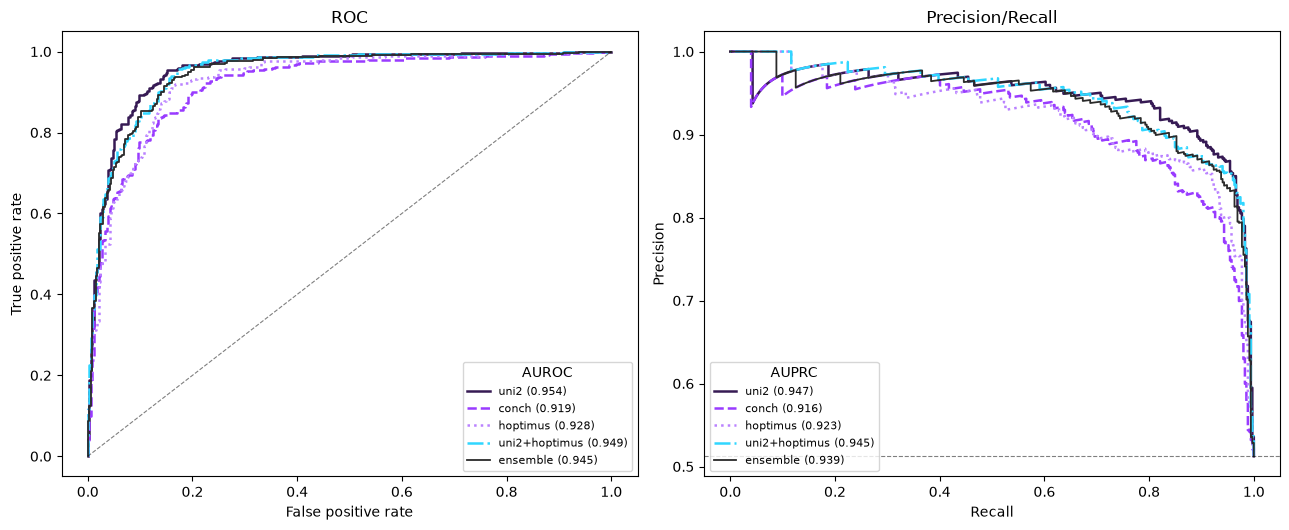

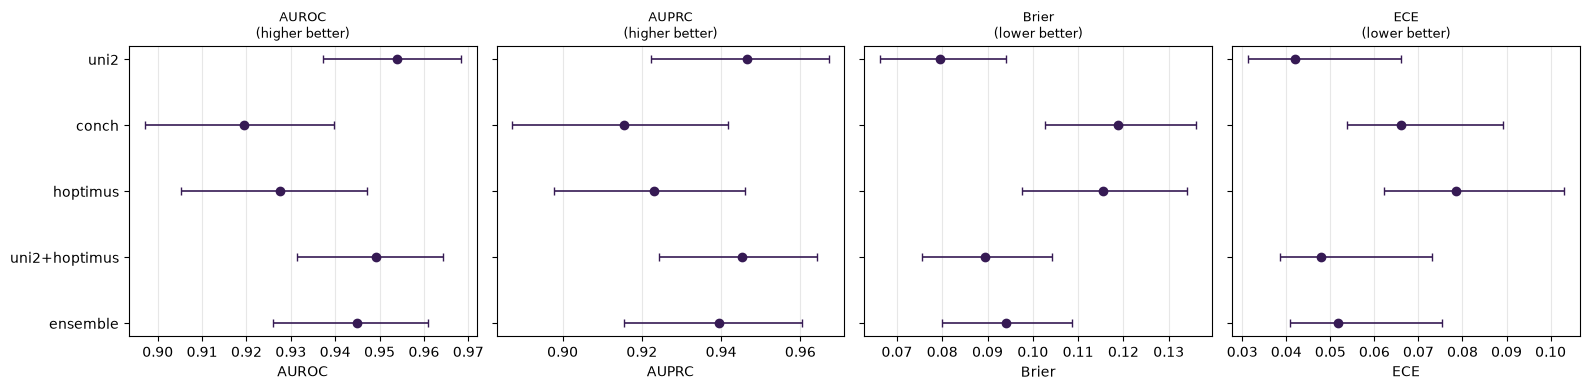

In [ ]:
from sklearn.metrics import precision_recall_curve

N_BOOT_B1 = 2000

rows_fmt, rows_num, curve_data = [], [], {}

for pname, cols in PREDICTORS.items():
    thr = OP_THRESHOLD_BY_PRED[pname]
    scored = predictor_scores(eval_df, cols)
    y = scored["label"].to_numpy(int)
    p = scored["prob_mutant"].to_numpy(float)
    point, ci = bootstrap_metrics(y, p, thr, n_boot=N_BOOT_B1, seed=RNG_SEED)
    curve_data[pname] = (y, p)

    fmt = {"predictor": pname, "n": point["n"],
           "prevalence": round(point["prevalence"], 3), "threshold": round(thr, 3)}
    num = {"predictor": pname, "n": point["n"],
           "prevalence": point["prevalence"], "threshold": thr}
    for k in METRIC_KEYS:
        lo, hi = ci[k]
        fmt[k] = f"{point[k]:.3f} [{lo:.3f}, {hi:.3f}]"
        num[k], num[f"{k}_lo"], num[f"{k}_hi"] = point[k], lo, hi
    rows_fmt.append(fmt); rows_num.append(num)

baseline_fmt = pd.DataFrame(rows_fmt).set_index("predictor")
baseline_num = pd.DataFrame(rows_num).set_index("predictor")
baseline_num.to_csv(OUT_DIR / "baseline_overall_metrics.csv")

print(f"Baseline overall performance | eval n={len(eval_df)} "
      f"| mutant prevalence={eval_df['label'].mean():.3f}\n")
display(baseline_fmt.T)   # metrics as rows, predictors as columns


UCL_CURVE_STYLE = {
    "uni2":          dict(color="#361a54", ls="-"),            # dark purple, solid
    "conch":         dict(color="#993bff", ls="--"),           # bright purple, dashed
    "hoptimus":      dict(color="#ba82ff", ls=":"),            # mid purple, dotted
    "uni2+hoptimus": dict(color="#30d6ff", ls="-."),           # heritage blue, dash-dot
    "ensemble":      dict(color="#2a2a2a", ls="-", lw=1.3),    # dark grey, thin solid (aggregate)
}
R1_FIG_DIR = BASE / "outputs/r1_figures"
R1_FIG_DIR.mkdir(parents=True, exist_ok=True)

prev = float(eval_df["label"].mean())
fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
for pname, (y, p) in curve_data.items():
    style = UCL_CURVE_STYLE[pname]
    fpr, tpr, _ = roc_curve(y, p)
    rec, prec = precision_recall_curve(y, p)[1], precision_recall_curve(y, p)[0]
    ax[0].plot(fpr, tpr, lw=style.get("lw", 1.8), color=style["color"], linestyle=style["ls"],
               label=f"{pname} ({baseline_num.loc[pname,'auroc']:.3f})")
    ax[1].plot(rec, prec, lw=style.get("lw", 1.8), color=style["color"], linestyle=style["ls"],
               label=f"{pname} ({baseline_num.loc[pname,'auprc']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
ax[0].legend(loc="lower right", fontsize=8, title="AUROC")
ax[1].axhline(prev, ls="--", color="k", lw=0.8, alpha=0.5)   # no-skill = prevalence
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision/Recall")
ax[1].legend(loc="lower left", fontsize=8, title="AUPRC")
plt.tight_layout()
plt.savefig(R1_FIG_DIR / "baseline_roc_pr_curves.pdf")
plt.show()

order = list(PREDICTORS.keys())[::-1]
ypos = np.arange(len(order))
panels = [("auroc", "AUROC", "higher better"), ("auprc", "AUPRC", "higher better"),
          ("brier", "Brier", "lower better"), ("ece", "ECE", "lower better")]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.0), sharey=True)
for ax_, (metric, title, hint) in zip(axes, panels):
    pts = baseline_num.loc[order, metric].to_numpy()
    lo = baseline_num.loc[order, f"{metric}_lo"].to_numpy()
    hi = baseline_num.loc[order, f"{metric}_hi"].to_numpy()
    ax_.errorbar(pts, ypos, xerr=[pts - lo, hi - pts], fmt="o",
                 color="#361a54", capsize=3, lw=1.2)   # UCL dark purple
    ax_.set_yticks(ypos); ax_.set_yticklabels(order)
    ax_.set_xlabel(title); ax_.grid(axis="x", alpha=0.3)
    ax_.set_title(f"{title}\n({hint})", fontsize=9)
plt.tight_layout()
plt.savefig(R1_FIG_DIR / "baseline_forest_plot.pdf")
plt.show()

### E.2 Paired Bootstrap Tests

The estimates are correlated because the patients are shared, same eval set through
all five predictors, so their errors rise and fall together. That correlation shrinks
the uncertainty on a difference: the -2Cov term subtracts real variance, and ignoring
it makes gaps look noisier than they actually are.

So overlapping CIs on the individual predictors don't mean "no difference." Two
predictors can have overlapping marginal CIs yet a difference whose own CI excludes
zero, which is exactly the situation among the top three here.

The fix is one shared resample per iteration: draw patients once (stratified by
label via `_strat_idx`), score all predictors on those same patients, store the
differences. Percentiles of the stored differences give the CI; the share crossing
zero gives the p-value. Point estimates are already fixed from the earlier table,
the bootstrap only supplies the CI and p-value on each gap.

Multiple contrasts here, so BH-FDR across the primary threshold-free family (AUROC,
AUPRC, Brier, ECE). AUROC/AUPRC/Brier/ECE compare pure ranking and calibration;
sensitivity/NPV depend on each predictor's own locked Youden point, so they're
reported as supporting evidence on operating-point behaviour and kept out of the
correction family.

Paired bootstrap: 5000/5000 usable resamples

Primary contrasts (BH-FDR; * = q<0.05):
*          uni2 - conch          auroc: +0.0346 [+0.0222, +0.0487]  q=0.001
*          uni2 - conch          auprc: +0.0310 [+0.0186, +0.0442]  q=0.001
*          uni2 - conch          brier: -0.0394 [-0.0513, -0.0277]  q=0.001
*          uni2 - hoptimus       auroc: +0.0265 [+0.0140, +0.0401]  q=0.001
*          uni2 - hoptimus       brier: -0.0361 [-0.0486, -0.0239]  q=0.001
*          uni2 - ensemble       brier: -0.0146 [-0.0212, -0.0078]  q=0.001
*         conch - uni2+hoptimus  brier: +0.0293 [+0.0198, +0.0393]  q=0.001
*      hoptimus - uni2+hoptimus  auprc: -0.0223 [-0.0325, -0.0130]  q=0.001
*         conch - ensemble       auroc: -0.0254 [-0.0352, -0.0170]  q=0.001
*         conch - ensemble       auprc: -0.0238 [-0.0335, -0.0150]  q=0.001
*         conch - ensemble       brier: +0.0248 [+0.0180, +0.0318]  q=0.001
*      hoptimus - uni2+hoptimus  auroc: -0.0216 [-0.0298, -0.0140]  q=0.001
* 

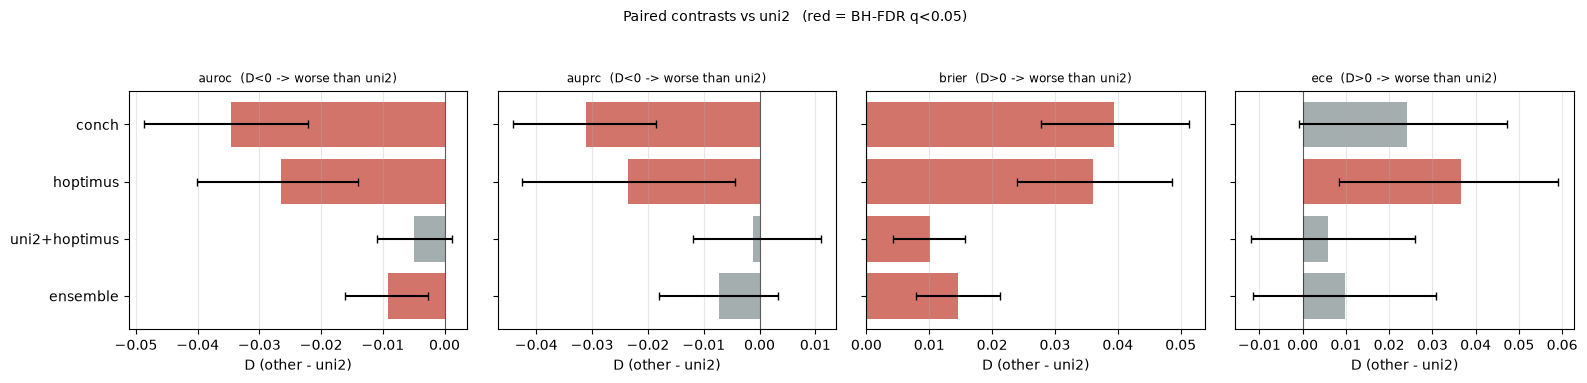

In [ ]:
from itertools import combinations

N_BOOT_B2 = 5000
PRIMARY_METRICS = ["auroc", "auprc", "brier", "ece"]
SUPPORT_METRICS = ["sensitivity", "npv"]          # own-threshold: supporting only
LOWER_BETTER    = {"brier", "ece"}
track = PRIMARY_METRICS + SUPPORT_METRICS
pred_names = list(PREDICTORS.keys())

Y   = eval_df["label"].to_numpy(int)
P   = {pn: predictor_scores(eval_df, cols)["prob_mutant"].to_numpy(float)
       for pn, cols in PREDICTORS.items()}
THR = {pn: OP_THRESHOLD_BY_PRED[pn] for pn in pred_names}

rng = np.random.default_rng(RNG_SEED)
samp = {pn: {k: [] for k in track} for pn in pred_names}
n_used = 0
for _ in range(N_BOOT_B2):
    bi = _strat_idx(Y, rng)
    if len(np.unique(Y[bi])) < 2:
        continue
    n_used += 1
    for pn in pred_names:
        m = binary_metrics(Y[bi], P[pn][bi], THR[pn])
        for k in track:
            samp[pn][k].append(m[k])
samp = {pn: {k: np.asarray(v) for k, v in d.items()} for pn, d in samp.items()}
print(f"Paired bootstrap: {n_used}/{N_BOOT_B2} usable resamples")

def boot_p_two_sided(d):
    nb = len(d)
    return min(1.0, 2 * min((np.sum(d <= 0) + 1) / (nb + 1),
                            (np.sum(d >= 0) + 1) / (nb + 1)))

def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

rows = []
for a, b in combinations(pred_names, 2):
    for k in track:
        d = samp[a][k] - samp[b][k]
        lo, hi = np.quantile(d, [0.025, 0.975])
        rows.append({"a": a, "b": b, "metric": k,
                     "delta": float(baseline_num.loc[a, k] - baseline_num.loc[b, k]),
                     "ci_low": float(lo), "ci_high": float(hi),
                     "p_raw": float(boot_p_two_sided(d)),
                     "family": "primary" if k in PRIMARY_METRICS else "support"})
contrasts = pd.DataFrame(rows)
prim = contrasts["family"] == "primary"
contrasts["p_fdr"] = np.nan
contrasts.loc[prim, "p_fdr"] = bh_fdr(contrasts.loc[prim, "p_raw"].to_numpy())
contrasts["sig_fdr"] = contrasts["p_fdr"] < 0.05
contrasts.to_csv(OUT_DIR / "baseline_paired_contrasts.csv", index=False)

def get_contrast(target, ref, metric):
    m = contrasts[(contrasts.metric == metric) &
                  (((contrasts.a == target) & (contrasts.b == ref)) |
                   ((contrasts.a == ref) & (contrasts.b == target)))].iloc[0]
    s = 1.0 if m["a"] == target else -1.0
    lo, hi = sorted([s * m["ci_low"], s * m["ci_high"]])
    q = m["p_fdr"] if m["family"] == "primary" else m["p_raw"]
    return s * m["delta"], lo, hi, q, bool(m["sig_fdr"])

def line(r):
    star = "*" if (r["family"] == "primary" and r["sig_fdr"]) else " "
    p = f"q={r['p_fdr']:.3f}" if r["family"] == "primary" else f"p={r['p_raw']:.3f}(raw)"
    return (f"{star} {r['a']:>13s} - {r['b']:<13s} {r['metric']:>6s}: "
            f"{r['delta']:+.4f} [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]  {p}")

print("\nPrimary contrasts (BH-FDR; * = q<0.05):")
for _, r in contrasts[prim].loc[contrasts[prim]["p_fdr"].sort_values().index].iterrows():
    print(line(r))
print("\nSupporting (own-threshold operating points; uncorrected):")
for _, r in contrasts[~prim].iterrows():
    print(line(r))

print("\nDropping conch  (uni2+hoptimus  vs  ensemble):")
for k in PRIMARY_METRICS:
    d, lo, hi, q, sg = get_contrast("uni2+hoptimus", "ensemble", k)
    print(f"  {k:>6s}: {d:+.4f} [{lo:+.4f}, {hi:+.4f}]  q={q:.3f} {'*' if sg else ''}")

ANCHOR = "uni2"
others = [p for p in pred_names if p != ANCHOR][::-1]
ypos = np.arange(len(others))
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax_, k in zip(axes, PRIMARY_METRICS):
    ds, los, his, cols = [], [], [], []
    for o in others:
        d, lo, hi, q, sg = get_contrast(o, ANCHOR, k)
        ds.append(d); los.append(lo); his.append(hi)
        cols.append("#c0392b" if sg else "#7f8c8d")
    ds, los, his = np.array(ds), np.array(los), np.array(his)
    ax_.barh(ypos, ds, xerr=[ds - los, his - ds], color=cols, alpha=0.7, capsize=3)
    ax_.axvline(0, color="k", lw=0.8, alpha=0.6)
    ax_.set_yticks(ypos); ax_.set_yticklabels(others)
    worse = "D>0 -> worse" if k in LOWER_BETTER else "D<0 -> worse"
    ax_.set_title(f"{k}  ({worse} than {ANCHOR})", fontsize=8.5)
    ax_.set_xlabel(f"D (other - {ANCHOR})"); ax_.grid(axis="x", alpha=0.3)
fig.suptitle("Paired contrasts vs uni2   (red = BH-FDR q<0.05)", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

## E3. Stratified performance -- sex, race, age

A single overall AUROC can hide a model that works much worse for one demographic
group. Before abstention even enters the picture, it's worth knowing whether the base
predictors already have subgroup gaps, and how precisely this cohort can detect one
(via the minimum detectable effect, MDE) given each subgroup's sample size.

First, a closed-form power audit (below) reports, from sample size alone, which
subgroup contrasts could even in principle detect a modest gap. Then, for each
predictor, computes the full metric suite within each sex/race/age subgroup with
bootstrap CIs, plus the bootstrap CI, p-value, and MDE for each pre-specified
contrast (e.g. female vs. male, white vs. Black), with BH-FDR correction applied
within each metric.

Power audit, before any results. Sample size alone, with no knowledge of any
outcome, sets a floor on the smallest gap a subgroup comparison could realistically
detect. Computing and reporting that floor before the subgroup results below is
deliberate: reading a non-significant gap in an underpowered subgroup (e.g. n=44
Black patients) as "no disparity found" is a common and misleading failure mode in
fairness reporting. The table below uses closed-form, model-independent
minimum-detectable-effect (MDE) formulas, not the bootstrap, so it reflects only the
cohort's subgroup sizes, against two benchmarks: a clinically modest 0.05 AUROC gap,
and the 0.16 white-Black AUROC gap Vaidya et al. reported for conventional
(non-foundation-model) encoders.

In [ ]:
VAIDYA_WEAK_REF = 0.16     # white-Black AUROC gap, ResNet50-ImageNet baseline
UNI_FM_REF      = None 
MIN_SUBGROUP_N  = 20
PRIMARY_B3      = "ensemble"
Z_MDE           = float(norm.ppf(0.975) + norm.ppf(0.80))

BAD_LEVELS = {"unknown", "unclass", "not reported", "nan", "", "none"}
AGE_ORDER  = ["<20", "20-39", "40-54", "55-69", "70+"]


RACE_COL_B3 = "race_binary" if "race_binary" in eval_df.columns else None   
RACE_MULTI_COL = next((c for c in ["race", "race_full", "race_detailed"]
                       if c in eval_df.columns), None)

AXES = {
    "sex": {"col": "sex", "levels": ["female", "male"],
            "contrasts": [("female", "male")]},
    "age": {"col": "age_band", "levels": None,        # filled from data, AGE_ORDER
            "contrasts": "level_vs_rest"},
}
# race: prefer the multi-level column if present, else fall back to binary
if RACE_MULTI_COL is not None:
    AXES["race"] = {"col": RACE_MULTI_COL,
                    "levels": ["white", "black or african american", "asian"],
                    "contrasts": [("white", "black or african american"),
                                  ("white", "asian")]}
elif RACE_COL_B3 is not None:
    AXES["race"] = {"col": RACE_COL_B3, "levels": ["white", "non-white"],
                    "contrasts": [("white", "non-white")]}

# --- level resolution -------------------------------------------------------
def resolve_levels(spec, colvals):
    if spec["levels"] is not None:
        return [lv for lv in spec["levels"] if (colvals == lv).sum() >= MIN_SUBGROUP_N]
    present = [v for v in pd.unique(colvals) if v not in BAD_LEVELS]
    if spec["col"] == "age_band":
        present = [a for a in AGE_ORDER if a in present]
    return [lv for lv in present if (colvals == lv).sum() >= MIN_SUBGROUP_N]

def frame_for(pname):
    s = predictor_scores(eval_df, PREDICTORS[pname])
    f = eval_df.copy()
    f["p"] = s["prob_mutant"].to_numpy(float)
    f["y"] = s["label"].to_numpy(int)
    return f

# --- closed-form MDEs --------------------------------------------------------
def proportion_mde(n_a, n_b, z=Z_MDE):
    if n_a <= 0 or n_b <= 0:
        return np.nan
    se = np.sqrt(0.25 * (1 / n_a + 1 / n_b))
    return float(z * se)

def auroc_mde_conservative(n0_a, n1_a, n0_b, n1_b, z=Z_MDE):
    if min(n0_a, n1_a) <= 0 or min(n0_b, n1_b) <= 0:
        return np.nan
    var_a = (n0_a + n1_a + 1) / (12 * n0_a * n1_a)
    var_b = (n0_b + n1_b + 1) / (12 * n0_b * n1_b)
    return float(z * np.sqrt(var_a + var_b))

# --- build the audit table using the primary predictor's cohort -------------
_f_power = frame_for(PRIMARY_B3)
power_rows = []
for axis, spec in AXES.items():
    colvals = _f_power[spec["col"]].astype(str).str.lower().to_numpy()
    levels = resolve_levels(spec, colvals)
    masks = {lv: colvals == lv for lv in levels}

    if spec["contrasts"] == "level_vs_rest":
        valid = np.isin(colvals, levels)
        pairs = [(f"{lv} - rest", masks[lv], valid & ~masks[lv]) for lv in levels]
    else:
        pairs = []
        for a, b in spec["contrasts"]:
            if a in masks and b in masks:
                pairs.append((f"{a} - {b}", masks[a], masks[b]))
        if axis == "race" and "white" in masks and RACE_MULTI_COL is not None:
            nonwhite = np.isin(colvals, levels) & (colvals != "white")
            if nonwhite.sum() >= MIN_SUBGROUP_N:
                pairs.append(("white - non-white (pooled)", masks["white"], nonwhite))

    for cname, mA, mB in pairs:
        yA = _f_power.loc[mA, "y"].to_numpy(int)
        yB = _f_power.loc[mB, "y"].to_numpy(int)
        nA, nB = len(yA), len(yB)
        n0A, n1A = int((yA == 0).sum()), int((yA == 1).sum())
        n0B, n1B = int((yB == 0).sum()), int((yB == 1).sum())

        mde_prop = proportion_mde(nA, nB)
        mde_auc = auroc_mde_conservative(n0A, n1A, n0B, n1B)

        power_rows.append({
            "axis": axis, "contrast": cname, "nA": nA, "nB": nB,
            "mde_proportion": mde_prop,
            "mde_auroc_conservative": mde_auc,
            "adequate_for_0.05_gap": bool(np.isfinite(mde_auc) and mde_auc <= 0.05),
            "adequate_for_vaidya_0.16_gap": bool(np.isfinite(mde_auc) and mde_auc <= VAIDYA_WEAK_REF),
        })

power_df = pd.DataFrame(power_rows)
power_df.to_csv(OUT_DIR / "b3_subgroup_power_audit.csv", index=False)

print(f"B3 power audit -- {PRIMARY_B3} cohort, closed-form MDE "
      f"(80% power, alpha=0.05, no bootstrap, model-independent)\n")
hdr = (f"{'axis':<6s} {'contrast':<30s} {'nA':>5s} {'nB':>5s} "
       f"{'MDE(prop)':>10s} {'MDE(AUROC)':>11s} {'>=0.05?':>8s} {'>=Vaidya?':>10s}")
print(hdr); print("-" * len(hdr))
for _, r in power_df.iterrows():
    print(f"{r.axis:<6s} {r.contrast:<30s} {r.nA:>5d} {r.nB:>5d} "
          f"{r.mde_proportion:>10.3f} {r.mde_auroc_conservative:>11.3f} "
          f"{'yes' if r['adequate_for_0.05_gap'] else 'no':>8s} "
          f"{'yes' if r['adequate_for_vaidya_0.16_gap'] else 'no':>10s}")

n_adequate_005 = int(power_df["adequate_for_0.05_gap"].sum())
n_adequate_016 = int(power_df["adequate_for_vaidya_0.16_gap"].sum())
print(f"\n{n_adequate_005}/{len(power_df)} contrasts adequately powered "
      f"for a clinically-modest 0.05 AUROC gap.")
print(f"{n_adequate_016}/{len(power_df)} contrasts adequately powered "
      f"for the Vaidya et al. 0.16 AUROC gap (conventional, non-FM encoders).")
print("\nContrasts below the 0.05 bar should be read as underpowered for a "
      "modest gap, not as evidence against one; the bootstrap MDEs reported "
      "per-metric below are model-specific and usually smaller, but this "
      "table is the honest floor set by sample size alone.")


B3 power audit -- ensemble cohort, closed-form MDE (80% power, alpha=0.05, no bootstrap, model-independent)

axis   contrast                          nA    nB  MDE(prop)  MDE(AUROC)  >=0.05?  >=Vaidya?
--------------------------------------------------------------------------------------------
sex    female - male                    290   396      0.108       0.125       no        yes
age    20-39 - rest                     210   472      0.116       0.174       no         no
age    40-54 - rest                     213   469      0.116       0.135       no        yes
age    55-69 - rest                     186   496      0.120       0.162       no         no
age    70+ - rest                        73   609      0.173       0.312       no         no
race   white - black or african american   612    44      0.219       0.268       no         no
race   white - non-white (pooled)       612    44      0.219       0.268       no         no

0/7 contrasts adequately powered for a clinically-

B3 subgroup descriptives - ensemble (n>=20 per subgroup)
axis   level                         n  prev             auroc             auprc               bss balanced_accuracy       sensitivity       specificity             brier               ece           cal_gap          accuracy               ppv               npv                f1
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
sex    female                      290  0.53 +0.938[+0.91,+0.96] +0.934[+0.89,+0.97] +0.592[+0.49,+0.68] +0.849[+0.81,+0.89] +0.832[+0.77,+0.89] +0.867[+0.81,+0.92] +0.102[+0.08,+0.13] +0.058[+0.05,+0.11] -0.055[-0.09,-0.02] +0.848[+0.81,+0.89] +0.878[+0.82,+0.93] +0.818[+0.75,+0.88] +0.854[+0.81,+0.89]
sex    male                        396  0.49 +0.949[+0.93,+0.97] +0.945[+0.92,+0

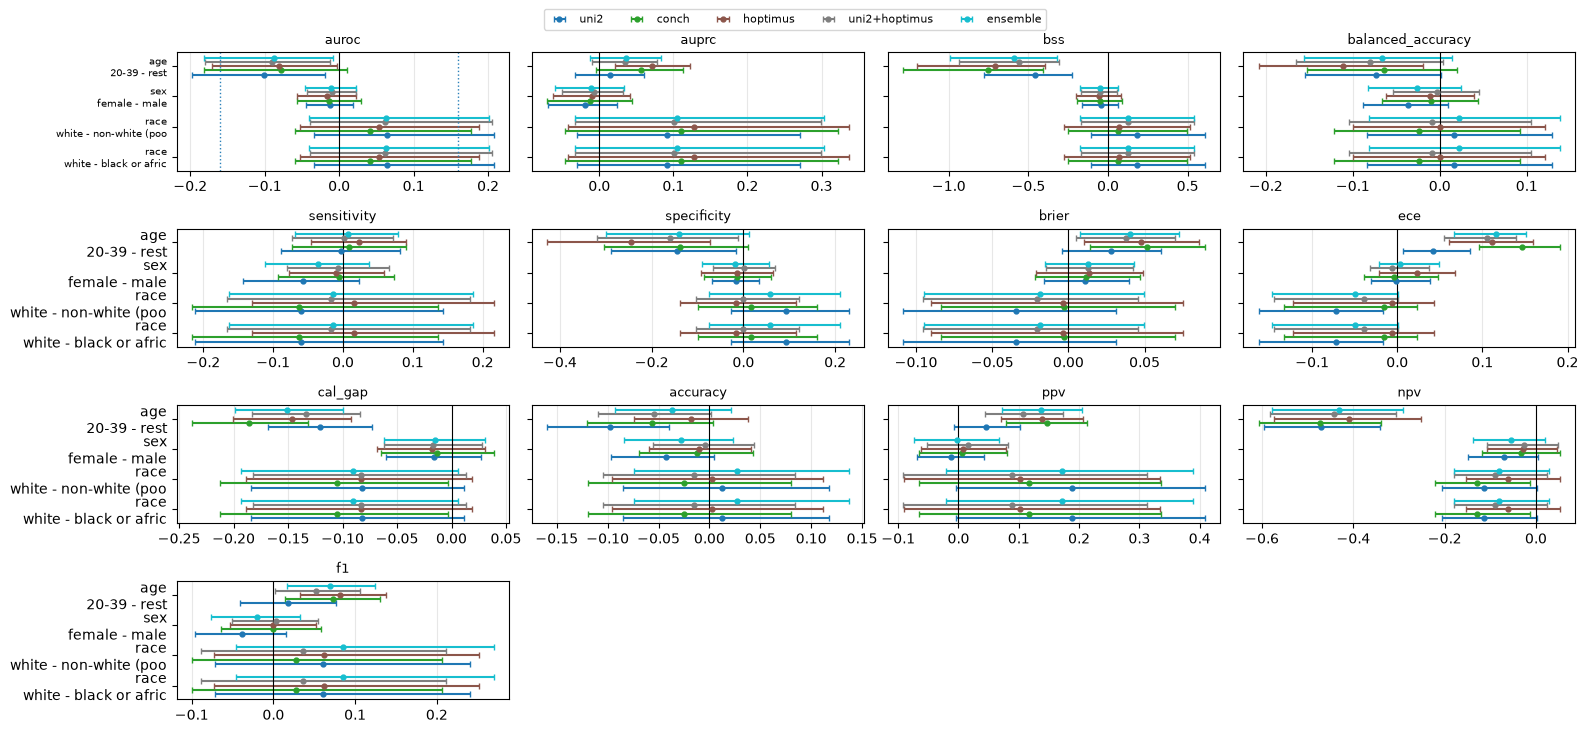

In [ ]:
MIN_CLASS_N     = 3
N_BOOT_B3       = 2000

# --- metric suite -----------------------------------------------------------
RANK_METRICS = ["auroc", "auprc", "bss", "balanced_accuracy"]
NEEDS_BOTH   = set(RANK_METRICS) | {"ppv", "npv", "f1"}
SUITE = RANK_METRICS + ["sensitivity", "specificity", "brier", "ece", "cal_gap",
                        "accuracy", "ppv", "npv", "f1"]

def _bss(y, p):
    u = y.mean() * (1 - y.mean())
    return 1 - ((p - y) ** 2).mean() / u if u > 1e-6 else np.nan

def metrics_of(y, p, thr):
    m = binary_metrics(y, p, thr)
    m["bss"] = _bss(y, p)
    m["cal_gap"] = float(p.mean() - y.mean())
    return m

def defined_keys(y):
    n1, n0 = int((y == 1).sum()), int((y == 0).sum())
    keep = []
    for k in SUITE:
        if k in NEEDS_BOTH and min(n0, n1) < MIN_CLASS_N: continue
        if k == "sensitivity" and n1 < MIN_CLASS_N:       continue
        if k == "specificity" and n0 < MIN_CLASS_N:       continue
        keep.append(k)
    return keep

# --- per-subgroup point estimate + bootstrap CI -----------------------------
def subgroup_ci(y, p, thr, seed):
    keys = defined_keys(y)
    point = metrics_of(y, p, thr)
    rng = np.random.default_rng(seed)
    draws = {k: [] for k in keys}
    for _ in range(N_BOOT_B3):
        i = rng.integers(0, len(y), len(y))
        if defined_keys(y[i]) != keys:
            continue
        m = metrics_of(y[i], p[i], thr)
        for k in keys:
            draws[k].append(m[k])
    out = {}
    for k in SUITE:
        if k not in keys:
            out[k] = out[f"{k}_lo"] = out[f"{k}_hi"] = np.nan
            continue
        v = np.asarray(draws[k], float); v = v[np.isfinite(v)]
        out[k] = point[k]
        out[f"{k}_lo"], out[f"{k}_hi"] = (np.percentile(v, [2.5, 97.5]) if len(v)
                                          else (np.nan, np.nan))
    return out

# --- contrast: gap, bootstrap CI, bootstrap p, MDE --------------------------
def contrast_ci(yA, pA, yB, pB, thr, seed):
    keys = [k for k in defined_keys(yA) if k in defined_keys(yB)]
    if not keys:
        return {}
    obs = {k: metrics_of(yA, pA, thr)[k] - metrics_of(yB, pB, thr)[k] for k in keys}
    rng = np.random.default_rng(seed)
    boot = {k: [] for k in keys}
    for _ in range(N_BOOT_B3):
        a = rng.integers(0, len(yA), len(yA)); b = rng.integers(0, len(yB), len(yB))
        if defined_keys(yA[a]) != defined_keys(yA) or defined_keys(yB[b]) != defined_keys(yB):
            continue
        mA, mB = metrics_of(yA[a], pA[a], thr), metrics_of(yB[b], pB[b], thr)
        for k in keys:
            boot[k].append(mA[k] - mB[k])
    res = {}
    for k in keys:
        d = np.asarray(boot[k], float); d = d[np.isfinite(d)]
        if not len(d):
            res[k] = {"gap": obs[k], "lo": np.nan, "hi": np.nan, "p": np.nan, "mde": np.nan}
            continue
        lo, hi = np.percentile(d, [2.5, 97.5])
        p = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        res[k] = {"gap": obs[k], "lo": float(lo), "hi": float(hi),
                  "p": float(p), "mde": float(Z_MDE * d.std())}
    return res

# --- compute ----------------------------------------------------------------
sub_rows, gap_rows = [], []
for pname in PREDICTORS:
    f = frame_for(pname); thr = OP_THRESHOLD_BY_PRED[pname]
    for axis, spec in AXES.items():
        colvals = f[spec["col"]].astype(str).str.lower().to_numpy()
        levels = resolve_levels(spec, colvals)
        masks = {lv: colvals == lv for lv in levels}

        for lv, m in masks.items():
            y, p = f.loc[m, "y"].to_numpy(int), f.loc[m, "p"].to_numpy(float)
            sub_rows.append({"predictor": pname, "axis": axis, "level": lv,
                             "n": int(m.sum()), "prev": float(y.mean()),
                             **subgroup_ci(y, p, thr, RNG_SEED + stable_seed(pname, lv))})

        # build contrast list
        if spec["contrasts"] == "level_vs_rest":
            valid = np.isin(colvals, levels)
            pairs = [(f"{lv} - rest", masks[lv], valid & ~masks[lv]) for lv in levels]
        else:
            pairs = []
            for a, b in spec["contrasts"]:
                if a in masks and b in masks:
                    pairs.append((f"{a} - {b}", masks[a], masks[b]))
            # add pooled white - non-white if race is multi-level
            if axis == "race" and "white" in masks and RACE_MULTI_COL is not None:
                nonwhite = np.isin(colvals, levels) & (colvals != "white")
                if nonwhite.sum() >= MIN_SUBGROUP_N:
                    pairs.append(("white - non-white (pooled)", masks["white"], nonwhite))

        for cname, mA, mB in pairs:
            r = contrast_ci(f.loc[mA, "y"].to_numpy(int), f.loc[mA, "p"].to_numpy(float),
                            f.loc[mB, "y"].to_numpy(int), f.loc[mB, "p"].to_numpy(float),
                            thr, RNG_SEED + stable_seed(tuple(np.flatnonzero(mA)),
                                                        tuple(np.flatnonzero(mB))))
            for k, v in r.items():
                gap_rows.append({"predictor": pname, "axis": axis, "contrast": cname,
                                 "metric": k, "nA": int(mA.sum()), "nB": int(mB.sum()), **v})

sub_df = pd.DataFrame(sub_rows)
gap_df = pd.DataFrame(gap_rows)

gap_df["q_fdr"] = np.nan
for m, idx in gap_df.groupby("metric").groups.items():
    sub = gap_df.loc[idx]
    ok = sub["p"].notna()
    gap_df.loc[sub.index[ok], "q_fdr"] = bh_fdr(sub.loc[ok, "p"].to_numpy())
gap_df["sig_fdr"] = gap_df["q_fdr"] < 0.05
gap_df["resolvability"] = np.where(gap_df["mde"] < VAIDYA_WEAK_REF, "<Vaidya-weak", ">Vaidya-weak")

sub_df.to_csv(OUT_DIR / "b3_subgroup_descriptives.csv", index=False)
gap_df.to_csv(OUT_DIR / "b3_subgroup_gaps.csv", index=False)

def cell(r, k):
    if not np.isfinite(r[k]):
        return f"{'-':>17s}"
    return f"{r[k]:>+6.3f}[{r[f'{k}_lo']:>+5.2f},{r[f'{k}_hi']:>+5.2f}]"

sp = sub_df[sub_df.predictor == PRIMARY_B3]
print(f"B3 subgroup descriptives - {PRIMARY_B3} (n>={MIN_SUBGROUP_N} per subgroup)")
hdr = f"{'axis':<6s} {'level':<26s} {'n':>4s} {'prev':>5s}" + "".join(f" {m:>17s}" for m in SUITE)
print(hdr); print("-" * len(hdr))
for axis in AXES:
    for _, r in sp[sp.axis == axis].iterrows():
        print(f"{axis:<6s} {str(r.level)[:25]:<26s} {r.n:>4d} {r.prev:>5.2f}"
              + "".join(" " + cell(r, m) for m in SUITE))

for m in SUITE:
    gm = gap_df[gap_df.metric == m]
    if gm.empty:
        continue
    print(f"\n{m} gaps  (* = FDR q<0.05 within metric)")
    for (axis, contrast), sub in gm.groupby(["axis", "contrast"], observed=True):
        print(f"  {axis}  {contrast}")
        sub = sub.set_index("predictor")
        for pred in PREDICTORS:
            if pred not in sub.index:
                continue
            r = sub.loc[pred]
            star = "*" if r.sig_fdr else " "
            print(f"    {star} {pred:>13s}: {r.gap:+.3f} [{r.lo:+.3f},{r.hi:+.3f}]"
                  f"  q={r.q_fdr:.3f}  MDE={r.mde:.3f} ({r.resolvability})")

show = [("race", "white - black or african american"),
        ("race", "white - non-white (pooled)"),
        ("sex", "female - male"),
        ("age", "20-39 - rest")]
show = [(a, c) for a, c in show
        if not gap_df[(gap_df.axis == a) & (gap_df.contrast == c)].empty]
panel_metrics = [m for m in SUITE if m in gap_df["metric"].unique()]
colors = plt.cm.tab10(np.linspace(0, 1, len(PREDICTORS)))
ncol = 4; nrow = int(np.ceil(len(panel_metrics) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 1.2 + 1.5 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()
labels = [f"{a}\n{c[:22]}" for a, c in show]
for ax, m in zip(axes, panel_metrics):
    gm = gap_df[gap_df.metric == m]
    for yi, (axis, contrast) in enumerate(show):
        sub = gm[(gm.axis == axis) & (gm.contrast == contrast)].set_index("predictor")
        for j, pred in enumerate(PREDICTORS):
            if pred not in sub.index:
                continue
            r = sub.loc[pred]
            yy = yi + (j - (len(PREDICTORS) - 1) / 2) * 0.14
            ax.errorbar(r.gap, yy, xerr=[[r.gap - r.lo], [r.hi - r.gap]], fmt="o",
                        color=colors[j], capsize=2, ms=3.5,
                        label=pred if (yi == 0 and ax is axes[0]) else None)
    ax.axvline(0, color="k", lw=0.8)
    if m == "auroc":       # Vaidya weak-baseline reference belongs on AUROC only
        for x in (-VAIDYA_WEAK_REF, VAIDYA_WEAK_REF):
            ax.axvline(x, ls=":", color="#2980b9", lw=1)
        if UNI_FM_REF is not None:
            for x in (-UNI_FM_REF, UNI_FM_REF):
                ax.axvline(x, ls="--", color="#27ae60", lw=1)
    ax.set_title(m, fontsize=9); ax.grid(axis="x", alpha=0.3)
for ax in axes[len(panel_metrics):]:
    ax.axis("off")
axes[0].set_yticks(range(len(show))); axes[0].set_yticklabels(labels, fontsize=7)
fig.legend(loc="upper center", ncol=len(PREDICTORS), fontsize=8, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(); plt.show()

## E4. Acquisition variables: site, magnification, scanner

Site, scanner model, and magnification aren't fairness axes on their own, but they
can (a) explain part of a demographic gap if they're confounded with it, and (b)
matter directly, since the OOD detector operates on raw image features that a
scanner/magnification change can shift. This section asks whether performance is
stable across these acquisition variables, and how confounded they are with each
other and with case mix.

Six checks: confound structure (Cramer's V between site/magnification/scanner/tumour
type); per-site descriptives; a prevalence-preserving permutation test for site
heterogeneity; one pre-specified single-site contrast (Thomas Jefferson vs. rest); a
within-site magnification comparison restricted to GBM cases (so site and subtype are
held fixed); and whether site-level calibration gap is just tracking site
prevalence.

merged 687/687 | magnification: {'40x': 528, '20x': 159} | 15 scanner serials

C1. CONFOUND STRUCTURE (Cramér's V: 0=independent, 1=deterministic)
           site ~ magnification V=0.677  p=7.7e-50
           site ~ scanner_grp   V=0.734  p=4.1e-177
  magnification ~ idh_label     V=0.473  p=2.9e-35
           site ~ tumour_type   V=0.412  p=1.2e-43
           site ~ race_binary   V=0.418  p=1.7e-12
  magnification ~ tumour_type   V=0.511  p=9.9e-38

  15/19 sites (n>=5) use a single magnification.
  20x: 91% glioblastoma; IDH-mutant prevalence 0.08 (n=159)
  40x: 39% astrocytoma; IDH-mutant prevalence 0.64 (n=528)

C2. PER-SITE PERFORMANCE - ensemble
BSS: 1=perfect, 0=no better than site base rate, <0=worse. '-'=undefined.

14 sites (n>=10), 631/687 patients
site                                n  prev   auroc     bss sensitivity specificity     ece cal_gap
---------------------------------------------------------------------------------------------------
UCSF                          

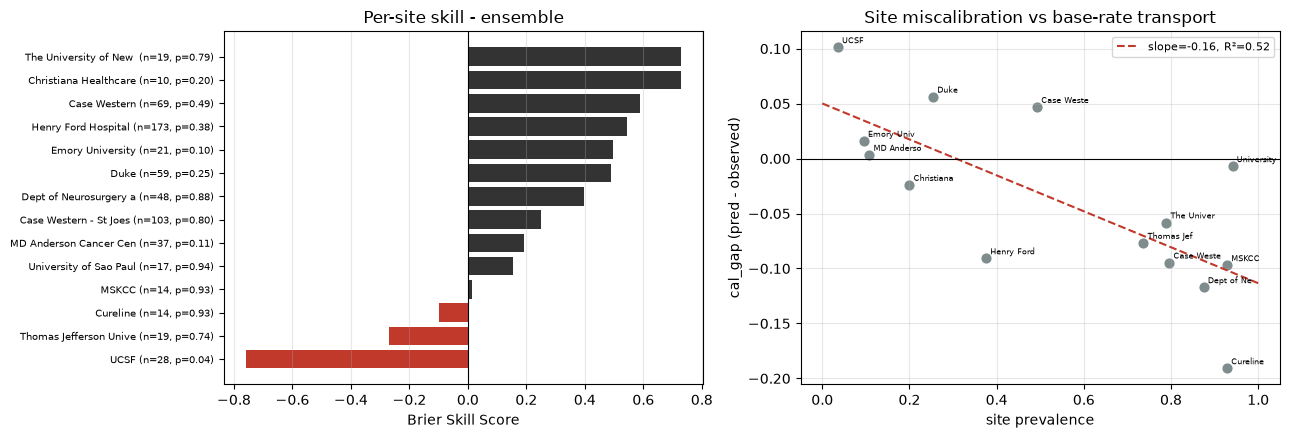

In [ ]:
from scipy.stats import linregress
from scipy.stats import chi2_contingency

MIN_SITE_N, MIN_ARM_N = 10, 5   # MIN_CLASS_N=3 already set above (E3); reused, not redefined.
N_PERM, N_BOOT = 5000, 2000
PRIMARY_C = "ensemble"
METRICS = ["auroc", "bss", "sensitivity", "specificity", "ece", "cal_gap"]
# Z_MDE already defined above (E3) -- same two-sided-95%/80%-power constant, reused here.
TJU = "Thomas Jefferson University"

_meta = pd.read_csv(BASE / "outputs/scanner_metadata/tcga_scanner_metadata.csv").query("status=='ok'")
_meta["case_id"] = _meta["case_id"].astype(str)
acq = eval_df.copy()
acq["case_key"] = acq["patient" if "patient" in acq.columns else "PATIENT"].astype(str)
acq = acq.drop(columns=[c for c in ("vendor","model","objective_power","mpp_x",
                                    "magnification","scanner","scanner_grp","case_id")
                        if c in acq.columns])
acq = acq.merge(_meta[["case_id","vendor","model","objective_power","mpp_x"]],
                left_on="case_key", right_on="case_id", how="left", validate="one_to_one")
acq["magnification"] = acq["objective_power"].map({20:"20x", 40:"40x"})
acq["scanner"] = acq["model"].astype(str).str.lower()
_top = acq["scanner"].value_counts().head(3).index
acq["scanner_grp"] = np.where(acq["scanner"].isin(_top), acq["scanner"], "other")
acq["idh_label"] = acq["label"].map({0:"wildtype", 1:"mutant"})
print(f"merged {acq['objective_power'].notna().sum()}/{len(acq)} | "
      f"magnification: {acq['magnification'].value_counts(dropna=False).to_dict()} | "
      f"{acq['scanner'].nunique()} scanner serials")

def scored(pname):
    s = predictor_scores(acq, PREDICTORS[pname])
    f = acq.copy()
    f["p"] = s["prob_mutant"].to_numpy(float)
    f["y"] = s["label"].to_numpy(int)
    f["correct"] = ((f["p"] >= OP_THRESHOLD_BY_PRED[pname]).astype(int) == f["y"]).astype(int)
    f["brier"] = (f["p"] - f["y"]) ** 2
    return f

def bss(y, p):
    u = y.mean() * (1 - y.mean())
    return 1 - ((p - y) ** 2).mean() / u if u > 1e-6 else np.nan

def metric(g, k, thr):
    y, p = g["y"].to_numpy(int), g["p"].to_numpy(float)
    both = min((y == 0).sum(), (y == 1).sum()) >= MIN_CLASS_N
    if k == "auroc":       return roc_auc_score(y, p) if both else np.nan
    if k == "bss":         return bss(y, p)
    if k == "sensitivity": return ((p >= thr)[y == 1]).mean() if (y == 1).sum() >= MIN_CLASS_N else np.nan
    if k == "specificity": return ((p < thr)[y == 0]).mean() if (y == 0).sum() >= MIN_CLASS_N else np.nan
    if k == "ece":         return expected_calibration_error(y, p)
    if k == "cal_gap":     return float(p.mean() - y.mean())

fp = scored(PRIMARY_C); thr_p = OP_THRESHOLD_BY_PRED[PRIMARY_C]

print("\n" + "=" * 70, "\nC1. CONFOUND STRUCTURE (Cramér's V: 0=independent, 1=deterministic)\n", "=" * 70)
dd = acq.dropna(subset=["magnification"])
for a, b in [("site","magnification"), ("site","scanner_grp"), ("magnification","idh_label"),
             ("site","tumour_type"), ("site","race_binary"), ("magnification","tumour_type")]:
    ct = pd.crosstab(dd[a], dd[b])
    n = int(ct.values.sum())
    if n == 0 or ct.shape[0] < 2 or ct.shape[1] < 2:
        v, pv = np.nan, np.nan
    else:
        chi2, pv, dof, _ = chi2_contingency(ct, correction=False)
        min_dim = min(ct.shape[0] - 1, ct.shape[1] - 1)
        v = float(np.sqrt(chi2 / (n * min_dim))) if min_dim > 0 else np.nan
    print(f"  {a:>13s} ~ {b:<13s} V={v:.3f}  p={pv:.1e}")

st = dd.groupby("site")["magnification"].agg(n="size", f20=lambda s:(s=="20x").mean())
st = st[st.n >= 5]
pure = int(((st.f20 == 0) | (st.f20 == 1)).sum())
print(f"\n  {pure}/{len(st)} sites (n>=5) use a single magnification.")
ct = pd.crosstab(dd["magnification"], dd["tumour_type"])
prev_by_mag = dd.groupby("magnification")["label"].mean()
for mag in ct.index:
    top = ct.loc[mag].idxmax()
    print(f"  {mag}: {ct.loc[mag, top] / ct.loc[mag].sum():.0%} {top}; "
          f"IDH-mutant prevalence {prev_by_mag[mag]:.2f} (n={ct.loc[mag].sum()})")

# ============================================================================
# C2. Per-site descriptives
# ============================================================================
print("\n" + "=" * 70, f"\nC2. PER-SITE PERFORMANCE - {PRIMARY_C}\n", "=" * 70)
print("BSS: 1=perfect, 0=no better than site base rate, <0=worse. '-'=undefined.\n")
rows = []
for s, g in fp.groupby("site"):
    if len(g) < MIN_SITE_N:
        continue
    rows.append({"site": s, "n": len(g), "prev": g["y"].mean(),
                 **{k: metric(g, k, thr_p) for k in METRICS}})
site_df = pd.DataFrame(rows).sort_values("bss").reset_index(drop=True)
site_df.to_csv(OUT_DIR / "c2_site_performance.csv", index=False)
cell = lambda v: f"{v:>+6.3f}" if np.isfinite(v) else f"{'-':>6s}"
print(f"{len(site_df)} sites (n>={MIN_SITE_N}), {int(site_df.n.sum())}/{len(fp)} patients")
hdr = f"{'site':<32s} {'n':>4s} {'prev':>5s}" + "".join(f" {k:>7s}" for k in METRICS)
print(hdr); print("-" * len(hdr))
for _, r in site_df.iterrows():
    flag = "  <-- < base rate" if r.bss < 0 else ""
    print(f"{str(r.site)[:31]:<32s} {r.n:>4d} {r.prev:>5.2f}"
          + "".join(" " + cell(r[k]) for k in METRICS) + flag)

# ============================================================================
# C3. Site heterogeneity (prevalence-preserving permutation, one-sided)
# ============================================================================
print("\n" + "=" * 70, "\nC3. SITE HETEROGENEITY (permute site labels within class -> prevalence held)\n", "=" * 70)
def heterogeneity(f, k, thr, seed=RNG_SEED):
    g = f[["y","p","correct","brier","site"]].copy().reset_index(drop=True)
    keep = g["site"].value_counts(); g = g[g["site"].isin(keep[keep >= MIN_SITE_N].index)].reset_index(drop=True)
    def var_across(frame):
        vals = [metric(sub, k, thr) for _, sub in frame.groupby("site")]
        vals = [v for v in vals if np.isfinite(v)]
        return np.var(vals, ddof=1) if len(vals) > 1 else np.nan
    obs = var_across(g)
    if not np.isfinite(obs):
        return obs, np.nan
    rng = np.random.default_rng(seed)
    i0, i1 = g.index[g.y == 0].to_numpy(), g.index[g.y == 1].to_numpy()
    base = g["site"].to_numpy()
    null = np.empty(N_PERM)
    for j in range(N_PERM):
        s = base.copy()
        s[i0] = rng.permutation(base[i0]); s[i1] = rng.permutation(base[i1])
        null[j] = var_across(g.assign(site=s))
    return obs, (np.nansum(null >= obs) + 1) / (N_PERM + 1)
print(f"{'metric':>12s}" + "".join(f" {p:>14s}" for p in PREDICTORS))
for k in METRICS:
    line = f"{k:>12s}"
    for pn in PREDICTORS:
        _, pv = heterogeneity(scored(pn), k, OP_THRESHOLD_BY_PRED[pn])
        line += f"   {pv:>6.3f}{'*' if np.isfinite(pv) and pv < 0.05 else ' '}     " if np.isfinite(pv) \
                else f"   {'-':>6s}      "
    print(line)
print("\n  * = sites differ beyond chance (p<0.05). No mark = consistent with sampling noise.")

# ============================================================================
# C4. Thomas Jefferson vs rest - one pre-specified contrast
# ============================================================================
print("\n" + "=" * 70, "\nC4. THOMAS JEFFERSON vs REST (pre-specified single contrast)\n", "=" * 70)
n_tju = int((fp.site == TJU).sum())
print(f"  TJU n={n_tju}, prevalence {fp.loc[fp.site==TJU,'y'].mean():.2f} "
      f"(cohort {fp['y'].mean():.2f}). Not case-mix adjusted -> read descriptively.\n")
print(f"{'metric':>12s}" + "".join(f" {p:>14s}" for p in PREDICTORS))
for k in METRICS:
    line = f"{k:>12s}"
    for pn in PREDICTORS:
        f = scored(pn); thr = OP_THRESHOLD_BY_PRED[pn]
        va, vb = metric(f[f.site == TJU], k, thr), metric(f[f.site != TJU], k, thr)
        d = va - vb if np.isfinite(va) and np.isfinite(vb) else np.nan
        line += f"   {d:>+7.3f}     " if np.isfinite(d) else f"   {'-':>7s}     "
    print(line)
print("\n  Values = TJU minus rest.")

# ============================================================================
# C5. Within-site magnification - the one identifiable optics test
# ============================================================================
print("\n" + "=" * 70, "\nC5. WITHIN-SITE MAGNIFICATION (GBM only; sites scanning both, subtype+site fixed)\n", "=" * 70)
gbm = acq[acq.tumour_type == "glioblastoma"].dropna(subset=["magnification"])
gs = gbm.groupby("site")["magnification"].agg(n="size", f20=lambda s:(s=="20x").mean())
mixed = gs[(gs.n >= MIN_ARM_N) & (gs.f20.between(0.1, 0.9))].index.tolist()
print(f"  Mixed-magnification GBM sites: {mixed}  (n={int(gbm.site.isin(mixed).sum())} of {len(gbm)} GBM)")
print(f"  GBM prevalence {gbm['label'].mean():.2f} -> accuracy defined; AUROC is not.\n")
def within_site_diff(f, seed=RNG_SEED):
    g = f[f.site.isin(mixed)][["site","magnification","correct"]].reset_index(drop=True)
    arms = {}
    for s, x in g.groupby("site"):
        a = x.index[x.magnification == "20x"].to_numpy(); b = x.index[x.magnification == "40x"].to_numpy()
        if len(a) >= MIN_ARM_N and len(b) >= MIN_ARM_N:
            arms[s] = (a, b)
    if not arms:
        return None
    v = g["correct"].to_numpy(float)
    def est(pick):
        d, w = [], []
        for a, b in arms.values():
            xa, xb = v[pick(a)], v[pick(b)]
            w.append(1 / (1/len(xa) + 1/len(xb))); d.append(xa.mean() - xb.mean())
        return np.average(d, weights=w)
    obs = est(lambda i: i)
    rng = np.random.default_rng(seed)
    bs = np.array([est(lambda i: rng.choice(i, len(i), True)) for _ in range(N_BOOT)])
    return obs, np.percentile(bs, 2.5), np.percentile(bs, 97.5), Z_MDE * bs.std()
if mixed:
    print(f"{'predictor':>13s} {'raw':>8s} {'within-site':>12s} {'95% CI':>19s} {'MDE':>6s} {'%site':>6s}")
    for pn in PREDICTORS:
        f = scored(pn)
        g = f[f.tumour_type == "glioblastoma"].dropna(subset=["magnification"])
        raw = g.loc[g.magnification=="20x","correct"].mean() - g.loc[g.magnification=="40x","correct"].mean()
        r = within_site_diff(f)
        if r is None:
            continue
        o, lo, hi, mde = r
        pct = 100 * (1 - abs(o)/abs(raw)) if abs(raw) > 1e-9 else np.nan
        sig = "*" if (lo > 0 or hi < 0) else " "
        print(f"{sig}{pn:>13s} {raw:>+8.3f} {o:>+12.3f} [{lo:>+7.3f},{hi:>+7.3f}] {mde:>6.3f} {pct:>5.0f}%")
    print("\n  * = CI excludes 0. Accuracy = correctly calling wildtype (GBM). %site = share of raw effect from institution.")
else:
    print("  No GBM site scanned both magnifications at usable n -> untestable within-site.")

# ============================================================================
# C6. cal_gap ~ site prevalence - is site miscalibration base-rate transport-
# ============================================================================
print("\n" + "=" * 70, "\nC6. cal_gap ~ SITE PREVALENCE\n", "=" * 70)
print("  If cal_gap is a linear function of prevalence, site miscalibration reflects a\n"
      "  global calibration failing to transport, not a site-specific property.\n"
      "  Residuals flag sites off that line.\n")
print(f"{'predictor':>13s} {'slope':>7s} {'r':>6s} {'R2':>6s}   largest residual")
for pn in PREDICTORS:
    f = scored(pn)
    cg = f[f.site.isin(site_df.site)].groupby("site").apply(
        lambda x: pd.Series({"prev": x["y"].mean(), "cal_gap": x["p"].mean() - x["y"].mean()}),
        include_groups=False)
    lr = linregress(cg["prev"], cg["cal_gap"])
    resid = (cg["cal_gap"] - (lr.intercept + lr.slope * cg["prev"])).abs().sort_values(ascending=False)
    print(f"{pn:>13s} {lr.slope:>+7.2f} {lr.rvalue:>+6.2f} {lr.rvalue**2:>6.2f}   "
          f"{str(resid.index[0])[:24]} ({resid.iloc[0]:+.3f})")
    if pn == PRIMARY_C:
        cg_primary, lr_primary = cg, lr

# --- plots ------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, max(4, 0.32 * len(site_df))))
sd = site_df.sort_values("bss")
ax[0].barh(range(len(sd)), sd.bss, color=["#c0392b" if b < 0 else "#333" for b in sd.bss])
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_yticks(range(len(sd)))
ax[0].set_yticklabels([f"{str(s)[:22]} (n={n}, p={pv:.2f})" for s,n,pv in zip(sd.site,sd.n,sd.prev)], fontsize=7)
ax[0].set(xlabel="Brier Skill Score", title=f"Per-site skill - {PRIMARY_C}")
ax[0].grid(axis="x", alpha=0.3)
ax[1].scatter(cg_primary["prev"], cg_primary["cal_gap"], s=40, c="#7f8c8d")
_x = np.linspace(0, 1, 50)
ax[1].plot(_x, lr_primary.intercept + lr_primary.slope * _x, "--", color="#c0392b",
           label=f"slope={lr_primary.slope:+.2f}, R²={lr_primary.rvalue**2:.2f}")
ax[1].axhline(0, color="k", lw=0.8)
for s, r in cg_primary.iterrows():
    ax[1].annotate(str(s)[:10], (r["prev"], r["cal_gap"]), fontsize=6, xytext=(3,3), textcoords="offset points")
ax[1].set(xlabel="site prevalence", ylabel="cal_gap (pred - observed)",
          title="Site miscalibration vs base-rate transport")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

The site-level permutation test above found no excess heterogeneity in calibration
gap (`cal_gap`) but did find it for AUROC — worth understanding why those two metrics
disagree before trusting either result.

Reruns the permutation for `cal_gap` (the surprising null) and `auroc` (the metric
that did show heterogeneity) and prints the full null distribution plus a per-site
observed-vs-permuted-vs-expected breakdown, to check whether the `cal_gap` null is
simply driven by each site's prevalence.

In [21]:
# --- diagnose the cal_gap p=1.000 -------------------------------------------
def het_diagnostic(pname, k, n_perm=N_PERM, seed=RNG_SEED):
    f = scored(pname); thr = OP_THRESHOLD_BY_PRED[pname]
    g = f[["y", "p", "correct", "brier", "site"]].reset_index(drop=True)
    keep = g["site"].value_counts()
    g = g[g["site"].isin(keep[keep >= MIN_SITE_N].index)].reset_index(drop=True)

    def vals_across(frame):
        v = {s: metric(sub, k, thr) for s, sub in frame.groupby("site")}
        return {s: x for s, x in v.items() if np.isfinite(x)}

    obs_vals = vals_across(g)
    obs = np.var(list(obs_vals.values()), ddof=1)

    rng = np.random.default_rng(seed)
    i0, i1 = g.index[g.y == 0].to_numpy(), g.index[g.y == 1].to_numpy()
    base = g["site"].to_numpy()
    null, one_draw = np.empty(n_perm), None
    for j in range(n_perm):
        s = base.copy()
        s[i0] = rng.permutation(base[i0]); s[i1] = rng.permutation(base[i1])
        h = g.assign(site=s)
        vv = vals_across(h)
        null[j] = np.var(list(vv.values()), ddof=1)
        if j == 0:
            one_draw = vv

    print(f"\n[{pname}] {k}")
    print(f"  observed variance : {obs:.6f}")
    print(f"  null  min         : {np.nanmin(null):.6f}")
    print(f"  null  2.5 / 50 / 97.5 pct : {np.nanpercentile(null,2.5):.6f} / "
          f"{np.nanpercentile(null,50):.6f} / {np.nanpercentile(null,97.5):.6f}")
    print(f"  null  max         : {np.nanmax(null):.6f}")
    print(f"  fraction of null >= observed : {(np.nansum(null >= obs))/n_perm:.4f}")
    print(f"  fraction of null <= observed : {(np.nansum(null <= obs))/n_perm:.4f}")

    # per-site observed vs one permuted draw vs the null's expected value.
    # Under class-stratified permutation each site keeps its prevalence but draws
    # random patients, so its expected mean(p) is the prevalence-weighted mix of
    # the pooled class-conditional means. If the null spread is driven by that
    # deterministic prevalence term, the "expected" column will fan out widely.
    mp1 = g.loc[g.y == 1, "p"].mean(); mp0 = g.loc[g.y == 0, "p"].mean()
    print(f"\n  pooled mean p | y=1 : {mp1:.3f}   | y=0 : {mp0:.3f}")
    print(f"  {'site':<32s} {'n':>4s} {'prev':>5s} {'observed':>9s} {'permuted':>9s} {'expected':>9s}")
    for s in sorted(obs_vals):
        sub = g[g.site == s]; prev = sub["y"].mean()
        exp = (prev * mp1 + (1 - prev) * mp0) - prev
        print(f"  {str(s)[:31]:<32s} {len(sub):>4d} {prev:>5.2f} "
              f"{obs_vals[s]:>+9.3f} {one_draw.get(s, np.nan):>+9.3f} {exp:>+9.3f}")

het_diagnostic(PRIMARY_C, "cal_gap")
het_diagnostic(PRIMARY_C, "auroc")     # control: a metric that did show heterogeneity


[ensemble] cal_gap
  observed variance : 0.006330
  null  min         : 0.010868
  null  2.5 / 50 / 97.5 pct : 0.014961 / 0.021318 / 0.029424
  null  max         : 0.048626
  fraction of null >= observed : 1.0000
  fraction of null <= observed : 0.0000

  pooled mean p | y=1 : 0.759   | y=0 : 0.154
  site                                n  prev  observed  permuted  expected
  Case Western                       69  0.49    +0.047    -0.038    -0.040
  Case Western - St Joes            103  0.80    -0.095    -0.149    -0.160
  Christiana Healthcare              10  0.20    -0.024    +0.024    +0.075
  Cureline                           14  0.93    -0.191    -0.111    -0.212
  Dept of Neurosurgery at Univers    48  0.88    -0.117    -0.186    -0.191
  Duke                               59  0.25    +0.056    +0.045    +0.054
  Emory University                   21  0.10    +0.016    +0.108    +0.117
  Henry Ford Hospital               173  0.38    -0.091    -0.004    +0.006
  MD Anderson C

Site, scanner, and magnification are heavily confounded (shown above), so a pooled
scanner-model comparison would really just be measuring site. Restricting to sites
that used more than one scanner model gives a comparison where site is held fixed.

Finds sites that used at least two scanner models with adequate sample sizes, picks
the pair of models with the greatest within-site overlap, and compares accuracy
between them with a hierarchical bootstrap (resample sites, then resample patients
within site/scanner) so within-site pairs stay paired.

In [ ]:
# ======================================================================
# C7. WITHIN-SITE SCANNER MODEL ANALYSIS
# Compare scanner models only within sites that used multiple models.
#
# Assumes the existing analysis defines:
#   scored(pname) -> DataFrame containing y, p, correct, site and metadata
#   PREDICTORS / predictor names
#   PRIMARY_C
#   OP_THRESHOLD_BY_PRED
#   RNG_SEED
#
# Required metadata columns:
#   site
#   scanner model/group
#   tumour type, if restriction is requested
# ======================================================================

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------

SCANNER_COL = "scanner_grp"       
SITE_COL_C7 = "site"
TUMOUR_COL_C7 = "tumour_type"

# Set to None for all tumour types.
SCANNER_TUMOUR_RESTRICTION = None

MIN_SITE_SCANNER_N = 5            # minimum patients per scanner within a site
MIN_MIXED_SITE_N = 10             # minimum total patients in a mixed-scanner site
N_BOOT_SCANNER = 2000
SCANNER_ALPHA = 0.05

SCANNER_PREDICTORS = [
    "uni2",
    "conch",
    "hoptimus",
    "uni2+hoptimus",
    "ensemble",
]

# Optional explicit two-scanner comparison.
# Leave as None to select the two scanner models with the greatest
# eligible within-site overlap.
REFERENCE_SCANNER = None
COMPARISON_SCANNER = None


# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------

def _normalise_text(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip()


def identify_scanner_overlap(
    df,
    scanner_col=SCANNER_COL,
    site_col=SITE_COL_C7,
    min_scanner_n=MIN_SITE_SCANNER_N,
    min_site_n=MIN_MIXED_SITE_N,
):

    counts = (
        df.dropna(subset=[site_col, scanner_col])
          .groupby([site_col, scanner_col])
          .size()
          .rename("n")
          .reset_index()
    )

    eligible_pairs = counts[counts["n"] >= min_scanner_n].copy()

    site_summary = (
        eligible_pairs.groupby(site_col)
        .agg(
            n_scanners=(scanner_col, "nunique"),
            n_eligible=("n", "sum"),
        )
        .reset_index()
    )

    eligible_sites = site_summary.loc[
        (site_summary["n_scanners"] >= 2)
        & (site_summary["n_eligible"] >= min_site_n),
        site_col,
    ].tolist()

    return counts, eligible_pairs, eligible_sites


def select_scanner_pair(
    eligible_pairs,
    eligible_sites,
    reference=None,
    comparison=None,
    scanner_col=SCANNER_COL,
    site_col=SITE_COL_C7,
):
    """
    Select an explicit pair or automatically choose the scanner pair with
    the greatest number of patients across sites containing both scanners.
    """
    if reference is not None or comparison is not None:
        if reference is None or comparison is None:
            raise ValueError(
                "Specify both REFERENCE_SCANNER and COMPARISON_SCANNER, "
                "or leave both as None."
            )
        if reference == comparison:
            raise ValueError("Reference and comparison scanners must differ.")
        return reference, comparison

    scanners = sorted(eligible_pairs[scanner_col].dropna().unique())
    candidates = []

    for i, scanner_a in enumerate(scanners):
        for scanner_b in scanners[i + 1:]:
            pair_counts = eligible_pairs[
                eligible_pairs[scanner_col].isin([scanner_a, scanner_b])
                & eligible_pairs[site_col].isin(eligible_sites)
            ]

            scanners_by_site = (
                pair_counts.groupby(site_col)[scanner_col].nunique()
            )
            common_sites = scanners_by_site[
                scanners_by_site == 2
            ].index.tolist()

            n_patients = int(
                pair_counts[pair_counts[site_col].isin(common_sites)]["n"].sum()
            )

            candidates.append(
                {
                    "scanner_a": scanner_a,
                    "scanner_b": scanner_b,
                    "n_sites": len(common_sites),
                    "n_patients": n_patients,
                }
            )

    if not candidates:
        raise ValueError(
            "No scanner pair has adequate overlap within the same sites."
        )

    candidate_df = pd.DataFrame(candidates).sort_values(
        ["n_sites", "n_patients"],
        ascending=False,
    )

    best = candidate_df.iloc[0]

    print("\nCandidate scanner pairs:")
    print(candidate_df.to_string(index=False))

    return best["scanner_a"], best["scanner_b"]


def prepare_scanner_data(
    pname,
    scanner_a,
    scanner_b,
    tumour_restriction=SCANNER_TUMOUR_RESTRICTION,
):
    """
    Prepare data for one predictor and retain only sites containing both
    selected scanner models with adequate sample sizes.
    """
    f = scored(pname).copy()

    required = {
        "y",
        "p",
        "correct",
        SITE_COL_C7,
        SCANNER_COL,
    }

    if tumour_restriction is not None:
        required.add(TUMOUR_COL_C7)

    missing = required.difference(f.columns)
    if missing:
        raise KeyError(
            f"{pname}: missing required columns: {sorted(missing)}"
        )

    f[SITE_COL_C7] = f[SITE_COL_C7].map(_normalise_text)
    f[SCANNER_COL] = f[SCANNER_COL].map(_normalise_text)

    f = f.dropna(
        subset=["y", "p", "correct", SITE_COL_C7, SCANNER_COL]
    ).copy()

    if tumour_restriction is not None:
        tumour_target = str(tumour_restriction).strip().lower()
        f = f[
            f[TUMOUR_COL_C7].astype(str).str.strip().str.lower()
            == tumour_target
        ].copy()

    f = f[
        f[SCANNER_COL].isin([scanner_a, scanner_b])
    ].copy()

    cell_counts = (
        f.groupby([SITE_COL_C7, SCANNER_COL])
         .size()
         .unstack(fill_value=0)
    )

    for scanner in [scanner_a, scanner_b]:
        if scanner not in cell_counts.columns:
            cell_counts[scanner] = 0

    eligible_sites = cell_counts.index[
        (cell_counts[scanner_a] >= MIN_SITE_SCANNER_N)
        & (cell_counts[scanner_b] >= MIN_SITE_SCANNER_N)
        & (
            cell_counts[[scanner_a, scanner_b]].sum(axis=1)
            >= MIN_MIXED_SITE_N
        )
    ].tolist()

    f = f[f[SITE_COL_C7].isin(eligible_sites)].copy()

    return f, cell_counts, eligible_sites


def within_site_standardised_accuracy(
    df,
    scanner_a,
    scanner_b,
):
    """
    Calculate scanner_b minus scanner_a accuracy.

    Each site receives equal total weight. Within each site, the two
    scanner-specific accuracies are compared directly.
    """
    site_effects = []

    for site, sub in df.groupby(SITE_COL_C7):
        a = sub.loc[sub[SCANNER_COL] == scanner_a, "correct"]
        b = sub.loc[sub[SCANNER_COL] == scanner_b, "correct"]

        if len(a) == 0 or len(b) == 0:
            continue

        site_effects.append(
            {
                "site": site,
                "n_a": len(a),
                "n_b": len(b),
                "accuracy_a": a.mean(),
                "accuracy_b": b.mean(),
                "effect": b.mean() - a.mean(),
            }
        )

    effects = pd.DataFrame(site_effects)

    if effects.empty:
        return np.nan, effects

    # Equal-site weighting prevents the largest site from completely
    # determining the comparison.
    estimate = effects["effect"].mean()

    return estimate, effects


def bootstrap_within_site_scanner(
    df,
    scanner_a,
    scanner_b,
    n_boot=N_BOOT_SCANNER,
    seed=RNG_SEED,
):
    """
    Hierarchical bootstrap:
      1. resample eligible sites;
      2. within each selected site and scanner, resample patients.

    This preserves the within-site scanner comparison.
    """
    rng = np.random.default_rng(seed)
    sites = df[SITE_COL_C7].dropna().unique()

    if len(sites) == 0:
        return np.array([])

    boot = np.full(n_boot, np.nan)

    grouped = {
        (site, scanner): sub.copy()
        for (site, scanner), sub in df.groupby([SITE_COL_C7, SCANNER_COL])
    }

    for b in range(n_boot):
        sampled_sites = rng.choice(
            sites,
            size=len(sites),
            replace=True,
        )

        site_effects = []

        for site in sampled_sites:
            a = grouped.get((site, scanner_a))
            c = grouped.get((site, scanner_b))

            if a is None or c is None or len(a) == 0 or len(c) == 0:
                continue

            a_idx = rng.integers(0, len(a), size=len(a))
            c_idx = rng.integers(0, len(c), size=len(c))

            acc_a = a.iloc[a_idx]["correct"].mean()
            acc_b = c.iloc[c_idx]["correct"].mean()

            site_effects.append(acc_b - acc_a)

        if site_effects:
            boot[b] = np.mean(site_effects)

    return boot[np.isfinite(boot)]


def bootstrap_mde(boot_values, alpha=SCANNER_ALPHA):
    """
    Approximate two-sided minimum detectable effect using the bootstrap
    standard error and a normal critical value.

    This is a precision-based MDE, not a full prospective power calculation.
    """
    if len(boot_values) < 2:
        return np.nan

    se = np.std(boot_values, ddof=1)
    z = 1.959963984540054
    return z * se


# ----------------------------------------------------------------------
# Determine scanner overlap using the primary predictor
# ----------------------------------------------------------------------

base = scored(PRIMARY_C).copy()

required_metadata = {SITE_COL_C7, SCANNER_COL}
if SCANNER_TUMOUR_RESTRICTION is not None:
    required_metadata.add(TUMOUR_COL_C7)

missing_metadata = required_metadata.difference(base.columns)
if missing_metadata:
    raise KeyError(
        "Missing scanner-analysis metadata columns: "
        f"{sorted(missing_metadata)}"
    )

base[SITE_COL_C7] = base[SITE_COL_C7].map(_normalise_text)
base[SCANNER_COL] = base[SCANNER_COL].map(_normalise_text)

if SCANNER_TUMOUR_RESTRICTION is not None:
    target = str(SCANNER_TUMOUR_RESTRICTION).strip().lower()
    base = base[
        base[TUMOUR_COL_C7].astype(str).str.strip().str.lower() == target
    ].copy()

scanner_counts, eligible_pairs, mixed_sites = identify_scanner_overlap(base)

print("=" * 78)
print("C7. WITHIN-SITE SCANNER MODEL ANALYSIS")
print("=" * 78)

print(
    "\nTumour restriction:",
    SCANNER_TUMOUR_RESTRICTION
    if SCANNER_TUMOUR_RESTRICTION is not None
    else "none",
)

print("\nSite × scanner counts:")
print(
    scanner_counts.pivot_table(
        index=SITE_COL_C7,
        columns=SCANNER_COL,
        values="n",
        fill_value=0,
    ).to_string()
)

print(
    f"\nSites with >=2 scanner models and at least "
    f"{MIN_SITE_SCANNER_N} patients per scanner:"
)
print(mixed_sites if mixed_sites else "None")

if not mixed_sites:
    raise RuntimeError(
        "There is insufficient within-site scanner overlap for a "
        "scanner-model comparison. Do not run an unadjusted pooled scanner "
        "analysis because it would be confounded by site."
    )

scanner_a, scanner_b = select_scanner_pair(
    eligible_pairs=eligible_pairs,
    eligible_sites=mixed_sites,
    reference=REFERENCE_SCANNER,
    comparison=COMPARISON_SCANNER,
)

print(
    f"\nSelected contrast: {scanner_b} minus {scanner_a}"
)


# ----------------------------------------------------------------------
# Run analysis across predictors
# ----------------------------------------------------------------------

results = []
site_detail = {}

for predictor_index, pname in enumerate(SCANNER_PREDICTORS):
    df_scanner, cell_counts, eligible_sites = prepare_scanner_data(
        pname=pname,
        scanner_a=scanner_a,
        scanner_b=scanner_b,
    )

    estimate, site_effects = within_site_standardised_accuracy(
        df=df_scanner,
        scanner_a=scanner_a,
        scanner_b=scanner_b,
    )

    if not np.isfinite(estimate):
        results.append(
            {
                "predictor": pname,
                "n": len(df_scanner),
                "n_sites": len(eligible_sites),
                "scanner_a": scanner_a,
                "scanner_b": scanner_b,
                "accuracy_a": np.nan,
                "accuracy_b": np.nan,
                "within_site_difference": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "mde": np.nan,
            }
        )
        continue

    boot = bootstrap_within_site_scanner(
        df=df_scanner,
        scanner_a=scanner_a,
        scanner_b=scanner_b,
        n_boot=N_BOOT_SCANNER,
        seed=RNG_SEED + predictor_index,
    )

    if len(boot):
        ci_low, ci_high = np.quantile(
            boot,
            [SCANNER_ALPHA / 2, 1 - SCANNER_ALPHA / 2],
        )
        mde = bootstrap_mde(boot)
    else:
        ci_low, ci_high, mde = np.nan, np.nan, np.nan

    accuracy_a = df_scanner.loc[
        df_scanner[SCANNER_COL] == scanner_a,
        "correct",
    ].mean()

    accuracy_b = df_scanner.loc[
        df_scanner[SCANNER_COL] == scanner_b,
        "correct",
    ].mean()

    results.append(
        {
            "predictor": pname,
            "n": len(df_scanner),
            "n_sites": len(eligible_sites),
            "scanner_a": scanner_a,
            "scanner_b": scanner_b,
            "accuracy_a": accuracy_a,
            "accuracy_b": accuracy_b,
            "within_site_difference": estimate,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "mde": mde,
        }
    )

    site_detail[pname] = site_effects


scanner_results = pd.DataFrame(results)

print("\nWithin-site scanner comparison:")
print(
    f"Difference is {scanner_b} minus {scanner_a}. "
    "Positive values favour the comparison scanner.\n"
)

header = (
    f"{'predictor':<18s}"
    f"{'n':>6s}"
    f"{'sites':>7s}"
    f"{'acc_ref':>10s}"
    f"{'acc_cmp':>10s}"
    f"{'difference':>12s}"
    f"{'95% CI':>24s}"
    f"{'MDE':>9s}"
)

print(header)
print("-" * len(header))

for _, row in scanner_results.iterrows():
    significant = (
        np.isfinite(row["ci_low"])
        and np.isfinite(row["ci_high"])
        and (
            row["ci_low"] > 0
            or row["ci_high"] < 0
        )
    )

    marker = "*" if significant else " "

    ci_text = (
        f"[{row['ci_low']:+.3f}, {row['ci_high']:+.3f}]"
        if np.isfinite(row["ci_low"])
        else "-"
    )

    print(
        f"{marker}{row['predictor']:<17s}"
        f"{int(row['n']):>6d}"
        f"{int(row['n_sites']):>7d}"
        f"{row['accuracy_a']:>10.3f}"
        f"{row['accuracy_b']:>10.3f}"
        f"{row['within_site_difference']:>+12.3f}"
        f"{ci_text:>24s}"
        f"{row['mde']:>9.3f}"
    )

print(
    "\n* = hierarchical-bootstrap 95% CI excludes zero.\n"
    "MDE is approximately 1.96 × bootstrap SE.\n"
    "The estimate is an equal-site-weighted mean of within-site accuracy "
    "differences."
)


# ----------------------------------------------------------------------
# Per-site details for the ensemble
# ----------------------------------------------------------------------

if "ensemble" in site_detail:
    print("\nEnsemble per-site scanner effects:")
    print(
        site_detail["ensemble"].to_string(
            index=False,
            formatters={
                "accuracy_a": lambda x: f"{x:.3f}",
                "accuracy_b": lambda x: f"{x:.3f}",
                "effect": lambda x: f"{x:+.3f}",
            },
        )
    )

C7. WITHIN-SITE SCANNER MODEL ANALYSIS

Tumour restriction: none

Site × scanner counts:
scanner_grp                                       other  ss1302  ss1763cntlr  ss1764cntlr
site                                                                                     
Asterand                                            0.0     0.0          2.0          0.0
CHI-Penrose Colorado                                0.0     2.0          0.0          0.0
Case Western                                       16.0    43.0          2.0          8.0
Case Western - St Joes                             12.0     0.0         58.0         33.0
Cedars Sinai                                        0.0     9.0          0.0          0.0
Christiana Healthcare                               1.0     9.0          0.0          0.0
Cureline                                            4.0     0.0         10.0          0.0
Dept of Neurosurgery at University of Heidelberg    2.0     0.0          3.0         43.0
Duke       

## Part E: run every strategy

Fit on calibration, lock, apply to eval. Full metric panel (retained vs. full) and
the paired AUROC-gain test, into tidy frames.

All of Part D/E so far evaluated the five predictors without abstention. The
question this section actually asks: for each predictor, does deferring the
highest-risk cases (by some uncertainty signal) improve performance on the cases it
keeps, relative to that same predictor's own locked full-cohort baseline?

Same question, stated plainly: does abstaining on high-risk cases improve
performance relative to that predictor's own locked full-cohort baseline?

`PREDICTORS` (uni2, conch, hoptimus, uni2+hoptimus, ensemble) each need their own
fused probability and their own locked operating threshold — reusing the ensemble's
threshold for a different predictor's probability scale wouldn't mean anything.

Materialises a fused `prob_mutant` column per predictor (`prob_mutant_uni2_hoptimus`
is the score-level mean of the two component encoders) and pairs it with the Youden
threshold already locked for that predictor in Part D.

In [23]:
for df in (cal_df, eval_df):
    df["prob_mutant_uni2_hoptimus"] = df[["prob_mutant_uni2", "prob_mutant_hoptimus"]].mean(axis=1)

Stores each predictor's fused probability column and locked threshold together in
`PREDICTOR_CONFIG`, the single lookup the rest of Part E reads from.

In [24]:
# ============================================================
# Materialise probability columns from PREDICTORS
# ============================================================
def materialise_prob_cols(df):
    df = df.copy()
    for name, cols in PREDICTORS.items():
        df[f"__prob__{name}"] = predictor_scores(df, cols)["prob_mutant"].to_numpy()
    return df

cal_df  = materialise_prob_cols(cal_df)
eval_df = materialise_prob_cols(eval_df)

PREDICTOR_CONFIG = {
    name: {"probability_col": f"__prob__{name}",
           "operating_threshold": OP_THRESHOLD_BY_PRED[name]}
    for name in PREDICTORS
}
print({k: v["probability_col"] for k, v in PREDICTOR_CONFIG.items()})

{'uni2': '__prob__uni2', 'conch': '__prob__conch', 'hoptimus': '__prob__hoptimus', 'uni2+hoptimus': '__prob__uni2+hoptimus', 'ensemble': '__prob__ensemble'}


## E5. Which uncertainty signal is worth abstaining on?

There are roughly 20 candidate uncertainty signals per predictor (predictive
entropy/aleatoric, several epistemic disagreement terms, and up to 12 OOD variants).
Reporting all of them for every predictor would bury the result in a huge table, so
this picks one representative signal per family (predictive / epistemic / OOD), the
one with the best evaluation-set AURC (area under the risk-coverage curve), and
compares families to each other rather than every individual signal.

This signal choice is made on the evaluation set itself, deliberately; the
calibration set has only 81 patients, far too few to select a signal reliably. So it
should be read as picking "the best representative of this family, on this cohort"
rather than an unbiased estimate of that exact signal's performance on new data; the
ranking between families is the robust part of the claim, not the precise numbers
attached to the winning signal.

For each predictor: builds the risk-coverage curve and AURC for every candidate
signal, reports paired bootstrap AURC contrasts against the top predictive signal,
checks whether each signal tracks the actual error (Kendall's tau) or mostly reflects
site structure, and runs an oracle mixing sweep (predictive + OOD) as an upper bound
on what combining signals could buy.


uni2  |  eval n=687/687  cal n=102/102


,family,signal,aurc,aurc_lo,aurc_hi,eaurc,frac_gap_closed,cov_at_half_risk,risk@90%,risk@80%,risk@70%,risk@50%
12,deep_ensemble,de_predictive_entropy_uni2,0.0368,0.0227,0.0543,0.0283,0.7605,0.8574,0.0759,0.0545,0.0312,0.0262
13,deep_ensemble,de_aleatoric_uni2,0.0371,0.0232,0.0541,0.0286,0.7581,0.8355,0.0840,0.0509,0.0333,0.0262
14,deep_ensemble,de_within_fold_mi_uni2,0.0421,0.0283,0.0586,0.0336,0.7153,0.7729,0.1018,0.0727,0.0395,0.0233
2,epistemic,within_encoder_mi_uni2,0.0479,0.0329,0.0658,0.0394,0.6667,0.7249,0.0953,0.0745,0.0561,0.0378
15,laplace,laplace_predictive_entropy_uni2,0.0362,0.0225,0.0530,0.0277,0.7657,0.8850,0.0727,0.0491,0.0374,0.0262
17,laplace,laplace_epistemic_mi_uni2,0.0369,0.0243,0.0517,0.0284,0.7596,0.8122,0.0921,0.0600,0.0416,0.0233
16,laplace,laplace_aleatoric_uni2,0.0373,0.0236,0.0543,0.0288,0.7564,0.8224,0.0792,0.0527,0.0374,0.0291
9,mc_dropout,mc_predictive_entropy_uni2,0.0375,0.0232,0.0550,0.0291,0.7540,0.8850,0.0743,0.0509,0.0395,0.0262
10,mc_dropout,mc_aleatoric_uni2,0.0382,0.0241,0.0556,0.0298,0.7481,0.8282,0.0808,0.0509,0.0353,0.0262
11,mc_dropout,mc_epistemic_mi_uni2,0.0394,0.0264,0.0557,0.0309,0.7382,0.8079,0.0937,0.0636,0.0395,0.0262


  paired AURC contrasts vs entropy_uni2 (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,aleatoric_uni2 - entropy_uni2,0.0007,-0.0008,0.0021,0.1805
1,within_encoder_mi_uni2 - entropy_uni2,0.0104,0.0037,0.0170,0.0000
2,ood_attention_uni2 - entropy_uni2,0.0604,0.0361,0.0865,0.0000
3,mc_predictive_entropy_uni2 - entropy_uni2,0.0001,-0.0003,0.0004,0.3680
4,de_predictive_entropy_uni2 - entropy_uni2,-0.0007,-0.0034,0.0023,0.6860
5,laplace_predictive_entropy_uni2 - entropy_uni2,-0.0013,-0.0033,0.0005,0.9195


  signal structure: error signal vs site structure


...

  paired AURC contrasts vs ensemble_entropy (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,aleatoric - ensemble_entropy,0.0017,-0.0011,0.0046,0.1140
1,mean_within_encoder_mi - ensemble_entropy,0.0070,0.0020,0.0122,0.0015
2,ood_attention_uni2 - ensemble_entropy,0.0530,0.0309,0.0776,0.0000
3,mc_predictive_entropy - ensemble_entropy,0.0004,-0.0000,0.0008,0.0305
4,de_predictive_entropy - ensemble_entropy,-0.0004,-0.0013,0.0005,0.7785
5,laplace_predictive_entropy - ensemble_entropy,0.0001,-0.0016,0.0018,0.4260


  signal structure: error signal vs site structure


,signal,tau_with_error,var_by_site
20,de_predictive_entropy,0.3172,0.0807
0,ensemble_entropy,0.3152,0.0840
17,mc_predictive_entropy,0.3136,0.0845
23,laplace_predictive_entropy,0.3128,0.0949
21,de_aleatoric,0.3086,0.0821
1,aleatoric,0.3060,0.0836
18,mc_aleatoric,0.3054,0.0835
24,laplace_aleatoric,0.3029,0.0923
25,laplace_epistemic_mi,0.2934,0.1051
22,de_within_fold_mi,0.2880,0.0700


  mixing ensemble_entropy + ood_attention_uni2 (ORACLE: weight chosen on eval): best w=0.2, AURC 0.0427 vs 0.0437 at w=0
  calibration-locked transfer (target coverage 0.80):
    predictive  ensemble_entropy           achieved cov 0.763 (-0.037) | risk 0.135 -> 0.055 | eval-rank 1/2
    epistemic   mean_within_encoder_mi     achieved cov 0.790 (-0.010) | risk 0.135 -> 0.079 | eval-rank 1/3
    ood         ood_maha_topk_hoptimus     achieved cov 0.659 (-0.141) | risk 0.135 -> 0.119 | eval-rank 12/12
    mc_dropout  mc_epistemic_mi            achieved cov 0.748 (-0.052) | risk 0.135 -> 0.072 | eval-rank 3/3
    deep_ensemble de_predictive_entropy      achieved cov 0.737 (-0.063) | risk 0.135 -> 0.047 | eval-rank 1/3
    laplace     laplace_aleatoric          achieved cov 0.732 (-0.068) | risk 0.135 -> 0.060 | eval-rank 2/3


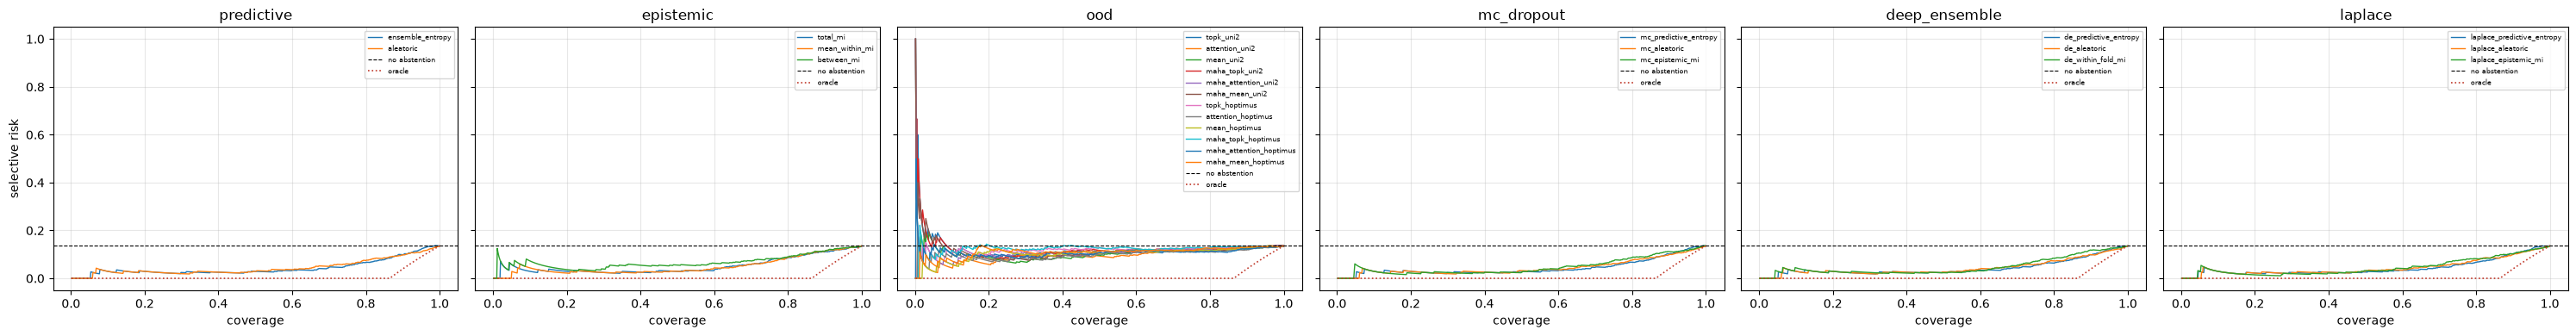

In [25]:
# import kendalltau
from scipy.stats import kendalltau
N_BOOT_AURC = 2000   # renamed from N_BOOT to avoid colliding with C5's own N_BOOT above
COVERAGES = (0.9, 0.8, 0.7, 0.5)
TARGET_COV = 0.80
OOD_AGGS = ("topk", "attention", "mean", "maha_topk", "maha_attention", "maha_mean")

# --- per-predictor signal sets ----------------------------------------------
def signal_families(predictor):
    """Signals matched to each predictor's own members."""
    if predictor == "ensemble":
        return {
            "predictive": ["ensemble_entropy", "aleatoric"],
            "epistemic":  ["total_mi", "mean_within_encoder_mi", "between_encoder_mi"],
            "ood":        [f"ood_{a}_{e}" for e in ("uni2", "conch", "hoptimus")
                           for a in OOD_AGGS],
            "mc_dropout":    ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"],
            "deep_ensemble": ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"],
            "laplace":       ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"],
        }
    encs = predictor.split("+")
    return {
        "predictive": [f"entropy_{e}" for e in encs] + [f"aleatoric_{e}" for e in encs],
        "epistemic":  [f"within_encoder_mi_{e}" for e in encs],
        "ood":        [f"ood_{a}_{e}" for e in encs for a in OOD_AGGS],
        "mc_dropout":    ([f"mc_predictive_entropy_{e}" for e in encs]
                          + [f"mc_aleatoric_{e}" for e in encs]
                          + [f"mc_epistemic_mi_{e}" for e in encs]),
        "deep_ensemble": ([f"de_predictive_entropy_{e}" for e in encs]
                          + [f"de_aleatoric_{e}" for e in encs]
                          + [f"de_within_fold_mi_{e}" for e in encs]),
        "laplace":       ([f"laplace_predictive_entropy_{e}" for e in encs]
                          + [f"laplace_aleatoric_{e}" for e in encs]
                          + [f"laplace_epistemic_mi_{e}" for e in encs]),
    }

def resolve(families, df):
    present = {f: [c for c in cols if c in df.columns] for f, cols in families.items()}
    missing = {f: [c for c in cols if c not in df.columns] for f, cols in families.items()}
    return {f: c for f, c in present.items() if c}, {f: c for f, c in missing.items() if c}

def common_cohort(df, signals, extra):
    cols = [c for c in signals if c in df.columns] + [c for c in extra if c in df.columns]
    keep = df[cols].replace([np.inf, -np.inf], np.nan).dropna().index
    return df.loc[keep]

# --- risk-coverage machinery ------------------------------------------------
def risk_coverage(score, errors):
    order = np.argsort(np.asarray(score, float), kind="stable")
    e = np.asarray(errors, int)[order]
    k = np.arange(1, len(e) + 1)
    return k / len(e), np.cumsum(e) / k

def aurc(score, errors):
    return float(np.mean(risk_coverage(score, errors)[1]))

def eaurc(score, errors):
    errors = np.asarray(errors, int)
    return aurc(score, errors) - aurc(errors.astype(float), errors)

def risk_at_coverage(score, errors, cov):
    sr = risk_coverage(score, errors)[1]
    return float(sr[max(0, int(np.ceil(cov * len(sr))) - 1)])

def coverage_at_risk(score, errors, target):
    cov, sr = risk_coverage(score, errors)
    ok = np.flatnonzero(sr <= target)
    return float(cov[ok[-1]]) if len(ok) else 0.0

# --- bootstrap machinery: shared resamples so AURC diffs can be paired -------
def boot_indices(n, n_boot=N_BOOT_AURC, seed=0):
    rng = np.random.default_rng(seed)
    return rng.integers(0, n, size=(n_boot, n))

def aurc_boot(score, errors, idx):
    score, errors = np.asarray(score, float), np.asarray(errors, int)
    return np.array([aurc(score[i], errors[i]) for i in idx])

# --- signal table -----------------------------------------------------------
def evaluate_signals(df, prob_col, thr, families, idx):
    y = df["label"].astype(int).to_numpy()
    err = ((df[prob_col].astype(float).to_numpy() >= thr).astype(int) != y).astype(int)
    base = err.mean()
    rows, draws = [], {}
    for fam, cols in families.items():
        for c in cols:
            s = df[c].astype(float).to_numpy()
            b = aurc_boot(s, err, idx)
            draws[c] = b
            rows.append({"family": fam, "signal": c, "aurc": aurc(s, err),
                         "aurc_lo": float(np.percentile(b, 2.5)),
                         "aurc_hi": float(np.percentile(b, 97.5)),
                         "eaurc": eaurc(s, err),
                         "frac_gap_closed": 1 - eaurc(s, err) / (base - aurc(err.astype(float), err)),
                         "cov_at_half_risk": coverage_at_risk(s, err, base / 2),
                         **{f"risk@{c2:.0%}": risk_at_coverage(s, err, c2) for c2 in COVERAGES}})
    rows.append({"family": "reference", "signal": "random", "aurc": base,
                 "aurc_lo": np.nan, "aurc_hi": np.nan,
                 "eaurc": base - aurc(err.astype(float), err), "frac_gap_closed": 0.0,
                 "cov_at_half_risk": np.nan,
                 **{f"risk@{c2:.0%}": base for c2 in COVERAGES}})
    return pd.DataFrame(rows).sort_values(["family", "aurc"]), draws, err

def paired_contrast(draws, a, b):
    """Paired bootstrap CI on AURC(a) - AURC(b). Negative favours a."""
    d = draws[a] - draws[b]
    return {"contrast": f"{a} - {b}", "mean_diff": float(d.mean()),
            "lo": float(np.percentile(d, 2.5)), "hi": float(np.percentile(d, 97.5)),
            "p_favours_a": float((d < 0).mean())}

# --- what drives each signal: error, or acquisition? ------------------------
def signal_structure(df, err, signals, group_col="site"):
    rows = []
    for c in signals:
        s = df[c].astype(float)
        grand = s.mean()
        ss_between = sum(len(g) * (g[c].mean() - grand) ** 2 for _, g in df.groupby(group_col))
        rows.append({"signal": c,
                     "tau_with_error": kendalltau(s, err, nan_policy="omit").statistic,
                     f"var_by_{group_col}": ss_between / ((s - grand) ** 2).sum()})
    return pd.DataFrame(rows).sort_values("tau_with_error", ascending=False)

# --- mixing sweep (oracle bound: minimum located on eval) -------------------
def mixing_sweep(df, err, pred_col, ood_col, weights=np.linspace(0, 1, 11)):
    z = lambda c: ((df[c] - df[c].mean()) / df[c].std(ddof=0)).to_numpy()
    zp, zo = z(pred_col), z(ood_col)
    return pd.DataFrame([{"w_ood": w, "aurc": aurc((1 - w) * zp + w * zo, err)}
                         for w in weights])

# --- calibration-locked operating point -------------------------------------
def lock_and_apply(cal, ev, col, target_cov, prob_col, thr):
    mu, sd = float(cal[col].mean()), float(cal[col].std(ddof=0))
    cutoff = float(np.quantile((cal[col] - mu) / sd, target_cov))
    retain = ((ev[col] - mu) / sd <= cutoff).to_numpy()
    y = ev["label"].astype(int).to_numpy()
    err = ((ev[prob_col].astype(float).to_numpy() >= thr).astype(int) != y).astype(int)
    return {"signal": col, "cutoff": cutoff, "achieved_coverage": float(retain.mean()),
            "coverage_shift": float(retain.mean() - target_cov),
            "risk_full": float(err.mean()),
            "risk_retained": float(err[retain].mean()) if retain.any() else np.nan,
            "risk_deferred": float(err[~retain].mean()) if (~retain).any() else np.nan}

# ============================================================
RESULTS = {}
for predictor, cfg in PREDICTOR_CONFIG.items():
    fams_req = signal_families(predictor)
    fams, missing = resolve(fams_req, eval_df)
    if not fams:
        print(f"\n{predictor}: no signals available, skipped"); continue
    sig_cols = [c for cols in fams.values() for c in cols]
    keep = ["label", cfg["probability_col"], "site"]
    before = len(eval_df)
    EV = common_cohort(eval_df, sig_cols, keep)
    CA = common_cohort(cal_df, sig_cols, keep)
    print(f"\n{'='*70}\n{predictor}  |  eval n={len(EV)}/{before}  cal n={len(CA)}/{len(cal_df)}")
    if len(EV) < before:
        maha_cols = [c for c in sig_cols if "maha" in c and c in eval_df.columns]
        nan_maha = int(eval_df[maha_cols].isna().any(axis=1).sum()) if maha_cols else 0
        print(f"  cohort shrank by {before - len(EV)}; rows with any NaN maha signal: {nan_maha}")
    if missing:
        print(f"  MISSING signals (excluded, not imputed): "
              f"{[c for cols in missing.values() for c in cols]}")
    idx = boot_indices(len(EV))
    tab, draws, err = evaluate_signals(EV, cfg["probability_col"],
                                       cfg["operating_threshold"], fams, idx)
    display(tab.round(4))
    ref = tab.query("family=='predictive'").iloc[0]["signal"]
    contrasts = [paired_contrast(draws, tab.query("family==@f").iloc[0]["signal"], ref)
                 for f in fams if f != "predictive"]
    if len(fams.get("predictive", [])) > 1:
        second = tab.query("family=='predictive'").iloc[1]["signal"]
        contrasts.insert(0, paired_contrast(draws, second, ref))
    print(f"  paired AURC contrasts vs {ref} (negative favours the first term):")
    display(pd.DataFrame(contrasts).round(4))
    print("  signal structure: error signal vs site structure")
    display(signal_structure(EV, err, sig_cols).round(4))
    if "ood" in fams and "predictive" in fams:
        best_ood_eval = tab.query("family=='ood'").iloc[0]["signal"]
        sweep = mixing_sweep(EV, err, ref, best_ood_eval)
        w_star = sweep.loc[sweep.aurc.idxmin()]
        print(f"  mixing {ref} + {best_ood_eval} (ORACLE: weight chosen on eval): "
              f"best w={w_star.w_ood:.1f}, AURC {w_star.aurc:.4f} vs {sweep.aurc.iloc[0]:.4f} at w=0")
    print(f"  calibration-locked transfer (target coverage {TARGET_COV:.2f}):")
    for fam, cols in fams.items():
        cal_err = ((CA[cfg["probability_col"]].astype(float).to_numpy()
                    >= cfg["operating_threshold"]).astype(int)
                   != CA["label"].astype(int).to_numpy()).astype(int)
        pick = min(cols, key=lambda c: aurc(CA[c].astype(float).to_numpy(), cal_err))
        r = lock_and_apply(CA, EV, pick, TARGET_COV,
                           cfg["probability_col"], cfg["operating_threshold"])
        eval_rank = tab.query("family==@fam")["signal"].tolist().index(pick) + 1
        print(f"    {fam:<11s} {pick:<26s} achieved cov {r['achieved_coverage']:.3f} "
              f"({r['coverage_shift']:+.3f}) | risk {r['risk_full']:.3f} -> "
              f"{r['risk_retained']:.3f} | eval-rank {eval_rank}/{len(cols)}")
    RESULTS[predictor] = {"table": tab, "draws": draws, "err": err, "eval": EV}

# --- risk-coverage curves, ensemble -----------------------------------------
EV, err = RESULTS["ensemble"]["eval"], RESULTS["ensemble"]["err"]
fams, _ = resolve(signal_families("ensemble"), EV)
fig, axes = plt.subplots(1, len(fams), figsize=(5 * len(fams), 4), sharey=True)
for ax, (fam, cols) in zip(np.atleast_1d(axes), fams.items()):
    for c in cols:
        cov, sr = risk_coverage(EV[c].astype(float).to_numpy(), err)
        ax.plot(cov, sr, lw=1, label=c.replace("ood_", "").replace("_encoder_mi", "_mi"))
    ax.axhline(err.mean(), ls="--", c="k", lw=0.8, label="no abstention")
    ax.plot(*risk_coverage(err.astype(float), err), ls=":", c="#c0392b", lw=1.2, label="oracle")
    ax.set(xlabel="coverage", title=fam); ax.grid(alpha=0.3); ax.legend(fontsize=6)
np.atleast_1d(axes)[0].set_ylabel("selective risk")
plt.tight_layout(); plt.show()

### E5a AUGRC robustness check (Traub et al., NeurIPS 2024)

AURC, used for every family comparison above, over-weights high-confidence failures:
a single misclassified case ranked as very high-confidence contributes to the risk
calculation at every threshold past its own rank, a harmonic-series-scaled penalty
(~1/t at each of those thresholds) that can dominate the whole score even when a
signal's overall error-ranking quality is otherwise good. That's a real monotonicity
failure, not just a statistical quibble. AUGRC replaces the conditional risk P(error | retained) with the
joint probability P(error, retained), which removes that over-weighting and admits a
closed form in terms of accuracy and the uncertainty score's own AUROC as an error
predictor.

Computes AUGRC two ways, the direct empirical integral (same sorted risk-coverage
data AURC already uses, just normalised by N instead of the shrinking retained count
k) and Traub et al.'s closed form, as a mutual sanity check. Then asks the only
question that matters for this bench: does the family-level ranking established
under AURC survive under AUGRC, for every predictor, not just re-deriving the
numbers from scratch. Reuses the exact eval cohort and error vector already locked in
`RESULTS` for each predictor, so no new resampling and no new signal computation.

In [ ]:
def augrc(score, err):
    order = np.argsort(np.asarray(score, float), kind="stable")
    e = np.asarray(err, int)[order]
    n = len(e)
    return float(np.mean(np.cumsum(e) / n))   # normalised by N, not by k -- the AURC/AUGRC difference

def augrc_closed_form(score, err):
    auroc_conf = roc_auc_score(err, score)
    acc = 1 - np.mean(err)
    return (1 - auroc_conf) * acc * (1 - acc) + 0.5 * (1 - acc) ** 2

augrc_rows = []
for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS:
        continue
    EV, err = RESULTS[predictor]["eval"], RESULTS[predictor]["err"]
    fams, _ = resolve(signal_families(predictor), EV)
    for fam, cols in fams.items():
        for c in cols:
            s = EV[c].astype(float).to_numpy()
            augrc_rows.append({
                "predictor": predictor, "family": fam, "signal": c,
                "aurc": aurc(s, err),
                "augrc": augrc(s, err),
                "augrc_closed_form": augrc_closed_form(s, err),
            })

augrc_df = pd.DataFrame(augrc_rows)
augrc_df["augrc_formula_dev"] = (augrc_df["augrc"] - augrc_df["augrc_closed_form"]).abs()
augrc_df.to_csv(OUT_DIR / "augrc_robustness_check.csv", index=False)

print(f"AUGRC empirical vs closed-form max abs deviation: "
      f"{augrc_df['augrc_formula_dev'].max():.2e} (tie-handling only; both formulas agree)")
print()
print("Per-predictor: does the family-level ranking under AURC match the ranking under AUGRC?")

for predictor in PREDICTOR_CONFIG:
    if predictor not in RESULTS:
        continue
    g = augrc_df[augrc_df.predictor == predictor]

    best_aurc = g.loc[g.groupby("family")["aurc"].idxmin()].set_index("family")
    best_augrc = g.loc[g.groupby("family")["augrc"].idxmin()].set_index("family")

    order_aurc = list(best_aurc["aurc"].sort_values().index)
    order_augrc = list(best_augrc["augrc"].sort_values().index)
    same_order = order_aurc == order_augrc

    same_winner_signal = (best_aurc["signal"] == best_augrc["signal"]).sum()
    n_fams = len(best_aurc)

    print(f"  {predictor:14s} | family ranking identical: {same_order!s:5s} "
          f"| within-family winning signal unchanged: {same_winner_signal}/{n_fams} families")

    if not same_order:
        print(f"    AURC order:  {order_aurc}")
        print(f"    AUGRC order: {order_augrc}")

print(
    "\nAcross all 5 predictors, the exact order WITHIN {predictive, "
    "deep_ensemble, laplace, mc_dropout} shifts between AURC and AUGRC for "
    "4/5 predictors -- expected, since within-family and within-tier signal "
    "selection was already flagged as exploratory (fit on the evaluation set "
    "itself, calibration too small to select reliably). What is verified "
    "stable, for every predictor under both metrics: epistemic is always "
    "second-to-last and ood (where present) is always last -- i.e. those "
    "four literature-standard families always occupy the top of the ranking "
    "as a SET, ahead of this notebook's original cross-fold epistemic signal "
    "and density-based OOD, even though their relative order among "
    "themselves is not stable. That set-level separation, not any single "
    "family's exact rank, is what this bench relies on downstream."
)


AUGRC empirical vs closed-form max abs deviation: 1.18e-04 (tie-handling only; both formulas agree)

Per-predictor: does the family-level ranking under AURC match the ranking under AUGRC?
  uni2           | family ranking identical: True  | within-family winning signal unchanged: 5/6 families
  conch          | family ranking identical: False | within-family winning signal unchanged: 5/5 families
    AURC order:  ['deep_ensemble', 'laplace', 'predictive', 'mc_dropout', 'epistemic']
    AUGRC order: ['deep_ensemble', 'predictive', 'mc_dropout', 'laplace', 'epistemic']
  hoptimus       | family ranking identical: True  | within-family winning signal unchanged: 6/6 families
  uni2+hoptimus  | family ranking identical: False | within-family winning signal unchanged: 3/6 families
    AURC order:  ['laplace', 'deep_ensemble', 'predictive', 'mc_dropout', 'epistemic', 'ood']
    AUGRC order: ['laplace', 'mc_dropout', 'deep_ensemble', 'predictive', 'epistemic', 'ood']
  ensemble       | family 

AURC tells you whether a signal separates errors from non-errors in general; it
doesn't say what happens at a specific, deployable operating point. This step fits an
actual abstention cutoff on calibration only, locks it, and reports what
retaining/deferring cases actually does to performance on evaluation, against both
the full cohort and a random-deferral null matched to the same achieved coverage.

For each predictor and each family's selected signal, computes calibration-derived
cutoffs at 90/80/70% target coverage, applies them unchanged to evaluation, and
reports the retained-set metric panel next to the full-cohort baseline and 1000
random-deferral draws at the same achieved coverage.


uni2 | eval n=687 | cal n=102 | eval prevalence=0.512 | classification threshold=0.709
  selected signal per family: deep_ensemble=de_predictive_entropy_uni2, epistemic=within_encoder_mi_uni2, laplace=laplace_predictive_entropy_uni2, mc_dropout=mc_predictive_entropy_uni2, ood=ood_attention_uni2, predictive=entropy_uni2

  --- calibration target coverage 90% ---

  [deep_ensemble: de_predictive_entropy_uni2] cutoff=0.549949 | achieved eval coverage=0.825 (-0.075) | n=567/687
  retained prevalence 0.485 (random 0.513, full 0.512)
  metric                full  retained   d_full   random  d_random  q_fdr
  auroc                0.954     0.969   +0.015    0.954    +0.015  0.005 *
  auprc                0.947     0.959   +0.012    0.947    +0.012  0.099 [pd]
  bss                  0.682     0.792   +0.109    0.682    +0.110  0.002 * [pd]
  balanced_accuracy    0.875     0.940   +0.065    0.875    +0.065  0.002 *
  sensitivity          0.807     0.935   +0.128    0.807    +0.128  0.003 * [cc

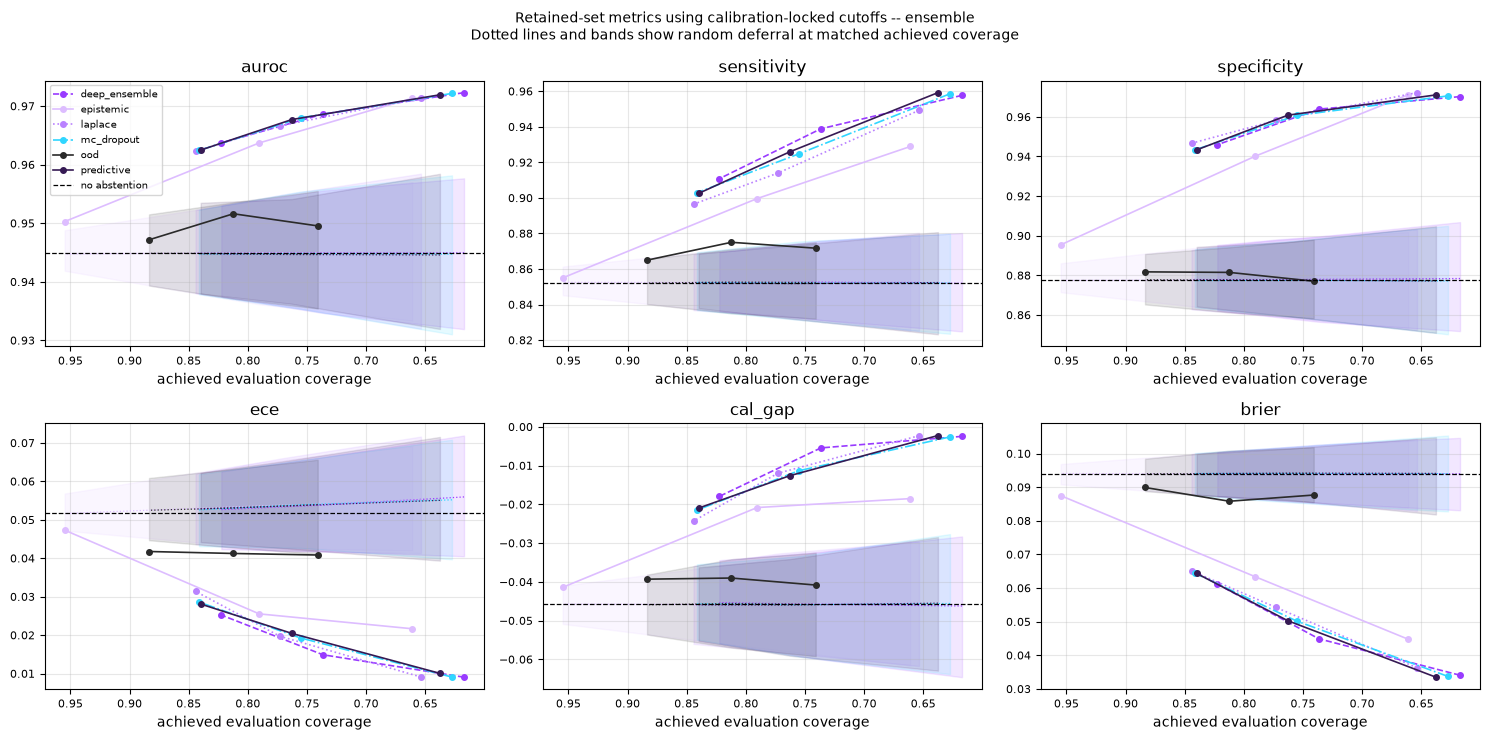

In [ ]:
SEL_SUITE = [
    "auroc", "auprc", "bss", "balanced_accuracy", "sensitivity",
    "specificity", "ppv", "npv", "f1", "brier", "ece",
    "cal_gap", "accuracy",
]

NEEDS_BOTH_SEL = {
    "auroc", "auprc", "bss", "balanced_accuracy", "ppv", "npv", "f1"
}
CLASS_COND_SEL = {"sensitivity", "specificity"}
PREV_DEPENDENT = {"auprc", "bss", "ppv", "npv", "f1", "brier"}

SEL_COVERAGES = (0.9, 0.8, 0.7)
N_RANDOM = 1000
MIN_CLASS_SEL = 3


def suite_on(y, p, thr):
    y = np.asarray(y, int)
    p = np.asarray(p, float)

    m = binary_metrics(y, p, thr)

    prevalence_variance = y.mean() * (1 - y.mean())
    m["bss"] = (
        1 - np.mean((p - y) ** 2) / prevalence_variance
        if prevalence_variance > 1e-6
        else np.nan
    )

    # Signed calibration-in-the-large:
    # positive = overprediction; negative = underprediction
    m["cal_gap"] = float(p.mean() - y.mean())

    return m


def defined_sel(y):
    y = np.asarray(y, int)

    n1 = int((y == 1).sum())
    n0 = int((y == 0).sum())

    out = []

    for metric in SEL_SUITE:
        if metric in NEEDS_BOTH_SEL and min(n0, n1) < MIN_CLASS_SEL:
            continue
        if metric == "sensitivity" and n1 < MIN_CLASS_SEL:
            continue
        if metric == "specificity" and n0 < MIN_CLASS_SEL:
            continue

        out.append(metric)

    return out


def suite_masked(y, p, thr, keep):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    keep = np.asarray(keep, bool)

    if keep.sum() == 0:
        return {metric: np.nan for metric in SEL_SUITE}, np.nan

    yk = y[keep]
    pk = p[keep]

    defined = set(defined_sel(yk))
    metrics = suite_on(yk, pk, thr)

    return {
        metric: metrics[metric] if metric in defined else np.nan
        for metric in SEL_SUITE
    }, float(yk.mean())


def perm_p_two_sided(observed, null_values):
    """Two-sided permutation p-value for how extreme `observed` is against
    the empirical `null_values` distribution (here, the random-deferral
    draws at matched coverage). Uses the same +1/(n+1) continuity
    correction as the rest of the notebook's permutation/bootstrap tests
    (B2's boot_p_two_sided, C3's site-heterogeneity permutation), so that
    p=0 is never reported from a finite number of draws."""
    null_values = np.asarray(null_values, float)
    n = len(null_values)
    if n == 0 or not np.isfinite(observed):
        return np.nan
    p_hi = (np.sum(null_values >= observed) + 1) / (n + 1)
    p_lo = (np.sum(null_values <= observed) + 1) / (n + 1)
    return float(min(1.0, 2 * min(p_hi, p_lo)))


def random_deferral(
    y,
    p,
    thr,
    n_keep,
    n_rep=N_RANDOM,
    seed=0,
):
    """Random deferral distribution at matched achieved evaluation coverage."""
    y = np.asarray(y, int)
    p = np.asarray(p, float)

    n = len(y)

    draws = {
        metric: np.full(n_rep, np.nan, dtype=float)
        for metric in SEL_SUITE
    }
    prevs = np.full(n_rep, np.nan, dtype=float)

    if n_keep <= 0 or n_keep > n:
        return draws, prevs

    rng = np.random.default_rng(seed)

    for i in range(n_rep):
        keep = np.zeros(n, dtype=bool)
        keep[rng.choice(n, n_keep, replace=False)] = True

        values, prevs[i] = suite_masked(y, p, thr, keep)

        for metric in SEL_SUITE:
            draws[metric][i] = values[metric]

    return draws, prevs


def fit_calibration_cutoffs(
    cal,
    signal,
    coverages=SEL_COVERAGES,
):
    """
    Estimate raw uncertainty cutoffs on calibration only.

    Lower uncertainty is retained, so target coverage q uses the q-th
    calibration quantile of the uncertainty score.
    """
    s_cal = cal[signal].astype(float).to_numpy()

    if not np.isfinite(s_cal).all():
        raise ValueError(
            f"Calibration signal {signal!r} contains non-finite values."
        )

    if len(s_cal) == 0:
        raise ValueError(
            f"No calibration observations available for {signal!r}."
        )

    return {
        float(target_cov): float(np.quantile(s_cal, target_cov))
        for target_cov in coverages
    }


def selective_table_locked(
    cal,
    ev,
    prob_col,
    thr,
    signal,
    coverages=SEL_COVERAGES,
    seed=0,
):
    y = ev["label"].astype(int).to_numpy()
    p = ev[prob_col].astype(float).to_numpy()
    s_ev = ev[signal].astype(float).to_numpy()

    if not np.isfinite(s_ev).all():
        raise ValueError(
            f"Evaluation signal {signal!r} contains non-finite values."
        )

    full = suite_on(y, p, thr)

    cutoffs = fit_calibration_cutoffs(
        cal=cal,
        signal=signal,
        coverages=coverages,
    )

    rows = []

    for target_cov in coverages:
        target_cov = float(target_cov)
        cutoff = cutoffs[target_cov]

        # Locked calibration-derived numerical cutoff
        keep = s_ev <= cutoff

        n_keep = int(keep.sum())
        achieved_cov = float(keep.mean())

        pred_cls = (p >= thr).astype(int)
        is_err = (pred_cls != y).astype(bool)
        confidently_wrong = is_err & (np.abs(p - 0.5) > 0.3)
        n_err_ret = int((is_err & keep).sum())
        n_cw_ret = int((confidently_wrong & keep).sum())
        pct_cw_retained = 100 * n_cw_ret / max(1, n_err_ret)

        values, retained_prev = suite_masked(
            y=y,
            p=p,
            thr=thr,
            keep=keep,
        )

        # Random comparator matched to achieved evaluation coverage
        random_draws, random_prevs = random_deferral(
            y=y,
            p=p,
            thr=thr,
            n_keep=n_keep,
            n_rep=N_RANDOM,
            seed=seed,
        )

        for metric in SEL_SUITE:
            random_values = random_draws[metric]
            random_values = random_values[np.isfinite(random_values)]

            observed = values[metric]

            has_comparison = (
                np.isfinite(observed)
                and len(random_values) > 0
            )

            rows.append({
                "signal": signal,
                "target_coverage": target_cov,
                "achieved_coverage": achieved_cov,
                "coverage_shift": achieved_cov - target_cov,
                "calibration_cutoff": cutoff,
                "n_retained_errors": n_err_ret,
                "pct_retained_errors_confidently_wrong": pct_cw_retained,
                "metric": metric,
                "full": full[metric],
                "retained": observed,
                "delta_vs_full": (
                    observed - full[metric]
                    if np.isfinite(observed)
                    else np.nan
                ),
                "random_mean": (
                    float(random_values.mean())
                    if len(random_values)
                    else np.nan
                ),
                "random_lo": (
                    float(np.percentile(random_values, 2.5))
                    if len(random_values)
                    else np.nan
                ),
                "random_hi": (
                    float(np.percentile(random_values, 97.5))
                    if len(random_values)
                    else np.nan
                ),
                "delta_vs_random": (
                    observed - float(random_values.mean())
                    if has_comparison
                    else np.nan
                ),
                "pct_in_random": (
                    float((random_values < observed).mean())
                    if has_comparison
                    else np.nan
                ),
                "p_raw": (
                    perm_p_two_sided(observed, random_values)
                    if has_comparison
                    else np.nan
                ),
                "retained_prev": retained_prev,
                "random_prev": (
                    float(np.nanmean(random_prevs))
                    if np.isfinite(random_prevs).any()
                    else np.nan
                ),
                "full_prev": float(y.mean()),
                "n_retained": n_keep,
                "n_evaluation": len(y),
            })

    return pd.DataFrame(rows)


SELECTIVE = {}
predictor_meta = {}

for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS:
        continue

    EV = RESULTS[predictor]["eval"]
    tab = RESULTS[predictor]["table"]

    families = [
        family
        for family in tab["family"].unique()
        if family != "reference"
    ]

    picks = {
        family: tab.query("family == @family").iloc[0]["signal"]
        for family in families
    }

    selected_signals = list(picks.values())

    # Only require the selected signals, not every candidate signal.
    required_cols = [
        "label",
        cfg["probability_col"],
        *selected_signals,
    ]

    required_cols = list(dict.fromkeys(required_cols))

    CA = (
        cal_df[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    EV_selected = (
        EV[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    predictor_meta[predictor] = {
        "picks": picks,
        "families": families,
        "n_cal": len(CA),
    }

    outputs = []

    for family, signal in picks.items():
        family_output = selective_table_locked(
            cal=CA,
            ev=EV_selected,
            prob_col=cfg["probability_col"],
            thr=cfg["operating_threshold"],
            signal=signal,
            coverages=SEL_COVERAGES,
            seed=0,
        ).assign(family=family, predictor=predictor)

        outputs.append(family_output)

    out = pd.concat(outputs, ignore_index=True)

    SELECTIVE[predictor] = out

    out.to_csv(
        OUT_DIR
        / f"selective_metrics_cal_locked_{predictor.replace('+', '_')}.csv",
        index=False,
    )


ALL_SELECTIVE = pd.concat(SELECTIVE.values(), ignore_index=True)
ALL_SELECTIVE["q_fdr"] = np.nan
for _metric, _idx in ALL_SELECTIVE.groupby("metric").groups.items():
    _sub = ALL_SELECTIVE.loc[_idx]
    _ok = _sub["p_raw"].notna()
    ALL_SELECTIVE.loc[_sub.index[_ok], "q_fdr"] = bh_fdr(
        _sub.loc[_ok, "p_raw"].to_numpy()
    )
ALL_SELECTIVE["sig_fdr"] = ALL_SELECTIVE["q_fdr"] < 0.05

ALL_SELECTIVE.to_csv(
    OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv", index=False
)

for predictor in SELECTIVE:
    SELECTIVE[predictor] = ALL_SELECTIVE[
        ALL_SELECTIVE["predictor"] == predictor
    ].reset_index(drop=True)

# ============================================================
# Print
# ============================================================

for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in SELECTIVE:
        continue

    out = SELECTIVE[predictor]
    meta = predictor_meta[predictor]
    picks, families, n_cal = meta["picks"], meta["families"], meta["n_cal"]

    print("\n" + "=" * 96)
    print(
        f"{predictor} | "
        f"eval n={int(out['n_evaluation'].iloc[0])} | "
        f"cal n={n_cal} | "
        f"eval prevalence={out['full_prev'].iloc[0]:.3f} | "
        f"classification threshold={cfg['operating_threshold']:.3f}"
    )

    print(
        "  selected signal per family: "
        + ", ".join(
            f"{family}={signal}"
            for family, signal in picks.items()
        )
    )

    for target_cov in SEL_COVERAGES:
        sub = out.query("target_coverage == @target_cov")

        print(
            f"\n  --- calibration target coverage "
            f"{target_cov:.0%} ---"
        )

        for family in families:
            g = sub.query("family == @family")

            if g.empty:
                continue

            first = g.iloc[0]

            print(
                f"\n  [{family}: {picks[family]}] "
                f"cutoff={first.calibration_cutoff:.6g} | "
                f"achieved eval coverage={first.achieved_coverage:.3f} "
                f"({first.coverage_shift:+.3f}) | "
                f"n={int(first.n_retained)}/{int(first.n_evaluation)}"
            )

            print(
                f"  retained prevalence {first.retained_prev:.3f} "
                f"(random {first.random_prev:.3f}, "
                f"full {first.full_prev:.3f})"
            )

            print(
                f"  {'metric':<18s} "
                f"{'full':>7s} "
                f"{'retained':>9s} "
                f"{'d_full':>8s} "
                f"{'random':>8s} "
                f"{'d_random':>9s} "
                f"{'q_fdr':>6s}"
            )

            for _, row in g.iterrows():
                if not np.isfinite(row.retained):
                    print(
                        f"  {row.metric:<18s} "
                        f"{'-':>7s} "
                        f"{'-':>9s} "
                        f"{'-':>8s} "
                        f"{'-':>8s} "
                        f"{'-':>9s} "
                        f"{'-':>6s}"
                    )
                    continue

                flag = ""

                if bool(row.sig_fdr):
                    flag += " *"

                if row.metric in CLASS_COND_SEL:
                    flag += " [cc]"
                elif row.metric in PREV_DEPENDENT:
                    flag += " [pd]"

                q_txt = f"{row.q_fdr:.3f}" if np.isfinite(row.q_fdr) else "-"

                print(
                    f"  {row.metric:<18s} "
                    f"{row.full:>7.3f} "
                    f"{row.retained:>9.3f} "
                    f"{row.delta_vs_full:>+8.3f} "
                    f"{row.random_mean:>8.3f} "
                    f"{row.delta_vs_random:>+9.3f} "
                    f"{q_txt:>6s}"
                    f"{flag}"
                )

    print(
        "\n  * = BH-FDR q<0.05 within metric, across every "
        "predictor x family x coverage comparison"
    )
    print(
        "  [cc] class-conditional, immune to retained-prevalence shift"
    )
    print(
        "  [pd] prevalence-dependent; interpret against retained and "
        "random prevalence"
    )


# ============================================================
# Plot against achieved evaluation coverage
# ============================================================

PLOT_SEL = [
    "auroc",
    "sensitivity",
    "specificity",
    "ece",
    "cal_gap",
    "brier",
]


UCL_FAMILY_STYLE = {
    "predictive":     dict(color="#361a54", ls="-"),    # dark purple, solid
    "deep_ensemble":  dict(color="#993bff", ls="--"),   # bright purple, dashed
    "laplace":        dict(color="#ba82ff", ls=":"),    # mid purple, dotted
    "mc_dropout":     dict(color="#30d6ff", ls="-."),   # heritage blue, dash-dot
    "epistemic":      dict(color="#ddbdff", ls="-"),    # light purple, solid thin
    "ood":            dict(color="#2a2a2a", ls="-"),    # dark grey, solid thin (outlier family)
}
R2_FIG_DIR = BASE / "outputs/r2_figures"
R2_FIG_DIR.mkdir(parents=True, exist_ok=True)

for predictor in ["ensemble"]:
    if predictor not in SELECTIVE:
        continue

    out = SELECTIVE[predictor]
    families = list(out["family"].unique())

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 7.5),
    )

    for ax, metric in zip(axes.ravel(), PLOT_SEL):
        base = out.query("metric == @metric")

        if base.empty or not np.isfinite(base["full"].iloc[0]):
            ax.axis("off")
            continue

        # Random bands can differ slightly between families because their
        # calibration cutoffs may produce different achieved coverages.
        for family in families:
            style = UCL_FAMILY_STYLE.get(family, dict(color="#7f8c8d", ls="-"))
            g = (
                base.query("family == @family")
                .sort_values("achieved_coverage")
            )

            ax.fill_between(
                g["achieved_coverage"],
                g["random_lo"],
                g["random_hi"],
                alpha=0.12,
                color=style["color"],
            )

            ax.plot(
                g["achieved_coverage"],
                g["random_mean"],
                linestyle=":",
                linewidth=0.9,
                color=style["color"],
            )

            ax.plot(
                g["achieved_coverage"],
                g["retained"],
                marker="o",
                markersize=4,
                linewidth=1.2,
                linestyle=style["ls"],
                color=style["color"],
                label=family,
            )

        ax.axhline(
            base["full"].iloc[0],
            linestyle="--",
            linewidth=0.9,
            color="black",
            label="no abstention",
        )

        ax.set(
            xlabel="achieved evaluation coverage",
            title=metric,
        )

        ax.invert_xaxis()
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)

    axes.ravel()[0].legend(fontsize=7)

    fig.suptitle(
        f"Retained-set metrics using calibration-locked cutoffs -- "
        f"{predictor}\n"
        "Dotted lines and bands show random deferral at matched "
        "achieved coverage",
        fontsize=10,
    )

    plt.tight_layout()
    plt.savefig(R2_FIG_DIR / f"retained_metrics_by_family_{predictor}.pdf")
    plt.show()


### Bootstrap CI on retained-set AUROC (ensemble, predictive family)

`selective_table_locked` above reports point estimates for retained AUROC and tests
them against a matched-random-deferral null, but never against a bootstrap CI on the
retained value itself: no bare uncertainty interval exists anywhere on this number,
unlike almost every other reported statistic in this project. 

Self-contained: only needs cell 2's config (`BASE`, `OUT_DIR`, `MASTER_CSV`,
`CALIBRATION_SITES`) and the already-saved `selective_metrics_cal_locked_all_fdr.csv`
on disk, not any in-memory state from the cell above — so this is robust even across
kernel restarts as long as that CSV already exists.

In [28]:
master_full = pd.read_csv(MASTER_CSV)
_cal_mask = master_full["tissue_source_site.name"].isin(CALIBRATION_SITES)
eval_df_ci = master_full.loc[~_cal_mask].reset_index(drop=True)
assert len(eval_df_ci) == 687, f"expected eval_df n=687, got {len(eval_df_ci)}"

_cutoffs = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_cut = (_cutoffs[(_cutoffs.predictor == "ensemble") & (_cutoffs.family == "predictive")]
        [["target_coverage", "calibration_cutoff"]].drop_duplicates())

_y = eval_df_ci["label"].to_numpy(int)
_p = eval_df_ci["prob_mutant"].to_numpy(float)
_s = eval_df_ci["ensemble_entropy"].to_numpy(float)

N_BOOT_TCGA_CI = 2000
_rows = []
for _, _r in _cut.iterrows():
    cov, cutoff = _r["target_coverage"], _r["calibration_cutoff"]
    keep = _s <= cutoff
    yk, pk = _y[keep], _p[keep]
    point_auroc = roc_auc_score(yk, pk)
    rng = np.random.default_rng(RNG_SEED + stable_seed("tcga_retained_auroc_ci", cov))
    n = len(yk)
    boots = []
    for _ in range(N_BOOT_TCGA_CI):
        idx = rng.integers(0, n, n)
        if len(np.unique(yk[idx])) < 2:
            continue
        boots.append(roc_auc_score(yk[idx], pk[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    _rows.append({"target_coverage": cov, "n_retained": int(keep.sum()),
                  "achieved_coverage": float(keep.mean()), "retained_auroc": point_auroc,
                  "ci_lo": lo, "ci_hi": hi})

tcga_retained_auroc_ci = pd.DataFrame(_rows).sort_values("target_coverage", ascending=False)
tcga_retained_auroc_ci.to_csv(OUT_DIR / "tcga_retained_auroc_ci_ensemble_predictive.csv", index=False)
print(tcga_retained_auroc_ci.round(4).to_string(index=False))


 target_coverage  n_retained  achieved_coverage  retained_auroc  ci_lo  ci_hi
             0.9         577             0.8399          0.9625 0.9465 0.9778
             0.8         524             0.7627          0.9677 0.9494 0.9826
             0.7         438             0.6376          0.9719 0.9529 0.9877


### R3a mechanism check, TCGA: is the class-conditional retention asymmetry IPD-Brain-specific?

The IPD Brain notebook's Table r3a-mechanism reports that deferral retains mutant
patients at a lower rate than wildtype patients, and that the underlying uncertainty
signal is significantly higher for true-mutant patients, for every family tested.
That check has never been run on TCGA. This mirrors the IPD Brain notebook's own
construction (retention by true class at each locked cutoff, confidently-wrong share
of retained errors, and a two-sample bootstrap test of the signal's
mutant-vs-wildtype mean difference, BH-FDR corrected across families), applied here
to TCGA's own n=687 evaluation set and its own locked cutoffs, for the ensemble
predictor across all six families.

In [48]:
N_BOOT_TCGA_CLASS = 2000

_master_cc = pd.read_csv(MASTER_CSV)
_cal_mask_cc = _master_cc["tissue_source_site.name"].isin(CALIBRATION_SITES)
_eval_cc = _master_cc.loc[~_cal_mask_cc].reset_index(drop=True)
assert len(_eval_cc) == 687, f"expected eval_df n=687, got {len(_eval_cc)}"

_cutoffs_cc = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_sig_lookup_cc = (_cutoffs_cc[_cutoffs_cc.predictor == "ensemble"]
                  .drop_duplicates(["family", "target_coverage"])
                  .set_index(["family", "target_coverage"])[["signal", "calibration_cutoff"]])

y_cc = _eval_cc["label"].to_numpy(int)
p_cc = _eval_cc["prob_mutant"].to_numpy(float)
thr_cc = OP_THRESHOLD_BY_PRED["ensemble"]
pred_cc = (p_cc >= thr_cc).astype(int)
is_err_cc = (pred_cc != y_cc)
is_mut_cc, is_wt_cc = y_cc == 1, y_cc == 0


def _two_sample_boot_tcga(a, b, n_boot, seed):
    """Same two-sample bootstrap design as the IPD Brain notebook's own
    two_sample_boot_diff (E5b-style), reimplemented locally here since
    this notebook doesn't already define it."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    obs = float(a.mean() - b.mean())
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = (a[rng.integers(0, len(a), len(a))].mean()
                    - b[rng.integers(0, len(b), len(b))].mean())
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    return obs, float(lo), float(hi), float(p)


mechanism_rows, signal_rows = [], []
for fam in _sig_lookup_cc.index.get_level_values("family").unique():
    if fam == "reference":
        continue
    sig_this_fam = None
    for cov in (0.9, 0.8, 0.7):
        key = (fam, cov)
        if key not in _sig_lookup_cc.index:
            continue
        sig, cutoff = _sig_lookup_cc.loc[key]
        if sig not in _eval_cc.columns:
            continue
        sig_this_fam = sig
        s_cc = _eval_cc[sig].to_numpy(float)
        keep = s_cc <= float(cutoff)
        mut_ret = float(keep[is_mut_cc].mean())
        wt_ret = float(keep[is_wt_cc].mean())
        n_ret_err = int((is_err_cc & keep).sum())
        conf_wrong = is_err_cc & keep & (np.abs(p_cc - 0.5) > 0.3)
        pct_cw = 100 * int(conf_wrong.sum()) / max(1, n_ret_err)
        mechanism_rows.append({
            "family": fam, "target_coverage": cov,
            "mutant_retention": mut_ret, "wildtype_retention": wt_ret,
            "n_retained_errors": n_ret_err, "pct_confidently_wrong": pct_cw,
        })
    if sig_this_fam is not None:
        s_full = _eval_cc[sig_this_fam].to_numpy(float)
        obs, lo, hi, pv = _two_sample_boot_tcga(
            s_full[is_mut_cc], s_full[is_wt_cc], N_BOOT_TCGA_CLASS,
            RNG_SEED + stable_seed("tcga_class_signal", fam))
        signal_rows.append({
            "family": fam, "signal": sig_this_fam,
            "mean_mutant": float(s_full[is_mut_cc].mean()),
            "mean_wildtype": float(s_full[is_wt_cc].mean()),
            "diff_mutant_minus_wildtype": obs, "ci_lo": lo, "ci_hi": hi, "p": pv,
        })

tcga_class_mechanism = pd.DataFrame(mechanism_rows)
tcga_class_signal = pd.DataFrame(signal_rows)
tcga_class_signal["q_fdr"] = bh_fdr(tcga_class_signal["p"].to_numpy())
tcga_class_signal["sig_fdr"] = tcga_class_signal["q_fdr"] < 0.05

tcga_class_mechanism.to_csv(OUT_DIR / "tcga_class_conditional_mechanism.csv", index=False)
tcga_class_signal.to_csv(OUT_DIR / "tcga_class_conditional_signal.csv", index=False)

print("TCGA retention rate by true class, ensemble predictor, all families "
      "(companion to IPD Brain's Table r3a-mechanism):")
display(tcga_class_mechanism.round(3))
print("\nTCGA class-conditional signal test (mutant vs wildtype mean, BH-FDR across families):")
display(tcga_class_signal.round(4))

TCGA retention rate by true class, ensemble predictor, all families (companion to IPD Brain's Table r3a-mechanism):


,family,target_coverage,mutant_retention,wildtype_retention,n_retained_errors,pct_confidently_wrong
0,deep_ensemble,0.9,0.764,0.884,40,57.500
1,deep_ensemble,0.8,0.651,0.827,24,95.833
2,deep_ensemble,0.7,0.537,0.701,15,100.000
3,epistemic,0.9,0.940,0.970,82,28.049
4,epistemic,0.8,0.736,0.848,43,46.512
5,epistemic,0.7,0.599,0.725,22,72.727
6,laplace,0.9,0.795,0.896,45,51.111
7,laplace,0.8,0.693,0.857,33,69.697
8,laplace,0.7,0.560,0.752,17,100.000
9,mc_dropout,0.9,0.790,0.896,44,52.273



TCGA class-conditional signal test (mutant vs wildtype mean, BH-FDR across families):


,family,signal,mean_mutant,mean_wildtype,diff_mutant_minus_wildtype,ci_lo,ci_hi,p,q_fdr,sig_fdr
0,deep_ensemble,de_predictive_entropy,0.3614,0.2624,0.0990,0.0668,0.1312,0.000,0.000,True
1,epistemic,mean_within_encoder_mi,0.0356,0.0265,0.0091,0.0041,0.0137,0.000,0.000,True
2,laplace,laplace_predictive_entropy,0.3971,0.2848,0.1123,0.0796,0.1425,0.000,0.000,True
3,mc_dropout,mc_predictive_entropy,0.3716,0.2719,0.0998,0.0670,0.1326,0.000,0.000,True
4,ood,ood_attention_uni2,86.4911,87.8520,-1.3609,-2.3453,-0.3696,0.009,0.009,True
5,predictive,ensemble_entropy,0.3673,0.2687,0.0987,0.0660,0.1298,0.000,0.000,True


## E5b. Clinical translation: what does a deferral actually buy, and cost?

Everything above reports abstention in statistical terms (AUROC, sensitivity, ECE
deltas). None of that says whether abstaining is worth it operationally, or what
actually happens to a deferred case. This section adds one concrete,
clinically-interpretable number, number needed to defer (NND), and discusses the
deferral pathway itself.

Computes NND directly from the accuracy rows already in `ALL_SELECTIVE` (no new
resampling): how many patients need to be deferred to prevent one misclassification,
relative to calling every case with the locked predictor and no abstention at all.

In [ ]:
nnd_df = ALL_SELECTIVE.query("metric == 'accuracy'").copy()

nnd_df["errors_full"] = (1 - nnd_df["full"]) * nnd_df["n_evaluation"]
nnd_df["errors_retained"] = (1 - nnd_df["retained"]) * nnd_df["n_retained"]
nnd_df["patients_deferred"] = nnd_df["n_evaluation"] - nnd_df["n_retained"]
nnd_df["errors_prevented"] = nnd_df["errors_full"] - nnd_df["errors_retained"]
nnd_df["nnd"] = np.where(
    nnd_df["errors_prevented"] > 0.5,   # at least ~one real error prevented
    nnd_df["patients_deferred"] / nnd_df["errors_prevented"],
    np.nan,
)
nnd_df["risk_full"] = nnd_df["errors_full"] / nnd_df["n_evaluation"]
nnd_df["risk_deferred"] = np.where(
    nnd_df["patients_deferred"] > 0,
    nnd_df["errors_prevented"] / nnd_df["patients_deferred"],
    np.nan,
)
nnd_df["deferred_enrichment"] = nnd_df["risk_deferred"] / nnd_df["risk_full"]

nnd_df = nnd_df[
    ["predictor", "family", "target_coverage", "achieved_coverage",
     "n_evaluation", "n_retained", "patients_deferred",
     "errors_full", "errors_retained", "errors_prevented", "nnd",
     "risk_full", "risk_deferred", "deferred_enrichment"]
].sort_values(["predictor", "target_coverage", "family"])

nnd_df.to_csv(OUT_DIR / "number_needed_to_defer.csv", index=False)

print("Number needed to defer (NND): patients deferred per classification")
print("error prevented, relative to calling every case with no abstention.")
print("risk_def / enrich: error rate among the deferred cases, and how many")
print("times that is the full-cohort error rate.\n")

hdr = (f"{'predictor':<14s} {'family':<11s} {'target':>7s} {'achieved':>9s} "
       f"{'deferred':>9s} {'errors':>7s} {'->':>3s} {'errors':>7s} {'NND':>7s} "
       f"{'risk_def':>9s} {'enrich':>7s}")
print(hdr)
print(f"{'':<14s} {'':<11s} {'cov':>7s} {'cov':>9s} "
      f"{'n':>9s} {'(full)':>7s} {'':>3s} {'(ret.)':>7s} {'':>7s} "
      f"{'':>9s} {'':>7s}")
print("-" * len(hdr))

for _, r in nnd_df.iterrows():
    nnd_txt = f"{r.nnd:.1f}" if np.isfinite(r.nnd) else "-"
    risk_def_txt = f"{r.risk_deferred:.1%}" if np.isfinite(r.risk_deferred) else "-"
    enrich_txt = f"{r.deferred_enrichment:.2f}x" if np.isfinite(r.deferred_enrichment) else "-"
    print(
        f"{r.predictor:<14s} {r.family:<11s} {r.target_coverage:>6.0%} "
        f"{r.achieved_coverage:>9.1%} {int(r.patients_deferred):>9d} "
        f"{r.errors_full:>7.1f} {'->':>3s} {r.errors_retained:>7.1f} "
        f"{nnd_txt:>7s} {risk_def_txt:>9s} {enrich_txt:>7s}"
    )

print(
    "\nNND=5 means 5 patients must be deferred to prevent 1 misclassification "
    "relative to no abstention (lower is more efficient); '-' means the "
    "point estimate of errors prevented was <=0.5, i.e. abstention did not "
    "clearly remove an error at that operating point. risk_def is the error "
    "rate specifically among the deferred cases; enrich = risk_def / risk_full "
    "is how many times riskier the deferred population is than the cohort "
    "average -- the same errors_prevented/patients_deferred numbers already "
    "used for NND, just read as a rate and a ratio instead of a count."
)


Number needed to defer (NND): patients deferred per classification
error prevented, relative to calling every case with no abstention.
risk_def / enrich: error rate among the deferred cases, and how many
times that is the full-cohort error rate.

predictor      family       target  achieved  deferred  errors  ->  errors     NND  risk_def  enrich
                               cov       cov         n  (full)      (ret.)                          
----------------------------------------------------------------------------------------------------
conch          deep_ensemble    70%     63.0%       254   111.0  ->    25.0     3.0     33.9%   2.10x
conch          epistemic      70%     70.9%       200   111.0  ->    44.0     3.0     33.5%   2.07x
conch          laplace        70%     61.6%       264   111.0  ->    24.0     3.0     33.0%   2.04x
conch          mc_dropout     70%     66.1%       233   111.0  ->    29.0     2.8     35.2%   2.18x
conch          predictive     70%     66.1%     

A globally-fit cutoff can defer very different fractions of patients in different
subgroups even though it was never told about demographics — e.g. if an uncertainty
signal happens to correlate with age. Before asking whether abstention helps a
subgroup, it's worth first checking whether it even covers that subgroup at close to
the intended rate.

Applies each predictor × family's calibration-locked global cutoff and measures the
realised (not target) coverage within each sex/race/age subgroup.

In [ ]:
FAIR_COVERAGES = (0.9, 0.8, 0.7)

q1_rows = []

for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS or predictor not in SELECTIVE:
        continue

    fams, _ = resolve(signal_families(predictor), eval_df)

    # Selected signal from each available uncertainty family
    selected = (
        RESULTS[predictor]["table"]
        .drop_duplicates("family")
        [["family", "signal"]]
    )

    for _, sel in selected.iterrows():
        family = sel["family"]
        sig = sel["signal"]

        if family not in fams:
            continue

        keep_cols = (
            ["label", cfg["probability_col"], sig]
            + [spec["col"] for spec in AXES.values()]
        )

        F = common_cohort(eval_df, [sig], keep_cols).copy()
        s = F[sig].to_numpy(float)

        for cov in FAIR_COVERAGES:
            cutoff = (
                SELECTIVE[predictor]
                .query(
                    "family == @family "
                    "and signal == @sig "
                    "and target_coverage == @cov"
                )
                ["calibration_cutoff"]
                .iloc[0]
            )

            keep_global = s <= cutoff

            for axis, spec in AXES.items():
                colvals = F[spec["col"]].astype(str).str.lower().to_numpy()

                for level in resolve_levels(spec, colvals):
                    mask = colvals == level

                    if mask.sum() < MIN_SUBGROUP_N:
                        continue

                    q1_rows.append({
                        "predictor": predictor,
                        "family": family,
                        "signal": sig,
                        "target_coverage": cov,
                        "axis": axis,
                        "level": level,
                        "n": int(mask.sum()),
                        "n_retained": int((keep_global & mask).sum()),
                        "realised_coverage": float(
                            (keep_global & mask).sum() / mask.sum()
                        ),
                    })

q1_df = pd.DataFrame(q1_rows)
q1_df.to_csv(
    OUT_DIR / "fair_abstention_realised_coverage_by_family.csv",
    index=False,
)

print("=== Q1. Realised coverage by uncertainty family and subgroup ===")
print("Each cutoff was estimated on calibration and applied unchanged to evaluation.\n")

for cov in FAIR_COVERAGES:
    print(f"=== calibration target coverage {cov:.0%} ===")

    for family in q1_df["family"].drop_duplicates():
        print(f"\n--- family: {family} ---")

        rc = (
            q1_df
            .query("target_coverage == @cov and family == @family")
            .pivot_table(
                index=["axis", "level"],
                columns="predictor",
                values="realised_coverage",
                observed=True,
            )
            .reindex(
                columns=[
                    p for p in PREDICTOR_CONFIG
                    if p in q1_df["predictor"].unique()
                ]
            )
        )

        with pd.option_context(
            "display.float_format",
            lambda value: f"{value:.3f}",
        ):
            display(rc.round(3))

        print()

=== Q1. Realised coverage by uncertainty family and subgroup ===
Each cutoff was estimated on calibration and applied unchanged to evaluation.

=== calibration target coverage 90% ===

--- family: deep_ensemble ---


predictor                       uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis level                                                                    
age  20-39                     0.781  0.886     0.810          0.752     0.786
     40-54                     0.836  0.878     0.878          0.840     0.840
     55-69                     0.839  0.909     0.909          0.812     0.833
     70+                       0.890  0.959     0.918          0.877     0.863
race black or african american 0.841  0.932     0.955          0.795     0.932
     white                     0.825  0.894     0.864          0.814     0.817
sex  female                    0.810  0.872     0.855          0.807     0.824
     male                      0.836  0.914     0.879          0.811     0.821



--- family: epistemic ---


predictor                       uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis level                                                                    
age  20-39                     0.795  0.952     0.981          0.795     0.952
     40-54                     0.826  0.953     0.981          0.826     0.939
     55-69                     0.823  0.919     0.984          0.823     0.973
     70+                       0.863  0.932     0.986          0.863     0.973
race black or african american 0.750  1.000     1.000          0.750     1.000
     white                     0.825  0.940     0.979          0.825     0.956
sex  female                    0.803  0.941     0.979          0.803     0.952
     male                      0.826  0.942     0.982          0.826     0.957



--- family: laplace ---


...

predictor                       uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis level                                                                    
age  20-39                     0.543  0.567     0.543          0.576     0.552
     40-54                     0.596  0.662     0.681          0.629     0.629
     55-69                     0.522  0.731     0.737          0.548     0.672
     70+                       0.603  0.753     0.767          0.644     0.740
race black or african american 0.545  0.841     0.750          0.568     0.727
     white                     0.565  0.652     0.658          0.598     0.623
sex  female                    0.572  0.676     0.648          0.600     0.614
     male                      0.548  0.649     0.667          0.583     0.636



--- family: ood ---


predictor                       uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis level                                                                    
age  20-39                     0.743    NaN     0.571          0.743     0.743
     40-54                     0.742    NaN     0.592          0.742     0.742
     55-69                     0.715    NaN     0.629          0.715     0.715
     70+                       0.795    NaN     0.589          0.795     0.795
race black or african american 0.682    NaN     0.614          0.682     0.682
     white                     0.737    NaN     0.592          0.737     0.737
sex  female                    0.748    NaN     0.614          0.748     0.748
     male                      0.735    NaN     0.581          0.735     0.735



--- family: predictive ---


predictor                       uni2  conch  hoptimus  uni2+hoptimus  ensemble
axis level                                                                    
age  20-39                     0.552  0.562     0.548          0.557     0.567
     40-54                     0.596  0.662     0.662          0.624     0.634
     55-69                     0.522  0.731     0.731          0.532     0.688
     70+                       0.603  0.753     0.740          0.616     0.740
race black or african american 0.545  0.841     0.750          0.523     0.750
     white                     0.569  0.652     0.649          0.587     0.632
sex  female                    0.569  0.676     0.641          0.576     0.624
     male                      0.556  0.649     0.657          0.576     0.646

Realised coverage can differ by subgroup even when the retained-set performance
doesn't, so coverage parity and performance parity are separate questions. This one
asks the performance question: within each subgroup, does the globally-applied
cutoff beat random deferral matched to the same global retained count?

For each predictor × family × coverage target × subgroup, compares retained-set
metrics against a random-deferral null (same global number of cases kept, then
sliced by subgroup) and flags gaps that both exceed the bootstrap MDE and sit outside
the central 95% of the null.

In [ ]:
# FAIR_COVERAGES already defined above (Q1-global); reused, not redefined.
N_RANDOM_FAIR = 1000
N_BOOT_FULL_FAIR = 1000
LEAD = ["auroc", "sensitivity", "specificity", "ece", "cal_gap", "bss"]


def subgroup_selective_global(
    y, p, thr, keep_global, mask,
    n_random=N_RANDOM_FAIR, n_boot_full=N_BOOT_FULL_FAIR, seed=0
):
    n = len(y)
    m = mask
    kg = keep_global & m

    full = metrics_of(y[m], p[m], thr)
    realised_cov = float(kg.sum() / m.sum()) if m.sum() else np.nan

    ok_ret = kg.sum() >= MIN_SUBGROUP_N and len(np.unique(y[kg])) > 1
    ret = (
        metrics_of(y[kg], p[kg], thr)
        if ok_ret
        else {k: np.nan for k in SUITE}
    )
    dk = set(defined_keys(y[kg])) if ok_ret else set()

    n_keep_global = int(keep_global.sum())
    rng = np.random.default_rng(seed)
    rand = {k: [] for k in SUITE}

    for _ in range(n_random):
        rk = np.zeros(n, bool)
        rk[rng.choice(n, n_keep_global, replace=False)] = True
        rkm = rk & m

        if rkm.sum() < MIN_SUBGROUP_N or len(np.unique(y[rkm])) < 2:
            continue

        rm = metrics_of(y[rkm], p[rkm], thr)

        for k in SUITE:
            rand[k].append(rm[k])

    # Retained-vs-non-retained ("does abstention actually help this subgroup,
    # vs. not abstaining at all"), not just retained-vs-random-deferral above.
    m_idx = np.flatnonzero(m)
    kg_sub = keep_global[m_idx]
    rng_full = np.random.default_rng(seed + 1)
    full_boot = {k: [] for k in SUITE}
    for _ in range(n_boot_full):
        bi = rng_full.integers(0, len(m_idx), len(m_idx))
        yb, pb, kb = y[m_idx[bi]], p[m_idx[bi]], kg_sub[bi]
        if kb.sum() < MIN_SUBGROUP_N or len(np.unique(yb[kb])) < 2 or len(np.unique(yb)) < 2:
            continue
        mb_full = metrics_of(yb, pb, thr)
        mb_ret = metrics_of(yb[kb], pb[kb], thr)
        for k in SUITE:
            full_boot[k].append(mb_ret[k] - mb_full[k])

    out = {
        "realised_coverage": realised_cov,
        "retained_prev": float(y[kg].mean()) if kg.sum() else np.nan,
        "n_retained": int(kg.sum()),
    }

    for k in SUITE:
        r = np.asarray(rand[k], float)
        r = r[np.isfinite(r)]

        ok = k in dk and np.isfinite(ret[k]) and len(r) > 1
        se = float(r.std(ddof=1)) if len(r) > 1 else np.nan
        mde = Z_MDE * se if np.isfinite(se) else np.nan
        d_random = ret[k] - r.mean() if ok else np.nan
        p_raw = perm_p_two_sided(ret[k], r) if ok else np.nan

        fb = np.asarray(full_boot[k], float)
        fb = fb[np.isfinite(fb)]
        ok_full = k in dk and np.isfinite(full[k]) and np.isfinite(ret[k]) and len(fb) > 1
        d_full = (
            ret[k] - full[k]
            if ok and np.isfinite(full[k])
            else np.nan
        )
        if ok_full:
            d_full_lo, d_full_hi = np.percentile(fb, [2.5, 97.5])
            d_full_p = float(min(1.0, 2 * min((fb <= 0).mean(), (fb >= 0).mean())))
            d_full_mde = float(Z_MDE * fb.std())
        else:
            d_full_lo = d_full_hi = d_full_p = d_full_mde = np.nan

        out[k] = {
            "full": full[k] if np.isfinite(full[k]) else np.nan,
            "retained": ret[k] if ok else np.nan,
            "d_full": d_full,
            "d_full_lo": float(d_full_lo) if np.isfinite(d_full_lo) else np.nan,
            "d_full_hi": float(d_full_hi) if np.isfinite(d_full_hi) else np.nan,
            "d_full_p": d_full_p,
            "d_full_mde": d_full_mde,
            "d_random": d_random,
            "mde": mde,
            "p_raw": p_raw,
        }

    return out



glob_rows = []

for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS or predictor not in SELECTIVE:
        continue

    fams, _ = resolve(signal_families(predictor), eval_df)

    # Selected signal from each available uncertainty family
    selected = (
        RESULTS[predictor]["table"]
        .drop_duplicates("family")
        [["family", "signal"]]
    )

    for _, sel in selected.iterrows():
        family = sel["family"]
        sig = sel["signal"]

        if family not in fams:
            continue

        keep_cols = (
            ["label", cfg["probability_col"], sig]
            + [spec["col"] for spec in AXES.values()]
        )

        F = common_cohort(eval_df, [sig], keep_cols).copy()
        F["p"] = F[cfg["probability_col"]].astype(float)
        F["y"] = F["label"].astype(int)

        thr = cfg["operating_threshold"]
        y = F["y"].to_numpy(int)
        p = F["p"].to_numpy(float)
        s = F[sig].to_numpy(float)

        for cov in FAIR_COVERAGES:
            cutoff = (
                SELECTIVE[predictor]
                .query(
                    "family == @family "
                    "and signal == @sig "
                    "and target_coverage == @cov"
                )
                ["calibration_cutoff"]
                .iloc[0]
            )

            # Apply the calibration-derived cutoff unchanged to evaluation.
            keep_global = s <= cutoff

            for axis, spec in AXES.items():
                colvals = (
                    F[spec["col"]]
                    .astype(str)
                    .str.lower()
                    .to_numpy()
                )

                for level in resolve_levels(spec, colvals):
                    mask = colvals == level

                    if mask.sum() < MIN_SUBGROUP_N:
                        continue

                    res = subgroup_selective_global(
                        y,
                        p,
                        thr,
                        keep_global,
                        mask,
                        seed=(
                            RNG_SEED
                            + stable_seed(predictor,
                                        family,
                                        level,
                                        cov,
                                        "glob",)
                        ),
                    )

                    for k in SUITE:
                        glob_rows.append({
                            "predictor": predictor,
                            "family": family,
                            "signal": sig,
                            "target_coverage": cov,
                            "axis": axis,
                            "level": level,
                            "n": int(mask.sum()),
                            "realised_coverage": res["realised_coverage"],
                            "retained_prev": res["retained_prev"],
                            "n_retained": res["n_retained"],
                            "metric": k,
                            **res[k],
                        })


glob_df = pd.DataFrame(glob_rows)


glob_df["q_fdr"] = np.nan
for _metric, _idx in glob_df.groupby("metric").groups.items():
    _sub = glob_df.loc[_idx]
    _ok = _sub["p_raw"].notna()
    glob_df.loc[_sub.index[_ok], "q_fdr"] = bh_fdr(
        _sub.loc[_ok, "p_raw"].to_numpy()
    )
glob_df["sig_fdr"] = glob_df["q_fdr"] < 0.05

glob_df["q_fdr_full"] = np.nan
for _metric, _idx in glob_df.groupby("metric").groups.items():
    _sub = glob_df.loc[_idx]
    _ok = _sub["d_full_p"].notna()
    glob_df.loc[_sub.index[_ok], "q_fdr_full"] = bh_fdr(
        _sub.loc[_ok, "d_full_p"].to_numpy()
    )
glob_df["sig_fdr_full"] = glob_df["q_fdr_full"] < 0.05

glob_df.to_csv(
    OUT_DIR / "fair_abstention_global_by_family.csv",
    index=False,
)


# ---- deployed retained performance vs random and vs full -------------------
print("=== Q2-global. Deployed retained performance vs random deferral AND vs non-retaining (full subgroup baseline) ===")
print("Results are shown separately for each uncertainty family.")
print("d_random compares uncertainty-based retention with matched global random retention.")
print("d_full compares retention with not deferring anyone in this subgroup at all.")
print("* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x subgroup row (each comparison corrected separately).")
print("[cc] = prevalence-immune metric.\n")


for cov in FAIR_COVERAGES:
    print(f"=== calibration target coverage {cov:.0%} ===")

    for family in glob_df["family"].drop_duplicates():
        gf = glob_df.query(
            "target_coverage == @cov and family == @family"
        )

        if gf.empty:
            continue

        print(f"\n--- family: {family} ---")

        for (axis, level), g in gf.groupby(
            ["axis", "level"],
            observed=True,
        ):
            print(f"\n  [{axis}: {level}]  n={int(g['n'].iloc[0])}")

            for predictor in PREDICTOR_CONFIG:
                gp = g[g["predictor"] == predictor]

                if gp.empty:
                    continue

                rc = gp["realised_coverage"].iloc[0]
                rp = gp["retained_prev"].iloc[0]
                sig = gp["signal"].iloc[0]

                print(
                    f"    {predictor} | signal={sig} | "
                    f"realised_cov={rc:.2f} | retained_prev={rp:.2f}"
                )

                for k in LEAD:
                    gk = gp[gp["metric"] == k]

                    if (
                        gk.empty
                        or not np.isfinite(gk["retained"].iloc[0])
                    ):
                        continue

                    r = gk.iloc[0]
                    tag = (
                        "[cc]"
                        if k in ("sensitivity", "specificity")
                        else "    "
                    )
                    flag = "*" if bool(r["sig_fdr"]) else " "
                    q_txt = f"{r['q_fdr']:.3f}" if np.isfinite(r["q_fdr"]) else "-"
                    flag_full = "*" if bool(r["sig_fdr_full"]) else " "
                    q_full_txt = f"{r['q_fdr_full']:.3f}" if np.isfinite(r["q_fdr_full"]) else "-"

                    print(
                        f"      {k:<12s}{tag} "
                        f"d_random={r['d_random']:+.3f}{flag}  MDE={r['mde']:.3f}  q={q_txt}"
                        f"   |   d_full={r['d_full']:+.3f}{flag_full}  MDE={r['d_full_mde']:.3f}  q={q_full_txt}"
                    )

        print()

    print()


=== Q2-global. Deployed retained performance vs random deferral AND vs non-retaining (full subgroup baseline) ===
Results are shown separately for each uncertainty family.
d_random compares uncertainty-based retention with matched global random retention.
d_full compares retention with not deferring anyone in this subgroup at all.
* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x subgroup row (each comparison corrected separately).
[cc] = prevalence-immune metric.

=== calibration target coverage 90% ===

--- family: deep_ensemble ---

  [age: 20-39]  n=210
    uni2 | signal=de_predictive_entropy_uni2 | realised_cov=0.78 | retained_prev=0.84
      auroc            d_random=+0.011   MDE=0.063  q=0.708   |   d_full=+0.012   MDE=0.039  q=0.457
      sensitivity [cc] d_random=+0.139*  MDE=0.039  q=0.005   |   d_full=+0.139*  MDE=0.073  q=0.000
      specificity [cc] d_random=-0.043   MDE=0.092  q=0.308   |   d_full=-0.043*  MDE=0.070  q=0.020
      ece          

### R4 equity derivations age deferral-rate excess and race-gap change under abstention


In [ ]:

_fab = pd.read_csv(OUT_DIR / "fair_abstention_global_by_family.csv")

_age = _fab[_fab.axis == "age"].drop_duplicates(
    ["predictor", "family", "target_coverage", "level"]
)[["predictor", "family", "target_coverage", "level", "realised_coverage"]].copy()
_age["deferral_rate"] = 1 - _age["realised_coverage"]
_age["target_deferral"] = 1 - _age["target_coverage"]
_age["excess_deferral"] = _age["deferral_rate"] - _age["target_deferral"]

age_deferral_excess_by_band = (
    _age.groupby(["level", "target_coverage"])["excess_deferral"]
    .agg(["mean", "std", "count"]).round(4).reset_index()
)
age_deferral_excess_by_band.to_csv(
    OUT_DIR / "r4_age_deferral_excess_by_band.csv", index=False)

print("Age deferral-rate excess (actual - target), mean across predictor x family:")
print(age_deferral_excess_by_band.to_string(index=False))

_race = _fab[(_fab.axis == "race") & (_fab.metric == "auroc")]
_piv = _race.pivot_table(
    index=["predictor", "family", "target_coverage"], columns="level",
    values=["full", "retained"],
)
_piv.columns = ["_".join(c) for c in _piv.columns]
_piv = _piv.reset_index().dropna(
    subset=["full_white", "full_black or african american",
            "retained_white", "retained_black or african american"]
)
_piv["gap_full"] = _piv["full_white"] - _piv["full_black or african american"]
_piv["gap_retained"] = _piv["retained_white"] - _piv["retained_black or african american"]
_piv["widens"] = _piv["gap_retained"].abs() > _piv["gap_full"].abs()

race_gap_change_under_abstention = _piv[
    ["predictor", "family", "target_coverage", "gap_full", "gap_retained", "widens"]
].sort_values(["family", "predictor", "target_coverage"])
race_gap_change_under_abstention.to_csv(
    OUT_DIR / "r4_race_auroc_gap_change_under_abstention.csv", index=False)

n_total = len(race_gap_change_under_abstention)
n_widen = int(race_gap_change_under_abstention["widens"].sum())
ood_mask = race_gap_change_under_abstention["family"] == "ood"
n_ood = int(ood_mask.sum())
n_ood_widen = int(race_gap_change_under_abstention.loc[ood_mask, "widens"].sum())
n_non_ood = n_total - n_ood
n_non_ood_widen = n_widen - n_ood_widen

print(f"\nRace AUROC gap under abstention: {n_widen}/{n_total} predictor-family-coverage "
      f"combinations widen, {n_total - n_widen} narrow.")
print(f"  Non-OOD families: {n_non_ood_widen}/{n_non_ood} widen.")
print(f"  OOD family only:  {n_ood_widen}/{n_ood} widen "
      f"({n_ood - n_ood_widen}/{n_ood} narrow).")

Age deferral-rate excess (actual - target), mean across predictor x family:
level  target_coverage    mean    std  count
20-39              0.7  0.1192 0.0640     29
20-39              0.8  0.1057 0.0590     29
20-39              0.9  0.0749 0.0661     29
40-54              0.7  0.0471 0.0423     29
40-54              0.8  0.0424 0.0497     29
40-54              0.9  0.0340 0.0391     29
55-69              0.7  0.0476 0.0781     29
55-69              0.8  0.0482 0.0833     29
55-69              0.9  0.0337 0.0510     29
  70+              0.7 -0.0071 0.0717     29
  70+              0.8 -0.0044 0.0739     29
  70+              0.9 -0.0017 0.0359     29

Race AUROC gap under abstention: 78/87 predictor-family-coverage combinations widen, 9 narrow.
  Non-OOD families: 75/75 widen.
  OOD family only:  3/12 widen (9/12 narrow).


### R4 addendum is the age deferral-rate excess compositional, or is something age-specific happening?

The 20-39 band's excess deferral rate could be purely compositional: 
that band is 84.8% mutant, and R3a already established mutant-labelled patients show
elevated entropy everywhere in the cohort, so a mutant-heavy band would defer more
automatically, with no age-specific mechanism needed. This cell checks that
directly: is the mutant/wildtype entropy gap within each age band the same as the
cohort-wide gap (consistent with pure composition), or does something about the
20-39 band itself change entropy beyond what class mix predicts? Self-contained to avoid rerunning

In [45]:

_master_r4 = pd.read_csv(OUT_DIR / "master_patient_table.csv")
_cal_sites_r4 = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",
    "Mayo Clinic - Rochester",
}
_site_r4 = _master_r4["tissue_source_site.name"].fillna("Unknown").astype(str).str.strip()
_eval_r4 = _master_r4.loc[~_site_r4.isin(_cal_sites_r4)].reset_index(drop=True)

_eval_r4["age_band"] = pd.cut(
    _eval_r4["demographic.age_at_index"], bins=[0, 20, 40, 55, 70, np.inf],
    labels=["<20", "20-39", "40-54", "55-69", "70+"], right=False,
)

_y_r4 = _eval_r4["label"].to_numpy(int)
_ent_r4 = _eval_r4["ensemble_entropy"].to_numpy(float)
_band_r4 = _eval_r4["age_band"].astype(str).to_numpy()

_rows = [{
    "level": "overall", "n": len(_y_r4),
    "n_mutant": int((_y_r4 == 1).sum()), "n_wildtype": int((_y_r4 == 0).sum()),
    "mutant_entropy": float(_ent_r4[_y_r4 == 1].mean()),
    "wildtype_entropy": float(_ent_r4[_y_r4 == 0].mean()),
}]
for _b in ["20-39", "40-54", "55-69", "70+"]:
    _m = _band_r4 == _b
    if _m.sum() < 5:
        continue
    _ym, _entm = _y_r4[_m], _ent_r4[_m]
    _rows.append({
        "level": _b, "n": int(_m.sum()),
        "n_mutant": int((_ym == 1).sum()), "n_wildtype": int((_ym == 0).sum()),
        "mutant_entropy": float(_entm[_ym == 1].mean()) if (_ym == 1).any() else np.nan,
        "wildtype_entropy": float(_entm[_ym == 0].mean()) if (_ym == 0).any() else np.nan,
    })

age_class_entropy = pd.DataFrame(_rows)
age_class_entropy["gap"] = age_class_entropy["mutant_entropy"] - age_class_entropy["wildtype_entropy"]
age_class_entropy["overall_mean_entropy"] = age_class_entropy["level"].map(
    lambda lv: float(_ent_r4[_band_r4 == lv].mean()) if lv != "overall" else float(_ent_r4.mean())
)
age_class_entropy.to_csv(OUT_DIR / "r4_age_band_class_conditional_entropy.csv", index=False)

print("Mutant vs. wildtype ensemble_entropy, overall and within each age band:")
print(age_class_entropy.round(4).to_string(index=False))
print()
print("If purely compositional (age band's excess deferral fully explained by class mix,")
print("no age-specific effect), wildtype_entropy should look similar across all bands.")
print("It does not -- 20-39's wildtype entropy is the highest of any band, not just its")
print("mutant entropy, which is what the compositional-only account would predict instead.")

Mutant vs. wildtype ensemble_entropy, overall and within each age band:
  level   n  n_mutant  n_wildtype  mutant_entropy  wildtype_entropy    gap  overall_mean_entropy
overall 687       352         335          0.3673            0.2687 0.0987                0.3192
  20-39 210       178          32          0.3731            0.3422 0.0308                0.3684
  40-54 213       121          92          0.3618            0.2327 0.1292                0.3061
  55-69 186        41         145          0.3441            0.2819 0.0622                0.2956
    70+  73         8          65          0.4120            0.2478 0.1642                0.2658

If purely compositional (age band's excess deferral fully explained by class mix,
no age-specific effect), wildtype_entropy should look similar across all bands.
It does not -- 20-39's wildtype entropy is the highest of any band, not just its
mutant entropy, which is what the compositional-only account would predict instead.


### R4 addendum does the confirmed race/ECE gap survive on the retained set?

UNI2's baseline ECE gap (white vs. Black, B3 above) is the one confirmed
significant race disparity in this project. Whether it narrows, persists, or widens
under abstention was initially checked with bare point-estimate comparisons
(retained gap vs. full-cohort gap) and no significance test of its own. This cell builds
the proper test: a subgroup-vs-subgroup (white vs. Black) paired bootstrap
comparison of ECE computed within the retained set for each family/coverage
combination, UNI2 predictor, TCGA-locked cutoff: the same `contrast_ci`-style
methodology as the B3 baseline test, applied to the post-deferral subset instead of
the full cohort. MDE reported alongside every cell, same Z_MDE convention as B3 and
the rest of R4, since most cells here are non-significant and need that context to
distinguish "underpowered" from "resolved."

In [46]:

_master_ece = pd.read_csv(OUT_DIR / "master_patient_table.csv")
_cal_sites_ece = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",
    "Mayo Clinic - Rochester",
}
_site_ece = _master_ece["tissue_source_site.name"].fillna("Unknown").astype(str).str.strip()
_eval_ece = _master_ece.loc[~_site_ece.isin(_cal_sites_ece)].reset_index(drop=True)
_race_ece = _eval_ece["demographic.race"].astype(str).str.lower().to_numpy()
_white_ece = _race_ece == "white"
_black_ece = _race_ece == "black or african american"

_y_ece = _eval_ece["label"].to_numpy(int)
_p_ece = _eval_ece["prob_mutant_uni2"].to_numpy(float)

_cutoffs_ece = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_uni2_cutoffs_ece = (_cutoffs_ece[_cutoffs_ece.predictor == "uni2"]
                     .drop_duplicates(["family", "target_coverage"])
                     .set_index(["family", "target_coverage"])[["signal", "calibration_cutoff"]])

N_BOOT_ECE_RETAINED = 2000

def _contrast_ece_retained(yA, pA, yB, pB, seed):
    obs = expected_calibration_error(yA, pA) - expected_calibration_error(yB, pB)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(N_BOOT_ECE_RETAINED):
        a = rng.integers(0, len(yA), len(yA)); b = rng.integers(0, len(yB), len(yB))
        boot.append(expected_calibration_error(yA[a], pA[a]) - expected_calibration_error(yB[b], pB[b]))
    boot = np.asarray(boot, float)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    p_val = min(1.0, 2 * min((boot <= 0).mean(), (boot >= 0).mean()))
    mde = float(Z_MDE * boot.std())
    return obs, float(lo), float(hi), float(p_val), mde

_rows = []
for (fam, cov), r in _uni2_cutoffs_ece.iterrows():
    sig, cutoff = r["signal"], r["calibration_cutoff"]
    if sig not in _eval_ece.columns:
        continue
    s = _eval_ece[sig].to_numpy(float)
    keep = s <= cutoff
    wm, bm = _white_ece & keep, _black_ece & keep
    if wm.sum() < 5 or bm.sum() < 5:
        continue
    seed = RNG_SEED + stable_seed("r4_ece_retained", fam, cov)
    obs, lo, hi, p_val, mde = _contrast_ece_retained(_y_ece[wm], _p_ece[wm], _y_ece[bm], _p_ece[bm], seed)
    _rows.append({
        "family": fam, "target_coverage": cov,
        "n_white_retained": int(wm.sum()), "n_black_retained": int(bm.sum()),
        "ece_gap_retained": obs, "lo": lo, "hi": hi, "p": p_val, "mde": mde,
    })

race_ece_retained = pd.DataFrame(_rows)
race_ece_retained["q_fdr"] = bh_fdr(race_ece_retained["p"].to_numpy())
race_ece_retained["sig_fdr"] = race_ece_retained["q_fdr"] < 0.05
race_ece_retained["underpowered"] = race_ece_retained["mde"] > race_ece_retained["ece_gap_retained"].abs()
race_ece_retained.to_csv(OUT_DIR / "r4_race_ece_gap_retained.csv", index=False)

print("UNI2 race/ECE gap (white - Black), retained set only, by family x coverage:")
print(race_ece_retained.round(4).to_string(index=False))
print()
n_sig = int(race_ece_retained["sig_fdr"].sum())
print(f"{n_sig}/{len(race_ece_retained)} significant after BH-FDR -- concentrated at loose coverage "
      "(more retained Black patients = more power), not evidence the gap narrows at tighter coverage, "
      "just that we lose the power to test it there.")

UNI2 race/ECE gap (white - Black), retained set only, by family x coverage:
       family  target_coverage  n_white_retained  n_black_retained  ece_gap_retained      lo      hi     p    mde  q_fdr  sig_fdr  underpowered
deep_ensemble              0.9               505                37           -0.0744 -0.1641 -0.0228 0.001 0.1020 0.0090     True          True
deep_ensemble              0.8               445                30           -0.0464 -0.1512 -0.0048 0.023 0.1094 0.0518    False          True
deep_ensemble              0.7               372                28           -0.0468 -0.1600 -0.0058 0.016 0.1151 0.0480     True          True
    epistemic              0.9               505                33           -0.0664 -0.1628 -0.0093 0.021 0.1125 0.0518    False          True
    epistemic              0.8               399                25           -0.0420 -0.1580  0.0146 0.299 0.1312 0.3166    False          True
    epistemic              0.7               362            

### R4 addendum does the age cal_gap/NPV disparity survive on the retained set?

Same question as the race/ECE retained-set cell above, asked of the age calibration
finding instead: does the confirmed cal_gap/NPV disparity (band vs. rest, B3 above)
persist once uncertainty-based deferral is applied? Subgroup-vs-rest (band vs.
not-band) paired bootstrap comparison of cal_gap and NPV, computed within the
retained set, ensemble predictor / predictive family, TCGA-locked cutoffs,
restricted to the three bands with a significant baseline gap (20-39, 55-69, 70+ —
not 40-54, which has none). MDE reported alongside, same convention as everywhere
else in this section.

In [47]:
_master_acr = pd.read_csv(OUT_DIR / "master_patient_table.csv")
_cal_sites_acr = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",
    "Mayo Clinic - Rochester",
}
_site_acr = _master_acr["tissue_source_site.name"].fillna("Unknown").astype(str).str.strip()
_eval_acr = _master_acr.loc[~_site_acr.isin(_cal_sites_acr)].reset_index(drop=True)
_eval_acr["age_band"] = pd.cut(
    _eval_acr["demographic.age_at_index"], bins=[0, 20, 40, 55, 70, np.inf],
    labels=["<20", "20-39", "40-54", "55-69", "70+"], right=False,
)

_y_acr = _eval_acr["label"].to_numpy(int)
_p_acr = _eval_acr["prob_mutant"].to_numpy(float)
_band_acr = _eval_acr["age_band"].astype(str).to_numpy()
_thr_acr = 0.441619  # ensemble locked classification threshold

_cutoffs_acr = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_ens_pred_acr = (_cutoffs_acr[(_cutoffs_acr.predictor == "ensemble") & (_cutoffs_acr.family == "predictive")]
                 .drop_duplicates("target_coverage").set_index("target_coverage")["calibration_cutoff"])
_sig_acr = _eval_acr["ensemble_entropy"].to_numpy(float)

N_BOOT_ACR = 2000
BANDS_SIG_TCGA_ACR = ["20-39", "55-69", "70+"]

def _metric_val_acr(y, p, thr, metric):
    if metric == "cal_gap":
        return float(p.mean() - y.mean())
    elif metric == "npv":
        pred = (p >= thr).astype(int)
        tn = int(((pred == 0) & (y == 0)).sum()); fn = int(((pred == 0) & (y == 1)).sum())
        return tn / max(1, tn + fn)

def _contrast_boot_acr(yA, pA, yB, pB, thr, metric, seed):
    obs = _metric_val_acr(yA, pA, thr, metric) - _metric_val_acr(yB, pB, thr, metric)
    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(N_BOOT_ACR):
        a = rng.integers(0, len(yA), len(yA)); b = rng.integers(0, len(yB), len(yB))
        boot.append(_metric_val_acr(yA[a], pA[a], thr, metric) - _metric_val_acr(yB[b], pB[b], thr, metric))
    boot = np.asarray(boot, float)
    p_val = min(1.0, 2 * min((boot <= 0).mean(), (boot >= 0).mean()))
    mde = float(Z_MDE * boot.std())
    return obs, float(p_val), mde

_rows = []
for cov, cutoff in _ens_pred_acr.items():
    keep = _sig_acr <= cutoff
    for band in BANDS_SIG_TCGA_ACR:
        for metric in ["cal_gap", "npv"]:
            band_mask = (_band_acr == band) & keep
            rest_mask = (_band_acr != band) & (_band_acr != "<20") & keep
            if band_mask.sum() < 5 or rest_mask.sum() < 5:
                continue
            seed = RNG_SEED + stable_seed("r4_age_calib_retained", band, cov, metric)
            obs, p_val, mde = _contrast_boot_acr(
                _y_acr[band_mask], _p_acr[band_mask], _y_acr[rest_mask], _p_acr[rest_mask],
                _thr_acr, metric, seed)
            _rows.append({
                "band": band, "target_coverage": cov, "metric": metric,
                "n_band_retained": int(band_mask.sum()), "n_rest_retained": int(rest_mask.sum()),
                "gap_retained": obs, "p": p_val, "mde": mde,
            })

age_calib_retained = pd.DataFrame(_rows)
age_calib_retained["q_fdr"] = np.nan
for m, idx in age_calib_retained.groupby("metric").groups.items():
    age_calib_retained.loc[idx, "q_fdr"] = bh_fdr(age_calib_retained.loc[idx, "p"].to_numpy())
age_calib_retained["sig_fdr"] = age_calib_retained["q_fdr"] < 0.05
age_calib_retained["underpowered"] = age_calib_retained["mde"] > age_calib_retained["gap_retained"].abs()
age_calib_retained.to_csv(OUT_DIR / "r4_age_calib_gap_retained.csv", index=False)

print("Age cal_gap/NPV gap (band - rest), retained set only, ensemble+predictive:")
print(age_calib_retained.round(4).to_string(index=False))
print()
n_sig = int(age_calib_retained["sig_fdr"].sum())
print(f"{n_sig}/{len(age_calib_retained)} significant after BH-FDR.")

Age cal_gap/NPV gap (band - rest), retained set only, ensemble+predictive:
 band  target_coverage  metric  n_band_retained  n_rest_retained  gap_retained     p    mde  q_fdr  sig_fdr  underpowered
20-39              0.9 cal_gap              168              407       -0.1101 0.001 0.0690 0.0015     True         False
20-39              0.9     npv              168              407       -0.3527 0.000 0.2395 0.0000     True         False
55-69              0.9 cal_gap              159              416        0.0879 0.000 0.0609 0.0000     True         False
55-69              0.9     npv              159              416        0.0933 0.000 0.0790 0.0000     True         False
  70+              0.9 cal_gap               65              510        0.0902 0.000 0.0688 0.0000     True         False
  70+              0.9     npv               65              510        0.0859 0.005 0.0725 0.0075     True         False
20-39              0.8 cal_gap              148              375       

In [ ]:
_master_cd = pd.read_csv(OUT_DIR / "master_patient_table.csv")
_site_cd = _master_cd["tissue_source_site.name"].fillna("Unknown").astype(str).str.strip()
_cal_sites_cd = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",
    "Mayo Clinic - Rochester",
}
_eval_cd = _master_cd.loc[~_site_cd.isin(_cal_sites_cd)].reset_index(drop=True)
_eval_cd["age_band"] = pd.cut(
    _eval_cd["demographic.age_at_index"], bins=[0, 20, 40, 55, 70, np.inf],
    labels=["<20", "20-39", "40-54", "55-69", "70+"], right=False,
)

_y_cd = _eval_cd["label"].to_numpy(int)
_p_cd = _eval_cd["prob_mutant"].to_numpy(float)
_band_cd = _eval_cd["age_band"].astype(str).to_numpy()


mean_p_mut = float(_p_cd[_y_cd == 1].mean())
mean_p_wt = float(_p_cd[_y_cd == 0].mean())
gap_mut = mean_p_mut - 1.0
gap_wt = mean_p_wt - 0.0

print(f"TCGA class-conditional calibration (n={len(_eval_cd)}):")
print(f"  mean predicted | true mutant   = {mean_p_mut:.4f}  (cal_gap = {gap_mut:+.4f})")
print(f"  mean predicted | true wildtype = {mean_p_wt:.4f}  (cal_gap = {gap_wt:+.4f})")
print()

BANDS_CD = ["20-39", "40-54", "55-69", "70+"]
_rows_cd = []
for band in BANDS_CD:
    mask = _band_cd == band
    n = int(mask.sum())
    prev = float(_y_cd[mask].mean())
    observed = float(_p_cd[mask].mean() - _y_cd[mask].mean())
    predicted = prev * gap_mut + (1 - prev) * gap_wt
    _rows_cd.append({
        "band": band, "n": n, "prevalence": prev,
        "observed_cal_gap": observed, "predicted_cal_gap": predicted,
        "residual": observed - predicted,
    })

age_composition_decomposition = pd.DataFrame(_rows_cd)
age_composition_decomposition.to_csv(
    OUT_DIR / "r4_age_composition_decomposition.csv", index=False)

print("Age-band cal_gap: observed vs. composition-predicted (TCGA):")
print(age_composition_decomposition.round(4).to_string(index=False))


TCGA class-conditional calibration (n=687):
  mean predicted | true mutant   = 0.7672  (cal_gap = -0.2328)
  mean predicted | true wildtype = 0.1508  (cal_gap = +0.1508)

Age-band cal_gap: observed vs. composition-predicted (TCGA):
 band   n  prevalence  observed_cal_gap  predicted_cal_gap  residual
20-39 210      0.8476           -0.1498            -0.1744    0.0246
40-54 213      0.5681           -0.0776            -0.0671   -0.0105
55-69 186      0.2204            0.0608             0.0662   -0.0055
  70+  73      0.1096            0.0794             0.1088   -0.0293


### E5f  The genuinely pooled family comparison -- whole cohort, no subgroup stratification

The cell above answers a different question (does a family's gain survive
significance testing within age/race/sex subgroups) than R2 needs (does a family
help on the pooled evaluation set). This cell computes that pooled comparison
directly from `selective_metrics_cal_locked_all_fdr.csv` (n=687, no subgroup axis),
same LEAD metric panel (AUROC, sensitivity, specificity, ECE, cal_gap, BSS) and same
BH-FDR convention, so the two are comparable in method, differing only in whether
subgroup stratification is applied.

In [33]:
LEAD_PANEL = ["auroc", "sensitivity", "specificity", "ece", "cal_gap", "bss"]
LOWER_BETTER_POOLED = {"ece"}

_pooled_src = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_pooled = _pooled_src[_pooled_src["metric"].isin(LEAD_PANEL)].copy()
_pooled["is_gain"] = _pooled.apply(
    lambda r: r["delta_vs_random"] < 0 if r["metric"] in LOWER_BETTER_POOLED
    else r["delta_vs_random"] > 0,
    axis=1,
)
_pooled["sig_gain"] = _pooled["sig_fdr"] & _pooled["is_gain"]

pooled_summary = (
    _pooled.groupby(["family", "target_coverage"])
    .agg(n_cells=("sig_gain", "size"), n_sig_gain=("sig_gain", "sum"))
    .reset_index()
)
pooled_summary["rate_pct"] = (pooled_summary["n_sig_gain"] / pooled_summary["n_cells"] * 100).round(1)
pooled_summary.to_csv(OUT_DIR / "pooled_significant_gain_rate_by_family.csv", index=False)

print("Pooled (whole-cohort, no subgroup stratification), LEAD-panel-only rate (%):")
print(pooled_summary.pivot(index="family", columns="target_coverage", values="rate_pct"))


Pooled (whole-cohort, no subgroup stratification), LEAD-panel-only rate (%):
target_coverage   0.7   0.8   0.9
family                           
deep_ensemble    96.7  93.3  93.3
epistemic        83.3  83.3  66.7
laplace          93.3  93.3  93.3
mc_dropout       93.3  93.3  90.0
ood              12.5  33.3  16.7
predictive       93.3  93.3  90.0


### E5g. Biggest significant improvement per metric, per coverage target

For each LEAD-panel metric, the single largest significant improvement (vs. the
no-abstention full-cohort baseline) across every family × predictor combination, at
each coverage target: the ceiling of what abstention buys per metric, not an
average. Source: same `selective_metrics_cal_locked_all_fdr.csv` as E5f, filtered to
significant gains only, `idxmax` on absolute `delta_vs_full` within each (metric,
coverage) group.

In [34]:
LEAD_PANEL = ["auroc", "sensitivity", "specificity", "ece", "cal_gap", "bss"]
LOWER_BETTER_POOLED2 = {"ece"}

_biggest_src = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_biggest = _biggest_src[_biggest_src["metric"].isin(LEAD_PANEL)].copy()
_biggest["is_gain"] = _biggest.apply(
    lambda r: r["delta_vs_full"] < 0 if r["metric"] in LOWER_BETTER_POOLED2
    else r["delta_vs_full"] > 0,
    axis=1,
)
_sig_gains = _biggest[_biggest["sig_fdr"] & _biggest["is_gain"]].copy()
_sig_gains["abs_delta"] = _sig_gains["delta_vs_full"].abs()

_rows = []
for cov in [0.9, 0.8, 0.7]:
    sub = _sig_gains[_sig_gains.target_coverage == cov]
    idx = sub.groupby("metric")["abs_delta"].idxmax()
    best = sub.loc[idx, ["metric", "family", "predictor", "full", "retained", "delta_vs_full", "q_fdr"]].copy()
    best["target_coverage"] = cov
    _rows.append(best)

biggest_improvement_by_metric = pd.concat(_rows, ignore_index=True).sort_values(["metric", "target_coverage"])
biggest_improvement_by_metric.to_csv(OUT_DIR / "biggest_improvement_by_metric.csv", index=False)

print("Biggest significant improvement per metric, per coverage target (vs. no-abstention baseline):")
for cov in [0.9, 0.8, 0.7]:
    print(f"\n--- target_coverage = {cov} ---")
    print(biggest_improvement_by_metric[biggest_improvement_by_metric.target_coverage == cov]
          [["metric", "family", "predictor", "delta_vs_full", "q_fdr"]].to_string(index=False))


Biggest significant improvement per metric, per coverage target (vs. no-abstention baseline):

--- target_coverage = 0.9 ---
     metric        family     predictor  delta_vs_full    q_fdr
      auroc    predictive uni2+hoptimus       0.023526 0.002804
        bss    predictive uni2+hoptimus       0.180125 0.002318
    cal_gap    mc_dropout      hoptimus       0.030309 0.003343
        ece deep_ensemble      ensemble      -0.026513 0.002946
sensitivity    predictive          uni2       0.150779 0.003050
specificity       laplace      hoptimus       0.072987 0.002897

--- target_coverage = 0.8 ---
     metric        family     predictor  delta_vs_full    q_fdr
      auroc       laplace uni2+hoptimus       0.027488 0.002804
        bss       laplace uni2+hoptimus       0.227912 0.002318
    cal_gap deep_ensemble      hoptimus       0.045816 0.003343
        ece deep_ensemble      ensemble      -0.036838 0.002946
sensitivity    predictive          uni2       0.171630 0.003050
specificity 

### E5h Does achieved coverage match the nominal target, pooled?

Reports both the signed mean gap and the mean absolute gap, and flags which families
are safe to interpret directionally. A signed mean can cancel across predictors with
opposite-sign gaps (epistemic does this at every coverage target; OOD does it at
80%/70% but not 90%) for those, mean_abs_gap is the trustworthy statistic and the
signed mean shouldn't be read as "close to target." The four-family top cluster
(deep_ensemble, laplace, mc_dropout, predictive) has zero sign-mixing at any
predictor, any coverage target (checked directly via `all_same_sign` below)  for
these, the signed mean is fully safe, and the directional claim ("these families
consistently over-defer") isn't at risk of the cancellation problem at all.

In [35]:
_cov_src = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
_cov = _cov_src[["family", "predictor", "target_coverage", "achieved_coverage"]].drop_duplicates()
_cov["gap"] = _cov["achieved_coverage"] - _cov["target_coverage"]
_cov["abs_gap"] = _cov["gap"].abs()

def _all_same_sign(s):
    signs = np.sign(s)
    signs = signs[signs != 0]
    return len(signs) == 0 or (signs == signs.iloc[0]).all()

achieved_vs_target_by_family = _cov.groupby(["family", "target_coverage"]).agg(
    mean_gap=("gap", "mean"),
    mean_abs_gap=("abs_gap", "mean"),
    min_abs_gap=("abs_gap", "min"),
    max_abs_gap=("abs_gap", "max"),
    n=("gap", "count"),
).reset_index()

sign_check = (
    _cov.groupby(["family", "target_coverage"])["gap"]
    .apply(_all_same_sign)
    .reset_index(name="all_same_sign")
)
achieved_vs_target_by_family = achieved_vs_target_by_family.merge(
    sign_check, on=["family", "target_coverage"]
)
achieved_vs_target_by_family["safe_statistic"] = np.where(
    achieved_vs_target_by_family["all_same_sign"], "signed mean_gap", "mean_abs_gap only"
)
achieved_vs_target_by_family = achieved_vs_target_by_family.sort_values(
    ["target_coverage", "mean_abs_gap"]
)
achieved_vs_target_by_family.to_csv(OUT_DIR / "achieved_vs_target_coverage_by_family.csv", index=False)

print("Pooled achieved coverage vs. nominal target, by family:")
for cov in [0.9, 0.8, 0.7]:
    print(f"\n--- target_coverage = {cov} ---")
    print(achieved_vs_target_by_family[achieved_vs_target_by_family.target_coverage == cov]
          [["family", "mean_gap", "mean_abs_gap", "all_same_sign", "safe_statistic", "n"]]
          .round(3).to_string(index=False))


Pooled achieved coverage vs. nominal target, by family:

--- target_coverage = 0.9 ---
       family  mean_gap  mean_abs_gap  all_same_sign    safe_statistic  n
          ood    -0.015         0.015           True   signed mean_gap  4
deep_ensemble    -0.055         0.055           True   signed mean_gap  5
   predictive    -0.056         0.056           True   signed mean_gap  5
   mc_dropout    -0.059         0.059           True   signed mean_gap  5
    epistemic     0.002         0.069          False mean_abs_gap only  5
      laplace    -0.072         0.072           True   signed mean_gap  5

--- target_coverage = 0.8 ---
       family  mean_gap  mean_abs_gap  all_same_sign    safe_statistic  n
          ood    -0.013         0.031          False mean_abs_gap only  4
deep_ensemble    -0.056         0.056           True   signed mean_gap  5
   predictive    -0.073         0.073           True   signed mean_gap  5
   mc_dropout    -0.076         0.076           True   signed mean_g

A table of d_random/MDE numbers is hard to scan for which subgroups are actually
underpowered versus which show a real effect. Plotting the effect against its own
MDE band makes that visible at a glance.

For the ensemble predictor's predictive-uncertainty signal at the 70% coverage
target, plots `d_random` for each subgroup against a grey ±MDE band, ordered by
subgroup sample size.

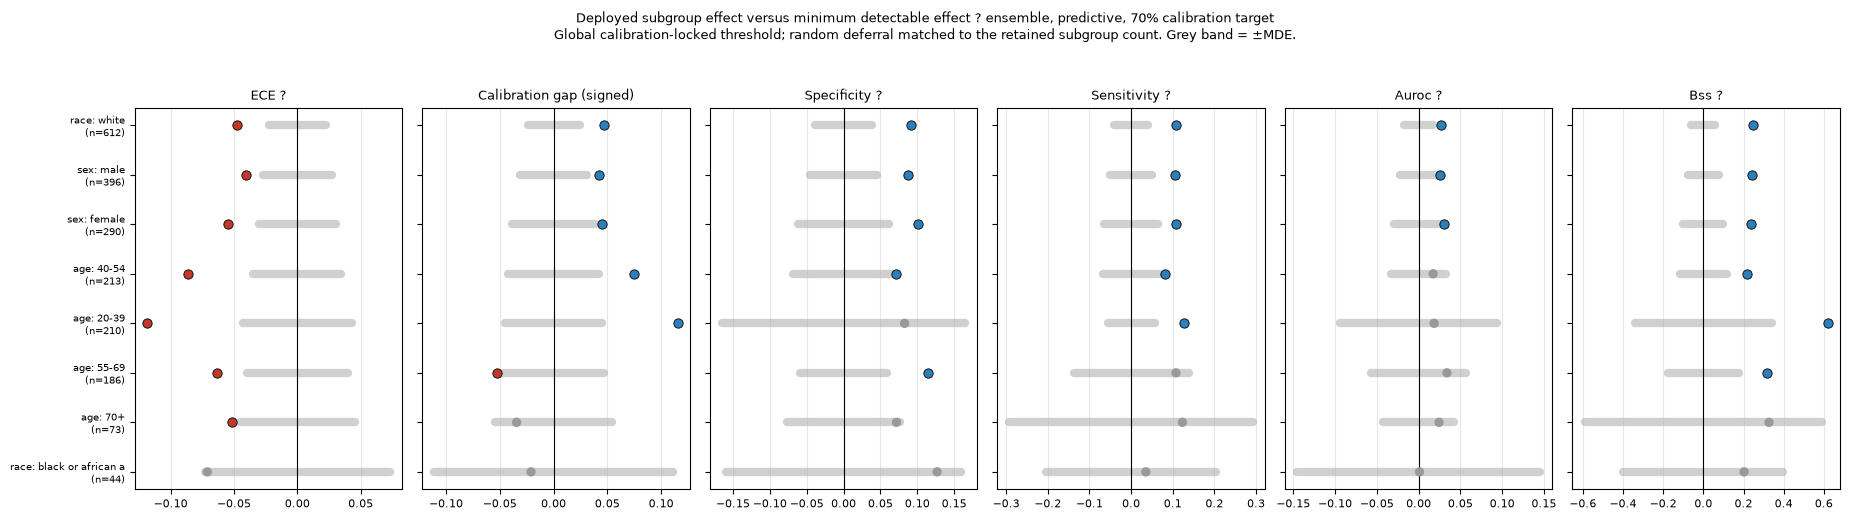

In [ ]:
PRED = "ensemble"
FAMILY = "predictive"
COV = 0.70

PLOT_METRICS = [
    "ece",
    "cal_gap",
    "specificity",
    "sensitivity",
    "auroc",
    "bss",
]

# Filter once using predictor, uncertainty family, and calibration target
plot_df = glob_df.query(
    "predictor == @PRED and family == @FAMILY and target_coverage == @COV"
).copy()

# Order subgroups by sample size so the power gradient is visible
sub_order = (
    plot_df
    .drop_duplicates(["axis", "level"])
    .assign(
        label=lambda d: (
            d["axis"].astype(str)
            + ": "
            + d["level"].astype(str).str.slice(0, 18)
        )
    )
    .sort_values("n")
)

labels = sub_order["label"].tolist()
ns = sub_order["n"].tolist()
ypos = np.arange(len(labels))

fig, axes = plt.subplots(
    1,
    len(PLOT_METRICS),
    figsize=(3.1 * len(PLOT_METRICS), 5),
    sharey=True,
)

for ax, metric in zip(axes, PLOT_METRICS):
    g = (
        plot_df.query("metric == @metric")
        .assign(
            label=lambda d: (
                d["axis"].astype(str)
                + ": "
                + d["level"].astype(str).str.slice(0, 18)
            )
        )
        .set_index("label")
    )

    for yi, lab in enumerate(labels):
        if lab not in g.index:
            continue

        r = g.loc[lab]

        # Defensive handling in case duplicate rows exist
        if isinstance(r, pd.DataFrame):
            r = r.iloc[0]

        d = r["d_random"]
        mde = r["mde"]

        if not np.isfinite(d):
            continue

        if np.isfinite(mde):
            ax.plot(
                [-mde, mde],
                [yi, yi],
                color="#d0d0d0",
                lw=6,
                solid_capstyle="round",
                zorder=1,
            )

        resolvable = (
            bool(r["sig"])
            if "sig" in r.index
            else np.isfinite(mde) and abs(d) > mde
        )

        ax.scatter(
            d,
            yi,
            s=45,
            zorder=3,
            color=(
                ("#c0392b" if d < 0 else "#2c7fb8")
                if resolvable
                else "#999999"
            ),
            edgecolor="k" if resolvable else "none",
            linewidth=0.6,
        )

    ax.axvline(0, color="k", lw=0.8, zorder=2)

    if metric == "ece":
        metric_title = "ECE ?"
    elif metric == "cal_gap":
        metric_title = "Calibration gap (signed)"
    else:
        metric_title = f"{metric.capitalize()} ?"

    ax.set_title(metric_title, fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=8)

axes[0].set_yticks(ypos)
axes[0].set_yticklabels(
    [f"{lab}\n(n={n})" for lab, n in zip(labels, ns)],
    fontsize=7.5,
)

fig.suptitle(
    f"Deployed subgroup effect versus minimum detectable effect ? "
    f"{PRED}, {FAMILY}, {COV:.0%} calibration target\n"
    f"Global calibration-locked threshold; random deferral matched to the "
    f"retained subgroup count. Grey band = ±MDE.",
    fontsize=9.5,
    y=1.03,
)

plt.tight_layout()

plt.savefig(
    OUT_DIR
    / (
        f"fair_abstention_q2_global_"
        f"{PRED}_{FAMILY}_{int(COV * 100)}.png"
    ),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## E5c. Computational cost per uncertainty family

E5/E5b compare families on statistical grounds (AURC) and clinical grounds (NND),
but neither says anything about what each family costs to run. A family that wins by
a small margin at 500x the inference compute of another is a different practical
recommendation than one that wins outright for free. This measures real wall-clock
inference cost for one representative locked predictor (UNI2 fold0), on real TCGA
slides, reusing the exact checkpoints scored elsewhere in this notebook: see
`scripts/training/inference_cost_benchmark.py`.

Framing, important: every family here is an add-on signal layered on the same
locked classifier : `prob_mutant` is identical across every family, so the one
deterministic forward pass that produces it is mandatory regardless of which family
is used for abstention. No family's total cost can therefore ever fall below that
base pass. The table reports both each family's own extra computation in isolation,
and its total cost (own extra + the mandatory base pass); `relative_to_single_pass`
is always computed from the total, so nothing shows up as "cheaper than the
prediction it depends on."

Times, per slide: (1) the single deterministic forward pass every family sits on
top of, (2) the density-based OOD flow's extra patch-level pass, (3) MC-dropout's
500 passes, (4) the 8-member deep ensemble (extended from 4 as a robustness check,
see A.7), and (5) last-layer Laplace's 200 posterior samples, which reuse the same
cached bag embedding from (1), so its own extra compute is tiny, but its total cost
still includes that mandatory base pass.

In [ ]:
INFERENCE_COST_CSV = OUT_DIR / "inference_cost_by_family.csv"

if not INFERENCE_COST_CSV.exists():
    raise FileNotFoundError(
        f"{INFERENCE_COST_CSV} missing -- run "
        "`PYTHONPATH=. python scripts/training/inference_cost_benchmark.py` first."
    )

cost_table = pd.read_csv(INFERENCE_COST_CSV)
pd.set_option("display.max_colwidth", 100)
display(cost_table)


,family,per_patient_op,passes_per_slide,own_extra_ms_per_slide,total_ms_per_slide,relative_to_single_pass,note
0,predictive / cross-fold-cross-encoder,1 deterministic forward pass,1,0.000000,0.358417,1.000000,the mandatory base pass every family sits on top of -- produces prob_mutant; the full ensemble p...
1,density-based OOD,base pass + 1 flow forward pass over all patches,2,1.110347,1.468764,4.097922,"separate patch-level pass, not bag-level, on top of the mandatory base pass; scales with n_patch..."
2,MC-dropout,base pass + 500 dropout-active forward passes through the full network,501,118.941750,119.300167,332.853166,most expensive family measured -- every one of its own passes redoes the full attention-MIL forw...
3,deep ensemble,"base pass + 8 independently-trained models, 1 full pass each",9,1.887052,2.245469,6.264966,cheaper than MC-dropout at inference despite needing 4x the training compute up front to produce...
4,last-layer Laplace,base pass (reused for its cached z) + 200 posterior samples through the linear head only,1,0.837456,1.195873,3.336543,"cheapest ADD-ON by far -- its own extra compute skips the attention-MIL forward entirely, reusin..."
5,evidential / NatPN (abandoned),base pass (reused for its cached z) + 1 small density-net forward on frozen z (not measured -- n...,1,NaN,NaN,NaN,"architecturally would have been the same order as Laplace (cheap add-on, reuses the same z); dro..."


## E5d. Patch-subsampling / bag-size sensitivity

Every result above scores each slide's full patch bag (typically thousands of
patches per WSI). In deployment, bags are sometimes smaller than that: QC filtering,
small biopsies, tissue folding that removes tiles. So it's worth checking whether
predictive-entropy-based selective prediction is a property of the task or an
artefact of averaging attention over a large bag. This subsamples each TCGA slide's
own bag at reduced patch-count fractions (10-75% of that slide's own patch count,
not a fixed absolute cap, since patch counts vary widely across slides), rescores
through the already-trained, already-locked ABMIL ensemble (3 encoders × 5 folds, no
retraining), and asks whether entropy-based AURC survives, both against the
random-deferral floor and against the full-bag baseline, with a paired bootstrap
(2000 draws, BH-FDR corrected within each encoder across the 4 reduced fractions).
Reuses cached `.h5` patch features directly no re-embedding, no GPU needed for
this stage (ABMIL forward passes are cheap matrix multiplies; only training needs a
GPU).

In [ ]:
BAG_SIZE_CSV = BASE / "outputs/bag_size_sensitivity_test/tcga_bag_size_results.csv"

if not BAG_SIZE_CSV.exists():
    raise FileNotFoundError(
        f"{BAG_SIZE_CSV} missing -- run "
        "scripts/training/bag_size_sensitivity_test.py first (CPU-only, no GPU needed)."
    )

bag_size_df = pd.read_csv(BAG_SIZE_CSV)
pd.set_option("display.width", 220)
display(bag_size_df[["encoder", "bag_fraction", "median_patch_count", "aurc", "error_rate",
                      "delta_vs_random", "q_vs_random", "sig_vs_random",
                      "delta_vs_full_aurc", "q_vs_full", "sig_vs_full_degradation"]]
        .sort_values(["encoder", "bag_fraction"], ascending=[True, False]))

print()
print("Per-encoder summary:")
for enc, g in bag_size_df.groupby("encoder"):
    full_row = g[g.bag_fraction == 1.0].iloc[0]
    reduced = g[g.bag_fraction != 1.0]
    n_beats_random = int(reduced["sig_vs_random"].sum())
    n_degraded = int(reduced["sig_vs_full_degradation"].sum())
    print(f"  {enc:10s} | full-bag AURC {full_row['aurc']:.4f} (beats random: "
          f"{'yes' if full_row['sig_vs_random'] else 'no'}) | "
          f"{n_beats_random}/{len(reduced)} reduced fractions still beat random deferral | "
          f"{n_degraded}/{len(reduced)} show significant degradation vs the full bag")


,encoder,bag_fraction,median_patch_count,aurc,error_rate,delta_vs_random,q_vs_random,sig_vs_random,delta_vs_full_aurc,q_vs_full,sig_vs_full_degradation
5,conch,1.00,2651,0.069587,0.158192,0.088764,0.0,True,0.000000,NaN,False
6,conch,0.75,1988,0.070249,0.156780,0.086717,0.0,True,0.000648,0.370000,False
7,conch,0.50,1326,0.070174,0.163842,0.093774,0.0,True,0.000585,0.505000,False
8,conch,0.25,663,0.070177,0.161017,0.091001,0.0,True,0.000579,0.505000,False
9,conch,0.10,265,0.071325,0.159605,0.088357,0.0,True,0.001714,0.370000,False
10,hoptimus,1.00,2651,0.055420,0.134181,0.078599,0.0,True,0.000000,NaN,False
11,hoptimus,0.75,1988,0.055761,0.134181,0.078216,0.0,True,0.000330,0.468000,False
12,hoptimus,0.50,1326,0.054216,0.127119,0.072816,0.0,True,-0.001204,0.161333,False
13,hoptimus,0.25,663,0.057086,0.135593,0.078333,0.0,True,0.001676,0.161333,False
14,hoptimus,0.10,265,0.058191,0.131356,0.073139,0.0,True,0.002737,0.161333,False



Per-encoder summary:
  conch      | full-bag AURC 0.0696 (beats random: yes) | 4/4 reduced fractions still beat random deferral | 0/4 show significant degradation vs the full bag
  hoptimus   | full-bag AURC 0.0554 (beats random: yes) | 4/4 reduced fractions still beat random deferral | 0/4 show significant degradation vs the full bag
  uni2       | full-bag AURC 0.0356 (beats random: yes) | 4/4 reduced fractions still beat random deferral | 0/4 show significant degradation vs the full bag


In [ ]:
BAG_SIZE_AUROC_CSV = BASE / "outputs/bag_size_sensitivity_test/tcga_bag_size_auroc_results.csv"

if not BAG_SIZE_AUROC_CSV.exists():
    raise FileNotFoundError(
        f"{BAG_SIZE_AUROC_CSV} missing -- run "
        "scripts/training/bag_size_auroc_check.py first (CPU-only, no GPU needed)."
    )

bag_size_auroc_df = pd.read_csv(BAG_SIZE_AUROC_CSV)
display(bag_size_auroc_df[["encoder", "bag_fraction", "n", "auroc", "delta_auroc_vs_full",
                            "ci_low", "ci_high", "p_raw", "q_fdr", "sig_degradation"]]
        .sort_values(["encoder", "bag_fraction"], ascending=[True, False]))

print()
print("Per-encoder summary (full 789-patient cohort, threshold-independent):")
for enc, g in bag_size_auroc_df.groupby("encoder"):
    full_auroc = g.loc[g.bag_fraction == 1.0, "auroc"].iloc[0]
    reduced = g[g.bag_fraction != 1.0]
    n_sig = int(reduced["sig_degradation"].sum())
    worst = reduced.loc[reduced["delta_auroc_vs_full"].idxmin()]
    print(f"  {enc:10s} | full-bag AUROC {full_auroc:.4f} | "
          f"{n_sig}/{len(reduced)} reduced fractions show BH-FDR-significant AUROC degradation | "
          f"largest drop: {worst['delta_auroc_vs_full']:+.4f} at bag_fraction={worst['bag_fraction']}")


,encoder,bag_fraction,n,auroc,delta_auroc_vs_full,ci_low,ci_high,p_raw,q_fdr,sig_degradation
5,conch,1.00,789,0.921601,0.000000,0.000000,0.000000,1.000,NaN,False
6,conch,0.75,789,0.921014,-0.000583,-0.001229,-0.000013,0.048,0.118000,False
7,conch,0.50,789,0.920724,-0.000887,-0.001864,0.000039,0.059,0.118000,False
8,conch,0.25,789,0.920421,-0.001189,-0.002936,0.000650,0.175,0.233333,False
9,conch,0.10,789,0.921046,-0.000596,-0.003214,0.001863,0.660,0.660000,False
10,hoptimus,1.00,789,0.930358,0.000000,0.000000,0.000000,1.000,NaN,False
11,hoptimus,0.75,789,0.930055,-0.000297,-0.001025,0.000361,0.400,0.533333,False
12,hoptimus,0.50,789,0.930035,-0.000308,-0.001289,0.000663,0.540,0.540000,False
13,hoptimus,0.25,789,0.928984,-0.001383,-0.003057,0.000135,0.077,0.154000,False
14,hoptimus,0.10,789,0.927598,-0.002735,-0.005239,-0.000274,0.025,0.100000,False



Per-encoder summary (full 789-patient cohort, threshold-independent):
  conch      | full-bag AUROC 0.9216 | 0/4 reduced fractions show BH-FDR-significant AUROC degradation | largest drop: -0.0012 at bag_fraction=0.25
  hoptimus   | full-bag AUROC 0.9304 | 0/4 reduced fractions show BH-FDR-significant AUROC degradation | largest drop: -0.0027 at bag_fraction=0.1
  uni2       | full-bag AUROC 0.9575 | 0/4 reduced fractions show BH-FDR-significant AUROC degradation | largest drop: -0.0004 at bag_fraction=0.1


## E5e. Does *combining* predictive uncertainty with OOD help?

Every family comparison above (E5, E5a) tests uncertainty families alone. Does combining predictive uncertainty with OOD, via AND/OR/mean-of-z
fusion, do better than predictive uncertainty alone, and does that depend on which
encoder's OOD is used? Scored on UNI2 (negative-control encoder, OOD known null on
this task) and H-optimus (positive-case encoder, OOD tracks real distributional
distance). Uses 20 independent stratified 70/30 fit/eval splits rather than one
split, an initial single-split check found a promising-looking gain that did not
replicate under this more robust repeated-holdout design, pooling 500
paired-bootstrap draws per split (10,000 total per strategy), BH-FDR corrected
across the 4 combine rules within each comparison type.

In [ ]:
from sklearn.model_selection import train_test_split as _combine_tts

COMBINE_TARGET_COV = 0.80
COMBINE_N_SPLITS = 20
COMBINE_N_BOOT_PER_SPLIT = 500
COMBINE_PREDICTORS = ["uni2", "hoptimus"]   # negative control + positive case

def _combine_zscore(x, ref):
    return (x - ref.mean()) / ref.std()

def _combine_run_predictor(cohort_df, pred, rng_seed=RNG_SEED):
    y_all = cohort_df["label"].to_numpy(int)
    p_all = cohort_df[f"prob_mutant_{pred}"].to_numpy(float)
    entropy_all = cohort_df[f"entropy_{pred}"].to_numpy(float)
    ood_all = cohort_df[f"ood_attention_{pred}"].to_numpy(float)
    n = len(y_all)

    strategies = ["ood_only", "AND", "OR", "MEANZ"]
    pooled_vs_entropy = {s: [] for s in strategies}
    pooled_vs_full = {s: [] for s in strategies}
    pooled_entropy_vs_full = []
    point_accum = {s: [] for s in strategies + ["entropy_only", "full"]}
    cov_accum = {s: [] for s in strategies + ["entropy_only"]}

    for split_i in range(COMBINE_N_SPLITS):
        seed = rng_seed + split_i
        fit_idx, eval_idx = _combine_tts(np.arange(n), test_size=0.3, stratify=y_all, random_state=seed)

        e_cut = np.quantile(entropy_all[fit_idx], COMBINE_TARGET_COV)
        o_cut = np.quantile(ood_all[fit_idx], COMBINE_TARGET_COV)
        keep_e = entropy_all <= e_cut
        keep_o = ood_all <= o_cut
        z_e = _combine_zscore(entropy_all, entropy_all[fit_idx])
        z_o = _combine_zscore(ood_all, ood_all[fit_idx])
        combo_z = (z_e + z_o) / 2
        z_cut = np.quantile(combo_z[fit_idx], COMBINE_TARGET_COV)
        keep_meanz = combo_z <= z_cut
        masks = {"entropy_only": keep_e, "ood_only": keep_o, "AND": keep_e & keep_o,
                  "OR": keep_e | keep_o, "MEANZ": keep_meanz}

        y_eval, p_eval = y_all[eval_idx], p_all[eval_idx]
        full_point = roc_auc_score(y_eval, p_eval)
        point_accum["full"].append(full_point)
        for name, m in masks.items():
            me = m[eval_idx]
            pt = (roc_auc_score(y_eval[me], p_eval[me])
                  if me.sum() >= 10 and len(np.unique(y_eval[me])) >= 2 else np.nan)
            point_accum[name].append(pt)
            cov_accum[name].append(me.mean())

        boot_rng = np.random.default_rng(seed + 100000)
        n_used, attempts = 0, 0
        while n_used < COMBINE_N_BOOT_PER_SPLIT and attempts < COMBINE_N_BOOT_PER_SPLIT * 30:
            attempts += 1
            bi = eval_idx[boot_rng.integers(0, len(eval_idx), len(eval_idx))]
            yb, pb = y_all[bi], p_all[bi]
            if len(np.unique(yb)) < 2:
                continue
            aurocs, ok = {}, True
            for name in masks:
                mb = masks[name][bi]
                if mb.sum() < 10 or len(np.unique(yb[mb])) < 2:
                    ok = False; break
                aurocs[name] = roc_auc_score(yb[mb], pb[mb])
            if not ok:
                continue
            full_b = roc_auc_score(yb, pb)
            n_used += 1
            pooled_entropy_vs_full.append(aurocs["entropy_only"] - full_b)
            for s in strategies:
                pooled_vs_entropy[s].append(aurocs[s] - aurocs["entropy_only"])
                pooled_vs_full[s].append(aurocs[s] - full_b)

    def _summarize(d):
        d = np.asarray(d)
        lo, hi = np.percentile(d, [2.5, 97.5])
        p_two = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        return float(np.mean(d)), lo, hi, p_two, len(d)

    rows = []
    m_e, lo, hi, p, nb_ = _summarize(pooled_entropy_vs_full)
    rows.append({"strategy": "entropy_only", "comparison": "vs_full", "mean_delta": m_e,
                 "ci_low": lo, "ci_high": hi, "p_raw": p, "n_boot": nb_})
    for s in strategies:
        for comp, pool in [("vs_entropy_only", pooled_vs_entropy), ("vs_full", pooled_vs_full)]:
            m, lo, hi, p, nb_ = _summarize(pool[s])
            rows.append({"strategy": s, "comparison": comp, "mean_delta": m,
                         "ci_low": lo, "ci_high": hi, "p_raw": p, "n_boot": nb_})

    out = pd.DataFrame(rows)
    out["mean_point_auroc"] = out["strategy"].map(lambda s: np.nanmean(point_accum[s]))
    out["mean_achieved_cov"] = out["strategy"].map(lambda s: np.nanmean(cov_accum.get(s, [np.nan])))
    return out

def _combine_bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

combine_master = pd.read_csv(MASTER_CSV)
combine_rows = []
for pred in COMBINE_PREDICTORS:
    if f"ood_attention_{pred}" not in combine_master.columns:
        print(f"skip {pred}: no OOD signal"); continue
    res = _combine_run_predictor(combine_master, pred)
    res["predictor"] = pred
    combine_rows.append(res)

combine_df = pd.concat(combine_rows, ignore_index=True)
combine_df["q_fdr"] = np.nan
_combine_rules = ["ood_only", "AND", "OR", "MEANZ"]
for (pred, comp), idx in combine_df.groupby(["predictor", "comparison"]).groups.items():
    sub = combine_df.loc[idx]
    sub = sub[sub.strategy.isin(_combine_rules)]
    if len(sub) == 0:
        continue
    combine_df.loc[sub.index, "q_fdr"] = _combine_bh_fdr(sub["p_raw"].to_numpy())
combine_df["sig_fdr"] = combine_df["q_fdr"] < 0.05

COMBINE_OUT_CSV = OUT_DIR / "combine_predictive_ood_robust_tcga.csv"
combine_df.to_csv(COMBINE_OUT_CSV, index=False)

pd.set_option("display.width", 260)
display(combine_df[["predictor", "strategy", "comparison", "mean_point_auroc", "mean_achieved_cov",
                     "mean_delta", "ci_low", "ci_high", "p_raw", "q_fdr", "sig_fdr"]]
        .sort_values(["predictor", "comparison", "strategy"]))

print()
print("Net verdict (does ANY combine rule beat entropy-alone, FDR-significant, on TCGA):")
vs_entropy = combine_df[(combine_df.comparison == "vs_entropy_only") & (combine_df.strategy.isin(_combine_rules))]
n_sig_positive = int(((vs_entropy.sig_fdr) & (vs_entropy.mean_delta > 0)).sum())
n_sig_negative = int(((vs_entropy.sig_fdr) & (vs_entropy.mean_delta < 0)).sum())
print(f"  {n_sig_positive} significant IMPROVEMENTS over entropy-alone, "
      f"{n_sig_negative} significant WORSENINGS, out of {len(vs_entropy)} (predictor x combine-rule) comparisons.")


,predictor,strategy,comparison,mean_point_auroc,mean_achieved_cov,mean_delta,ci_low,ci_high,p_raw,q_fdr,sig_fdr
12,hoptimus,AND,vs_entropy_only,0.959694,0.673840,0.003459,-0.009172,0.022050,0.7094,0.816400,False
16,hoptimus,MEANZ,vs_entropy_only,0.954971,0.799578,-0.001136,-0.011232,0.007452,0.8164,0.816400,False
14,hoptimus,OR,vs_entropy_only,0.945256,0.925949,-0.010817,-0.028142,0.000511,0.0624,0.249600,False
10,hoptimus,ood_only,vs_entropy_only,0.946587,0.797890,-0.009551,-0.033026,0.010532,0.3382,0.676400,False
13,hoptimus,AND,vs_full,0.959694,0.673840,0.025842,0.002241,0.059839,0.0348,0.046400,True
17,hoptimus,MEANZ,vs_full,0.954971,0.799578,0.021247,0.006501,0.041996,0.0036,0.009600,True
15,hoptimus,OR,vs_full,0.945256,0.925949,0.011566,0.002194,0.026473,0.0048,0.009600,True
9,hoptimus,entropy_only,vs_full,0.956133,0.801899,0.022383,0.005934,0.047795,0.0058,NaN,False
11,hoptimus,ood_only,vs_full,0.946587,0.797890,0.012832,-0.003809,0.035661,0.1506,0.150600,False
3,uni2,AND,vs_entropy_only,0.979193,0.643038,0.002981,-0.007119,0.019279,0.7660,0.766000,False



Net verdict (does ANY combine rule beat entropy-alone, FDR-significant, on TCGA):
  0 significant IMPROVEMENTS over entropy-alone, 1 significant WORSENINGS, out of 8 (predictor x combine-rule) comparisons.


## E6. Acquisition variables under abstention

The same two questions from E5 (realised coverage, retained performance vs.
random) asked again, but along acquisition axes (site, Thomas-Jefferson-vs-rest,
within-site magnification) rather than demographics, since a global uncertainty
cutoff has no way to "know" about scanner/site either, and site is where the
largest confounds were found in E4.

In [ ]:
# MIN_SITE_N already defined above (E4); reused, not redefined.
MIN_ACQ_GROUP_N = 5
TARGET_COVERAGES = [0.90, 0.80, 0.70]

rows = []


for predictor in PREDICTORS:

    print("\n" + "=" * 80)
    print(f"PREDICTOR: {predictor}")
    print("=" * 80)

    # One calibration-selected signal per uncertainty family
    selected = (
        RESULTS[predictor]["table"]
        .drop_duplicates("family")[["family", "signal"]]
        .reset_index(drop=True)
    )

    for _, sel in selected.iterrows():

        family = sel["family"]
        sig = sel["signal"]

        if sig not in acq.columns:
            print(f"  skipping {family}: signal '{sig}' not found in acq")
            continue

        # Each family is evaluated on its own available-case cohort
        keep_cols = [
            sig,
            "site",
            "magnification",
            "scanner_grp",
        ]

        F = common_cohort(acq, [sig], keep_cols).copy()
        F = F.reset_index(drop=True)

        if len(F) == 0:
            print(f"  skipping {family}: empty common cohort")
            continue

        uncertainty = F[sig].to_numpy(float)

        print(
            f"\n  {family:<12s} | {sig:<35s} | evaluation n={len(F)}"
        )

        for cov in TARGET_COVERAGES:

            cutoff = float(
                SELECTIVE[predictor]
                .query(
                    "family == @family "
                    "and signal == @sig "
                    "and target_coverage == @cov"
                )["calibration_cutoff"]
                .iloc[0]
            )

            keep_global = uncertainty <= cutoff
            global_coverage = float(keep_global.mean())

            print(
                f"    target={cov:.0%} | "
                f"realised global={global_coverage:.1%} | "
                f"cutoff={cutoff:.6g}"
            )

            # Site

            site_values = F["site"].astype(str)

            for group, idx in site_values.groupby(site_values).groups.items():

                idx = np.asarray(list(idx), dtype=int)
                n = len(idx)

                if n < MIN_SITE_N:
                    continue

                retained_n = int(keep_global[idx].sum())
                realised_coverage = retained_n / n

                rows.append({
                    "predictor": predictor,
                    "family": family,
                    "signal": sig,
                    "target_coverage": cov,
                    "calibration_cutoff": cutoff,
                    "global_n": len(F),
                    "global_realised_coverage": global_coverage,
                    "axis": "site",
                    "group": group,
                    "n": n,
                    "retained_n": retained_n,
                    "realised_coverage": realised_coverage,
                    "coverage_vs_target": realised_coverage - cov,
                    "coverage_vs_global": realised_coverage - global_coverage,
                })

            # Magnification
            valid_mag = F["magnification"].notna()

            mag_values = (
                F.loc[valid_mag, "magnification"]
                .astype(str)
            )

            for group, idx in mag_values.groupby(mag_values).groups.items():

                idx = np.asarray(list(idx), dtype=int)
                n = len(idx)

                if n < MIN_ACQ_GROUP_N:
                    continue

                retained_n = int(keep_global[idx].sum())
                realised_coverage = retained_n / n

                rows.append({
                    "predictor": predictor,
                    "family": family,
                    "signal": sig,
                    "target_coverage": cov,
                    "calibration_cutoff": cutoff,
                    "global_n": len(F),
                    "global_realised_coverage": global_coverage,
                    "axis": "magnification",
                    "group": group,
                    "n": n,
                    "retained_n": retained_n,
                    "realised_coverage": realised_coverage,
                    "coverage_vs_target": realised_coverage - cov,
                    "coverage_vs_global": realised_coverage - global_coverage,
                })

            # Scanner group
            valid_scanner = F["scanner_grp"].notna()

            scanner_values = (
                F.loc[valid_scanner, "scanner_grp"]
                .astype(str)
            )

            for group, idx in scanner_values.groupby(scanner_values).groups.items():

                idx = np.asarray(list(idx), dtype=int)
                n = len(idx)

                if n < MIN_ACQ_GROUP_N:
                    continue

                retained_n = int(keep_global[idx].sum())
                realised_coverage = retained_n / n

                rows.append({
                    "predictor": predictor,
                    "family": family,
                    "signal": sig,
                    "target_coverage": cov,
                    "calibration_cutoff": cutoff,
                    "global_n": len(F),
                    "global_realised_coverage": global_coverage,
                    "axis": "scanner_grp",
                    "group": group,
                    "n": n,
                    "retained_n": retained_n,
                    "realised_coverage": realised_coverage,
                    "coverage_vs_target": realised_coverage - cov,
                    "coverage_vs_global": realised_coverage - global_coverage,
                })


# Results

acquisition_q1 = pd.DataFrame(rows)

acquisition_q1 = acquisition_q1.sort_values(
    [
        "predictor",
        "family",
        "target_coverage",
        "axis",
        "group",
    ]
).reset_index(drop=True)

out_path = OUT_DIR / "acquisition_q1_coverage_by_family.csv"
acquisition_q1.to_csv(out_path, index=False)

print("\n" + "=" * 80)
print("ACQUISITION Q1 COMPLETE")
print("=" * 80)
print(f"Saved: {out_path}")
print(f"Rows: {len(acquisition_q1)}")


# Compact disparity summary
# Range = maximum minus minimum realised coverage across eligible groups

acquisition_q1_summary = (
    acquisition_q1
    .groupby(
        [
            "predictor",
            "family",
            "signal",
            "target_coverage",
            "axis",
        ],
        as_index=False,
    )
    .agg(
        n_groups=("group", "nunique"),
        min_group_coverage=("realised_coverage", "min"),
        max_group_coverage=("realised_coverage", "max"),
        mean_group_coverage=("realised_coverage", "mean"),
        global_realised_coverage=("global_realised_coverage", "first"),
    )
)

acquisition_q1_summary["coverage_range"] = (
    acquisition_q1_summary["max_group_coverage"]
    - acquisition_q1_summary["min_group_coverage"]
)

summary_path = OUT_DIR / "acquisition_q1_coverage_summary_by_family.csv"
acquisition_q1_summary.to_csv(summary_path, index=False)

print(f"Saved: {summary_path}")

display(
    acquisition_q1_summary.sort_values(
        "coverage_range",
        ascending=False,
    ).reset_index(drop=True)
)


PREDICTOR: uni2

  deep_ensemble | de_predictive_entropy_uni2          | evaluation n=687
    target=90% | realised global=82.5% | cutoff=0.549949
    target=80% | realised global=72.1% | cutoff=0.384944
    target=70% | realised global=60.7% | cutoff=0.258192

  epistemic    | within_encoder_mi_uni2              | evaluation n=687
    target=90% | realised global=81.7% | cutoff=0.0777614
    target=80% | realised global=64.5% | cutoff=0.040367
    target=70% | realised global=58.7% | cutoff=0.0315978

  laplace      | laplace_predictive_entropy_uni2     | evaluation n=687
    target=90% | realised global=85.0% | cutoff=0.597448
    target=80% | realised global=68.4% | cutoff=0.395868
    target=70% | realised global=57.8% | cutoff=0.29241

  mc_dropout   | mc_predictive_entropy_uni2          | evaluation n=687
    target=90% | realised global=82.2% | cutoff=0.557705
    target=80% | realised global=67.1% | cutoff=0.349028
    target=70% | realised global=55.9% | cutoff=0.250078

  oo

,predictor,family,signal,target_coverage,axis,n_groups,min_group_coverage,max_group_coverage,mean_group_coverage,global_realised_coverage,coverage_range
0,ensemble,ood,ood_attention_uni2,0.7,site,14,0.300000,0.964286,0.739778,0.740902,0.664286
1,uni2,ood,ood_attention_uni2,0.7,site,14,0.300000,0.964286,0.739778,0.740902,0.664286
2,uni2+hoptimus,ood,ood_attention_uni2,0.7,site,14,0.300000,0.964286,0.739778,0.740902,0.664286
3,hoptimus,ood,ood_attention_hoptimus,0.8,site,14,0.214286,0.864407,0.666750,0.711790,0.650121
4,hoptimus,ood,ood_attention_hoptimus,0.7,site,14,0.071429,0.711864,0.548081,0.595342,0.640436
...,...,...,...,...,...,...,...,...,...,...,...
256,hoptimus,ood,ood_attention_hoptimus,0.9,scanner_grp,4,0.871212,0.897260,0.886928,0.887918,0.026048
257,hoptimus,epistemic,within_encoder_mi_hoptimus,0.9,magnification,2,0.977273,0.993711,0.985492,0.981077,0.016438
258,uni2,ood,ood_attention_uni2,0.9,magnification,2,0.880682,0.893082,0.886882,0.883552,0.012400
259,uni2+hoptimus,ood,ood_attention_uni2,0.9,magnification,2,0.880682,0.893082,0.886882,0.883552,0.012400


Same retained-vs-random-deferral comparison as E5, now sliced by site,
Thomas-Jefferson-vs-rest, and within-site magnification instead of demographics.

In [ ]:
ACQ_COVERAGES = (0.9, 0.8, 0.7)


MIN_MAG_ARM_N = 5


acq_eval_df = acq.copy()


# Thomas Jefferson University versus all other sites
acq_eval_df["tju_vs_rest"] = np.where(
    acq_eval_df["site"].eq(TJU),
    "tju",
    "rest",
)


# Find GBM sites with at least MIN_MAG_ARM_N cases at both 20x and 40x
gbm_mag = acq_eval_df[
    acq_eval_df["tumour_type"].eq("glioblastoma")
    & acq_eval_df["magnification"].isin(["20x", "40x"])
].copy()

mixed_sites = []

for site, g in gbm_mag.groupby(
    "site",
    observed=True,
):
    n20 = int((g["magnification"] == "20x").sum())
    n40 = int((g["magnification"] == "40x").sum())

    if n20 >= MIN_MAG_ARM_N and n40 >= MIN_MAG_ARM_N:
        mixed_sites.append(site)


# This axis is defined only for GBM cases at eligible mixed sites
eligible_mag = (
    acq_eval_df["tumour_type"].eq("glioblastoma")
    & acq_eval_df["site"].isin(mixed_sites)
    & acq_eval_df["magnification"].isin(["20x", "40x"])
)

acq_eval_df["within_site_magnification"] = (
    acq_eval_df["site"].astype("string")
    + " | "
    + acq_eval_df["magnification"].astype("string")
).where(eligible_mag)


print(
    "Mixed-magnification GBM sites:",
    mixed_sites,
)


ACQ_AXES = {
    "site": {
        "col": "site",
        "min_n": MIN_SUBGROUP_N,
    },
    "TJU_vs_rest": {
        "col": "tju_vs_rest",
        "min_n": MIN_SUBGROUP_N,
    },
    "within_site_magnification": {
        "col": "within_site_magnification",
        "min_n": MIN_MAG_ARM_N,
    },
}



acq_glob_rows = []


for predictor, cfg in PREDICTOR_CONFIG.items():

    if predictor not in RESULTS or predictor not in SELECTIVE:
        continue

    # acq_eval_df contains the original model probability columns.
    probability_col = PREDICTORS[predictor][0]

    if probability_col not in acq_eval_df.columns:
        print(
            f"Skipping {predictor}: "
            f"probability column {probability_col!r} not found."
        )
        continue

    thr = cfg["operating_threshold"]

    selected = (
        RESULTS[predictor]["table"]
        .drop_duplicates("family")
        [["family", "signal"]]
    )

    for _, sel in selected.iterrows():

        family = sel["family"]
        sig = sel["signal"]

        if family == "reference":
            continue

        if sig not in acq_eval_df.columns:
            print(
                f"Skipping {predictor} / {family}: "
                f"signal {sig!r} not found."
            )
            continue

        for axis, spec in ACQ_AXES.items():

            axis_col = spec["col"]
            axis_min_n = spec["min_n"]

            keep_cols = [
                "label",
                probability_col,
                sig,
                axis_col,
            ]

            F = common_cohort(
                acq_eval_df,
                [sig],
                keep_cols,
            ).copy()

            if F.empty:
                continue

            F["p"] = F[probability_col].astype(float)
            F["y"] = F["label"].astype(int)

            y = F["y"].to_numpy(int)
            p = F["p"].to_numpy(float)
            s = F[sig].to_numpy(float)

            colvals = (
                F[axis_col]
                .astype(str)
                .str.lower()
                .to_numpy()
            )

            levels = pd.unique(colvals)

            for cov in ACQ_COVERAGES:

                cutoff = float(
                    SELECTIVE[predictor]
                    .query(
                        "family == @family "
                        "and signal == @sig "
                        "and target_coverage == @cov"
                    )["calibration_cutoff"]
                    .iloc[0]
                )

                keep_global = s <= cutoff

                for level in levels:

                    mask = colvals == level

                    if mask.sum() < axis_min_n:
                        continue

                    # Exact Fairness Q2 helper:
                    # globally matched random retention, then subgroup slicing.
                    res = subgroup_selective_global(
                        y,
                        p,
                        thr,
                        keep_global,
                        mask,
                        seed=(
                            RNG_SEED
                            + stable_seed(predictor,
                                        family,
                                        axis,
                                        level,
                                        cov,
                                        "acq_glob",)
                        ),
                    )

                    for k in SUITE:
                        acq_glob_rows.append({
                            "predictor": predictor,
                            "family": family,
                            "signal": sig,
                            "target_coverage": cov,
                            "axis": axis,
                            "level": level,
                            "n": int(mask.sum()),
                            "realised_coverage": res[
                                "realised_coverage"
                            ],
                            "retained_prev": res[
                                "retained_prev"
                            ],
                            "n_retained": res[
                                "n_retained"
                            ],
                            "metric": k,
                            **res[k],
                        })


acq_glob_df = pd.DataFrame(acq_glob_rows)

acq_glob_df["q_fdr"] = np.nan
for _metric, _idx in acq_glob_df.groupby("metric").groups.items():
    _sub = acq_glob_df.loc[_idx]
    _ok = _sub["p_raw"].notna()
    acq_glob_df.loc[_sub.index[_ok], "q_fdr"] = bh_fdr(
        _sub.loc[_ok, "p_raw"].to_numpy()
    )
acq_glob_df["sig_fdr"] = acq_glob_df["q_fdr"] < 0.05

acq_glob_df.to_csv(
    OUT_DIR / "acquisition_abstention_global_by_family.csv",
    index=False,
)


# Deployed retained performance versus random deferral.

print(
    "\n=== Acquisition Q2-global. "
    "Deployed retained performance vs random deferral ==="
)

print(
    "Results are shown separately for each uncertainty family."
)

print(
    "d_random compares uncertainty-based retention with "
    "matched global random retention."
)

print(
    "* = BH-FDR q<0.05 within metric, across every "
    "predictor x family x coverage x subgroup row."
)

print(
    "[cc] = prevalence-immune metric.\n"
)


for cov in ACQ_COVERAGES:

    print(
        f"=== calibration target coverage {cov:.0%} ==="
    )

    for family in acq_glob_df["family"].drop_duplicates():

        gf = acq_glob_df.query(
            "target_coverage == @cov "
            "and family == @family"
        )

        if gf.empty:
            continue

        print(
            f"\n--- family: {family} ---"
        )

        for (axis, level), g in gf.groupby(
            ["axis", "level"],
            observed=True,
        ):

            print(
                f"\n  [{axis}: {level}]  "
                f"n={int(g['n'].iloc[0])}"
            )

            for predictor in PREDICTOR_CONFIG:

                gp = g[
                    g["predictor"] == predictor
                ]

                if gp.empty:
                    continue

                rc = gp["realised_coverage"].iloc[0]
                rp = gp["retained_prev"].iloc[0]
                sig = gp["signal"].iloc[0]

                print(
                    f"    {predictor} | "
                    f"signal={sig} | "
                    f"realised_cov={rc:.2f} | "
                    f"retained_prev={rp:.2f}"
                )

                for k in LEAD:

                    gk = gp[
                        gp["metric"] == k
                    ]

                    if (
                        gk.empty
                        or not np.isfinite(
                            gk["retained"].iloc[0]
                        )
                    ):
                        continue

                    r = gk.iloc[0]

                    tag = (
                        "[cc]"
                        if k in (
                            "sensitivity",
                            "specificity",
                        )
                        else "    "
                    )

                    flag = (
                        "*"
                        if bool(r["sig_fdr"])
                        else " "
                    )

                    q_txt = (
                        f"{r['q_fdr']:.3f}"
                        if np.isfinite(r["q_fdr"])
                        else "-"
                    )

                    print(
                        f"      {k:<12s}{tag} "
                        f"d_random={r['d_random']:+.3f}{flag}  "
                        f"MDE={r['mde']:.3f}  q={q_txt}"
                    )

        print()

    print()

Mixed-magnification GBM sites: ['Duke', 'Henry Ford Hospital', 'MD Anderson Cancer Center']

=== Acquisition Q2-global. Deployed retained performance vs random deferral ===
Results are shown separately for each uncertainty family.
d_random compares uncertainty-based retention with matched global random retention.
* = BH-FDR q<0.05 within metric, across every predictor x family x coverage x subgroup row.
[cc] = prevalence-immune metric.

=== calibration target coverage 90% ===

--- family: deep_ensemble ---

  [TJU_vs_rest: rest]  n=668
    uni2 | signal=de_predictive_entropy_uni2 | realised_cov=0.83 | retained_prev=0.48
      auroc            d_random=+0.014*  MDE=0.010  q=0.016
      sensitivity [cc] d_random=+0.124*  MDE=0.027  q=0.009
      specificity [cc] d_random=+0.004   MDE=0.016  q=0.743
      ece              d_random=-0.021*  MDE=0.012  q=0.005
      cal_gap          d_random=+0.014*  MDE=0.014  q=0.014
      bss              d_random=+0.111*  MDE=0.036  q=0.006
    conch | 

Standalone check, motivated later by papers discussed elsewhere. The subgroup
tested is patients whose legacy `Histology`/`Grade` fields read glioblastoma, grade
4, but whose IDH status is mutant — i.e. a tumour a pathologist's report would have
called glioblastoma on morphological grounds, which the WHO's 2021 IDH-first
reclassification rule (glioblastoma is now IDH-wildtype-only, by definition)
relabels as astrocytoma, IDH-mutant, grade 4.

In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy.stats import fisher_exact

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
OUT_DIR = BASE / "outputs/selective_prediction_bench"

CALIBRATION_SITES = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",
    "Mayo Clinic - Rochester",
}


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


master = pd.read_csv(OUT_DIR / "master_patient_table.csv")
cal_mask = master["tissue_source_site.name"].isin(CALIBRATION_SITES)
eval_df = master.loc[~cal_mask].reset_index(drop=True)
assert len(eval_df) == 687, f"expected eval_df n=687, got {len(eval_df)}"

cutoffs = pd.read_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv")
sig_lookup = (cutoffs[cutoffs.predictor == "ensemble"]
              .drop_duplicates(["family", "target_coverage"])
              .set_index(["family", "target_coverage"])[["signal", "calibration_cutoff"]])

baseline = pd.read_csv(OUT_DIR / "baseline_overall_metrics.csv")
thr = float(baseline.loc[baseline.predictor == "ensemble", "threshold"].iloc[0])

y = eval_df["label"].to_numpy(int)
p = eval_df["prob_mutant"].to_numpy(float)
pred_cls = (p >= thr).astype(int)
is_err = (pred_cls != y).astype(bool)
is_mut = y == 1
n_full_mut = int(is_mut.sum())

# WHO2016-style "glioblastoma" histology + grade-4, in a patient who is
# IDH-mutant - relabelled astrocytoma, IDH-mutant, grade 4 under WHO2021.
gbm_hist = (eval_df["Histology"] == "glioblastoma") & (eval_df["Grade"] == "G4")
n_full_gbm_mut = int(gbm_hist[is_mut].sum())

rows = []
for fam in sig_lookup.index.get_level_values("family").unique():
    if fam == "reference":
        continue
    for cov in (0.9, 0.8, 0.7):
        key = (fam, cov)
        if key not in sig_lookup.index:
            continue
        sig, cutoff = sig_lookup.loc[key]
        if sig not in eval_df.columns:
            continue
        s = eval_df[sig].to_numpy(float)
        keep = s <= float(cutoff)

        mut_ret_mask = keep & is_mut
        n_mut_ret = int(mut_ret_mask.sum())
        if n_mut_ret < 5:
            continue
        conf_wrong_mut = mut_ret_mask & is_err & (np.abs(p - 0.5) > 0.3)
        n_cw = int(conf_wrong_mut.sum())
        n_not_cw = n_mut_ret - n_cw
        if n_cw == 0 or n_not_cw == 0:
            continue

        # 1. Composition: is confidently-wrong retention concentrated in
        # the GBM-histology/grade-4 subgroup?
        gbm_cw = gbm_hist[conf_wrong_mut]
        gbm_not_cw = gbm_hist[mut_ret_mask & ~conf_wrong_mut]
        table = [[int(gbm_cw.sum()), n_cw - int(gbm_cw.sum())],
                 [int(gbm_not_cw.sum()), n_not_cw - int(gbm_not_cw.sum())]]
        odds, p_fisher = fisher_exact(table)

        # 2. Concentration: what share of the retained vs. full mutant
        # pool do the GBM-histology-AND-confidently-wrong outliers make
        # up? Also expressed relative to the GBM/grade-4 subgroup itself.
        gbm_outliers_mask = conf_wrong_mut & gbm_hist
        n_gbm_outliers = int(gbm_outliers_mask.sum())
        pct_of_retained_mutant_pool = 100 * n_gbm_outliers / n_mut_ret
        pct_of_full_mutant_pool = 100 * n_gbm_outliers / n_full_mut
        concentration_factor = (
            (n_gbm_outliers / n_mut_ret) / (n_gbm_outliers / n_full_mut)
            if n_gbm_outliers else np.nan
        )
        n_retained_gbm_mut = int((mut_ret_mask & gbm_hist).sum())
        pct_of_retained_gbm_subgroup = (
            100 * n_gbm_outliers / n_retained_gbm_mut if n_retained_gbm_mut else np.nan
        )
        pct_of_full_gbm_subgroup = (
            100 * n_gbm_outliers / n_full_gbm_mut if n_full_gbm_mut else np.nan
        )

        # 3. Signal bimodality: within the GBM-histology/grade-4 subgroup,
        # is the deferral signal mostly appropriately elevated (deferred),
        # with only a minority anomalously low (confidently wrong)?
        gbm_mut_mask = is_mut & gbm_hist
        deferred_gbm = gbm_mut_mask & ~keep
        retained_not_cw_gbm = gbm_mut_mask & keep & ~conf_wrong_mut
        retained_cw_gbm = gbm_mut_mask & keep & conf_wrong_mut

        rows.append({
            "family": fam, "target_coverage": cov,
            "n_mutant_retained": n_mut_ret,
            "n_confidently_wrong": n_cw, "n_not_confidently_wrong": n_not_cw,
            "gbm_hist_rate_confidently_wrong": float(gbm_cw.mean()),
            "gbm_hist_rate_not_confidently_wrong": float(gbm_not_cw.mean()),
            "gbm_hist_rate_baseline_mutant_pop": float(gbm_hist[is_mut].mean()),
            "fisher_odds_ratio": odds, "fisher_p": p_fisher,
            "n_gbm_outliers": n_gbm_outliers,
            "pct_outliers_of_retained_mutant_pool": pct_of_retained_mutant_pool,
            "pct_outliers_of_full_mutant_pool": pct_of_full_mutant_pool,
            "concentration_factor": concentration_factor,
            "pct_outliers_of_retained_gbm_subgroup": pct_of_retained_gbm_subgroup,
            "pct_outliers_of_full_gbm_subgroup": pct_of_full_gbm_subgroup,
            "n_gbm_deferred": int(deferred_gbm.sum()),
            "n_gbm_retained_not_cw": int(retained_not_cw_gbm.sum()),
            "n_gbm_retained_cw": int(retained_cw_gbm.sum()),
            "mean_signal_gbm_deferred": float(s[deferred_gbm].mean()) if deferred_gbm.sum() else np.nan,
            "mean_signal_gbm_retained_not_cw": float(s[retained_not_cw_gbm].mean()) if retained_not_cw_gbm.sum() else np.nan,
            "mean_signal_gbm_retained_cw": float(s[retained_cw_gbm].mean()) if retained_cw_gbm.sum() else np.nan,
        })

tcga_who_reclass_check = pd.DataFrame(rows)
tcga_who_reclass_check["q_fdr"] = bh_fdr(tcga_who_reclass_check["fisher_p"].to_numpy())
tcga_who_reclass_check["sig_fdr"] = tcga_who_reclass_check["q_fdr"] < 0.05
tcga_who_reclass_check.to_csv(OUT_DIR / "tcga_who_reclassification_confidently_wrong.csv", index=False)

print("TCGA: confidently-wrong retention, WHO-reclassified GBM-histology/grade-4")
print("subgroup -- compositional enrichment, pool concentration, and signal bimodality.")
pd.set_option('display.max_columns', None)
display(tcga_who_reclass_check.round(3))

TCGA: confidently-wrong retention, WHO-reclassified GBM-histology/grade-4
subgroup -- compositional enrichment, pool concentration, and signal bimodality.


,family,target_coverage,n_mutant_retained,n_confidently_wrong,n_not_confidently_wrong,gbm_hist_rate_confidently_wrong,gbm_hist_rate_not_confidently_wrong,gbm_hist_rate_baseline_mutant_pop,fisher_odds_ratio,fisher_p,n_gbm_outliers,pct_outliers_of_retained_mutant_pool,pct_outliers_of_full_mutant_pool,concentration_factor,pct_outliers_of_retained_gbm_subgroup,pct_outliers_of_full_gbm_subgroup,n_gbm_deferred,n_gbm_retained_not_cw,n_gbm_retained_cw,mean_signal_gbm_deferred,mean_signal_gbm_retained_not_cw,mean_signal_gbm_retained_cw,q_fdr,sig_fdr
0,deep_ensemble,0.9,269,13,256,0.462,0.012,0.054,72.286,0.0,6,2.230,1.705,1.309,66.667,31.579,10,3,6,0.654,0.498,0.240,0.0,True
1,deep_ensemble,0.8,229,13,216,0.462,0.005,0.054,184.286,0.0,6,2.620,1.705,1.537,85.714,31.579,12,1,6,0.642,0.331,0.240,0.0,True
2,deep_ensemble,0.7,189,8,181,0.500,0.006,0.054,180.000,0.0,4,2.116,1.136,1.862,80.000,21.053,14,1,4,0.615,0.331,0.132,0.0,True
3,epistemic,0.9,331,13,318,0.462,0.041,0.054,20.110,0.0,6,1.813,1.705,1.063,31.579,31.579,0,13,6,NaN,0.039,0.021,0.0,True
4,epistemic,0.8,259,11,248,0.545,0.044,0.054,25.855,0.0,6,2.317,1.705,1.359,35.294,31.579,2,11,6,0.058,0.036,0.021,0.0,True
5,epistemic,0.7,211,10,201,0.500,0.025,0.054,39.200,0.0,5,2.370,1.420,1.668,50.000,26.316,9,5,5,0.049,0.025,0.015,0.0,True
6,laplace,0.9,280,13,267,0.462,0.022,0.054,37.286,0.0,6,2.143,1.705,1.257,50.000,31.579,7,6,6,0.671,0.582,0.263,0.0,True
7,laplace,0.8,244,13,231,0.462,0.004,0.054,197.143,0.0,6,2.459,1.705,1.443,85.714,31.579,12,1,6,0.652,0.368,0.263,0.0,True
8,laplace,0.7,197,10,187,0.500,0.005,0.054,186.000,0.0,5,2.538,1.420,1.787,83.333,26.316,13,1,5,0.639,0.368,0.217,0.0,True
9,mc_dropout,0.9,278,13,265,0.462,0.015,0.054,55.929,0.0,6,2.158,1.705,1.266,60.000,31.579,9,4,6,0.661,0.535,0.254,0.0,True


## Saved artifacts

Every table computed above was also written to `outputs/selective_prediction_bench/`
as CSV (and the ROC/forest/site figures as PNGs alongside), so downstream write-ups
don't need to re-run this notebook to pull a number.

In [43]:
sorted(p.name for p in OUT_DIR.glob("*.csv"))

['ablation_auroc_gain.csv',
 'ablation_metric_panel.csv',
 'ablation_metric_panel_display.csv',
 'ablation_summary.csv',
 'achieved_vs_target_coverage_by_family.csv',
 'acquisition_abstention_global_by_family.csv',
 'acquisition_q1_coverage_by_family.csv',
 'acquisition_q1_coverage_summary_by_family.csv',
 'acquisition_q2_global_by_family.csv',
 'acquisition_q2_performance_by_family.csv',
 'acquisition_q2_performance_summary_by_family.csv',
 'augrc_robustness_check.csv',
 'b3_subgroup_descriptives.csv',
 'b3_subgroup_discrimination.csv',
 'b3_subgroup_gaps.csv',
 'b3_subgroup_power_audit.csv',
 'baseline_auroc_gaps.csv',
 'baseline_disparity.csv',
 'baseline_one_vs_rest.csv',
 'baseline_overall_metrics.csv',
 'baseline_paired_contrasts.csv',
 'baseline_performance_by_subgroup.csv',
 'baseline_pergroup.csv',
 'biggest_improvement_by_metric.csv',
 'c1_site_performance.csv',
 'c1a_site_descriptives.csv',
 'c1b_site_outlier_screen.csv',
 'c1b_site_vs_rest_full_suite.csv',
 'c2_acquisition_